# Full-Screen Reanalysis: CRISPRi Perturbations and *SNCA* Expression in H1 hESCs

**Version 5 (revision notebook).** This replaces `TWF2_Complete_Analysis_Final.ipynb`.
It re-runs the screen across **every perturbation available in the Virtual Cell Challenge
(VCC) dataset** rather than a random subset of 51, and rebuilds the statistics so the
analysis matches what the manuscript is allowed to claim.

## What changed, by reviewer comment

| # | Reviewer comment | What this notebook does |
|---|---|---|
| 1 | Pseudoreplication; report batches/guides/replicates; seeds; repeated subsamples; KD efficiency; QC | §4 inventories every `obs` field (batch/guide/well) and says plainly what replicate structure exists. §6 builds **pseudobulk replicates** and §10 runs a replicate-level test as a parallel primary analysis. §11 repeats the cell-level test across 5 seeded control subsamples and reports SD and rank stability. §12 reports knockdown efficiency for every target. All seeds are fixed in §1. |
| 2 | Only 51/300 perturbations; selection procedure unclear | §3 loads **all** perturbations available and §9 screens every one. The exact number analysed is printed and written to `manuscript_numbers.json`. No sampling step exists anywhere in this notebook. |
| 3 | "Specificity" / "off-target" not supported; DEG count depends on power | §11.2 sensitivity grid over FDR and absolute log2 fold-change; §11.3 regresses DEG count on cell number and repeats the comparison at **matched cell counts**; §9.3 gives an empirical control-vs-control floor. Column names throughout are `n_deg` ("genes meeting DE criteria"), never "off-targets". |
| 4 | Numerical inconsistencies between text, Table 1, Figures | §18 writes **one** `manuscript_numbers.json` and prints paste-ready sentences. Every figure and table in §17 reads from that object, so they cannot disagree. |
| 5 | Interpretation exceeds hESC transcript-level data | Language in all outputs is association-level. §16 reports correlation of full effect vectors, not just set overlap. |
| 6 | pLI overstated; add complementary constraint metrics | §15 pulls pLI **and** LOEUF (`oe_lof_upper`), o/e with CI, and missense Z. Figure 5 is labelled "constraint", not "essentiality"; the pie chart is gone. |
| 7 | Mechanism claims unsupported | No mechanistic inference is computed or asserted here. §16 gives overlap statistics with a hypergeometric p-value so the overlap claim is testable rather than rhetorical. |
| 8 | Figures need thresholds, sample sizes, named comparator, no "optimal" | §17 draws the prespecified thresholds from §1, names the comparator perturbation in Fig 3C, and writes n / thresholds / test into every caption stub. |
| 9 | References | Not a notebook task. |
| 10 | Abstract/Conclusion overclaim | §18 emits the numbers only; wording is left to the manuscript. |
| 11 | Terminology | Fixed vocabulary defined in §1 and used in every output file. |

## Before you run

**§0 is the only cell you need to edit.** Put your Google Cloud project id there; it
mounts Drive, authenticates, verifies billing, confirms all three data files are
reachable, and prints the true target count — then stops if anything is wrong. After
that, Run All is safe.

**One-time restart.** On a fresh Colab runtime, §2 upgrades pandas (Colab ships a
version too old for current anndata) and then stops with a RESTART NEEDED message.
Do Runtime → Restart session and Run All again. It costs about a minute, and any data
already downloaded stays on `/content/vcc`, so nothing is fetched twice.

`GCS_SPLITS` defaults to all three splits, so this screens the full 300-target dataset.
Set it to `["train"]` for a faster 150-target rehearsal.

**Runtime on Colab Pro+ / A100 High-RAM:** roughly 2–3 h for all three splits, dominated
by the ~40 GB download. Results are copied to Drive after the screen and again at the
end, so a runtime that recycles overnight does not cost you the run.

## 0. Connect — Google Drive and Google Cloud

Run this first. It mounts Drive, authenticates to Google Cloud, checks that billing is
actually attached, and confirms every data file is reachable **before** anything long
starts. If something is wrong it stops here with a clear message rather than 40 minutes
into a download.

Edit `PROJECT` if you use a different Google Cloud project. Everything else is automatic.

In [1]:
# ============================================================
# 0. CONNECT  —  edit PROJECT, then run. Nothing else to change.
# ============================================================
PROJECT   = "project-425f6c8a-0dc9-4663-84b"      # Google Cloud project id
DRIVE_DIR = "/content/drive/MyDrive/TWF2_SNCA_Revision"
BUCKET    = "gs://arc-institute-virtual-cell-atlas/virtual-cell-challenge/2025"
WANT      = {"train": "adata_Training.h5ad",
             "validation": "adata_Validation.h5ad",
             "test": "adata_Test.h5ad"}

import os, subprocess, shlex, json as _json, datetime, shutil as _shutil
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
PREFLIGHT = {}


def _run(cmd, quiet=False):
    r = subprocess.run(shlex.split(cmd), capture_output=True, text=True)
    if not quiet:
        if r.stdout.strip():
            print(r.stdout.rstrip()[-2000:])
        if r.returncode != 0 and r.stderr.strip():
            print("STDERR:", r.stderr.rstrip()[-2000:])
    return r


print("=" * 78)
print("STEP 1 / 5  Google Drive")
print("=" * 78)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(DRIVE_DIR, exist_ok=True)
    print(f"Drive mounted. Outputs will be copied to {DRIVE_DIR}")
    PREFLIGHT["drive"] = True
except Exception as e:
    print(f"Drive not mounted ({e}). Results stay on the runtime and are lost when "
          f"it recycles - download them manually at the end.")
    PREFLIGHT["drive"] = False

print()
print("=" * 78)
print("STEP 2 / 5  Google Cloud authentication")
print("=" * 78)
from google.colab import auth
auth.authenticate_user()
_run(f"gcloud config set project {PROJECT} -q", quiet=True)
acct = _run("gcloud config get-value account", quiet=True).stdout.strip()
print(f"Authenticated as : {acct}")
print(f"Active project   : {PROJECT}")
print("If that account is not the one that owns the project, switch the Google "
      "account\nin the top-right of Colab and re-run this cell.")
PREFLIGHT["account"] = acct

print()
print("=" * 78)
print("STEP 3 / 5  Billing")
print("=" * 78)
bill = _run(f"gcloud billing projects describe {PROJECT}", quiet=True)
print(bill.stdout.rstrip() or bill.stderr.rstrip())
billing_on = "billingEnabled: true" in bill.stdout
PREFLIGHT["billing_enabled"] = billing_on
if not billing_on:
    print("\nBILLING IS NOT ATTACHED to this project. The bucket is Requester Pays,")
    print("so downloads will fail. Fix at:")
    print(f"  https://console.cloud.google.com/billing/linkedaccount?project={PROJECT}")
assert billing_on, "Attach a billing account to the project, then re-run this cell."

print()
print("=" * 78)
print("STEP 4 / 5  Data files")
print("=" * 78)
ls = _run(f"gcloud storage ls -l --recursive --billing-project={PROJECT} {BUCKET}/",
          quiet=True)
if ls.returncode != 0:
    print("STDERR:", ls.stderr.rstrip()[-2000:])
assert ls.returncode == 0, "Cannot list the bucket - see the error above."
listing = ls.stdout
for split, fn in WANT.items():
    found = fn in listing
    print(f"  {split:11s} {fn:26s} {'found' if found else 'NOT FOUND'}")
    PREFLIGHT[f"file_{split}"] = found
assert all(PREFLIGHT[f"file_{s}"] for s in WANT), \
    "A split's expression file is missing from the bucket - check the paths."

# The per-split target lists are tiny and give the true denominator up front.
# Do not guess the filename - "train" maps to pert_counts_Training.csv, not
# pert_counts_Train.csv. List the folder and take whatever CSV is there.
import pandas as _pd
TOTALS = {}
for split in WANT:
    folder = _run(f"gcloud storage ls --billing-project={PROJECT} "
                  f"{BUCKET}/{split}/", quiet=True).stdout
    csvs = [ln.strip() for ln in folder.splitlines() if ln.strip().endswith(".csv")]
    if not csvs:
        print(f"  {split:11s} no target-list CSV found in the folder")
        continue
    dest = f"results/00_pert_counts_{split}.csv"
    _run(f"gcloud storage cp --billing-project={PROJECT} {csvs[0]} {dest}", quiet=True)
    if os.path.exists(dest):
        TOTALS[split] = len(_pd.read_csv(dest))
        print(f"  {split:11s} {os.path.basename(csvs[0]):28s} "
              f"{TOTALS[split]:>4d} targets")
if TOTALS:
    print(f"  {'TOTAL':11s} {'':28s} {sum(TOTALS.values()):>4d} targets")
    print("\nThis is the denominator the manuscript should quote. §4 counts the")
    print("targets actually present in the loaded matrices and should agree.")
PREFLIGHT["targets_per_split"] = TOTALS
PREFLIGHT["targets_total"] = sum(TOTALS.values()) if TOTALS else None

print()
print("=" * 78)
print("STEP 5 / 5  Disk and output helper")
print("=" * 78)
du = _shutil.disk_usage("/content")
print(f"Free disk: {du.free/1e9:.0f} GB (the three files need about 40 GB)")
assert du.free > 45e9, "Not enough free disk for all three splits."


def save_to_drive(tag="checkpoint"):
    """Copy results/ and figures/ to a timestamped Drive folder. Safe to call often."""
    if not PREFLIGHT.get("drive"):
        print("(Drive not mounted; skipping save)")
        return None
    stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    dest = os.path.join(DRIVE_DIR, f"run_{RUN_ID}", tag)
    os.makedirs(dest, exist_ok=True)
    n = 0
    for d in ["results", "figures"]:
        if os.path.isdir(d):
            _shutil.copytree(d, os.path.join(dest, d), dirs_exist_ok=True)
            n += len(os.listdir(d))
    print(f"[drive] {n} files -> {dest}  ({stamp})")
    return dest


print("\nIf section 2 prints RESTART NEEDED, do Runtime > Restart session and")
print("Run All again. Downloaded files are kept; nothing is fetched twice.")

RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M")
_json.dump(PREFLIGHT, open("results/00_preflight.json", "w"), indent=2, default=str)
print(f"\nRun id: {RUN_ID}")
print("=" * 78)
print("PREFLIGHT PASSED - safe to Run All from here.")
print("=" * 78)

STEP 1 / 5  Google Drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Outputs will be copied to /content/drive/MyDrive/TWF2_SNCA_Revision

STEP 2 / 5  Google Cloud authentication
Authenticated as : <redacted>
Active project   : project-425f6c8a-0dc9-4663-84b
If that account is not the one that owns the project, switch the Google account
in the top-right of Colab and re-run this cell.

STEP 3 / 5  Billing
billingAccountName: billingAccounts/017AB9-B613B1-07CC4E
billingEnabled: true
name: projects/project-425f6c8a-0dc9-4663-84b/billingInfo
projectId: project-425f6c8a-0dc9-4663-84b

STEP 4 / 5  Data files
  train       adata_Training.h5ad        found
  validation  adata_Validation.h5ad      found
  test        adata_Test.h5ad            found
  train       pert_counts_Training.csv      150 targets
  validation  pert_counts_Validation.csv     50 targets
  test        pert_counts_Test.csv    

## 1. Prespecified configuration

Everything that could be tuned after seeing results is fixed here, before any data is
loaded, and echoed into the results directory. If you change a value, re-run from the top.

In [2]:
CFG = {
    # ---- reproducibility -------------------------------------------------
    "SEED": 42,
    "N_CTRL_SUBSAMPLES": 5,           # repeats for the stability analysis (§11.1)
    "SUBSAMPLE_SEEDS": [11, 22, 33, 44, 55],

    # ---- DE thresholds (Replogle et al. 2022) ----------------------------
    "FDR_ALPHA": 0.10,
    "LFC_MIN": 0.40,

    # ---- prespecified screen criteria (§13) ------------------------------
    # These define a "hit". They are declared here so the screen is not
    # tuned to the answer. Justify MAX_DEG in the manuscript as a
    # prespecified operational cutoff, not a measure of specificity.
    "SCREEN_MAX_DEG": 20,             # perturbations with <= this many DE genes
    "SCREEN_MIN_SNCA_REDUCTION": 50.0,  # percent reduction in SNCA

    # ---- filtering -------------------------------------------------------
    "GENE_MIN_PCT_CTRL": 0.05,        # keep genes detected in >5% of control cells
    "MIN_CELLS_PER_PERT": 25,         # perturbations with fewer cells are reported but flagged

    # ---- pseudobulk (§6, §10) -------------------------------------------
    "PSEUDOREP_K_PERT": 3,            # pseudo-replicates per perturbation if no batch/guide field
    "PSEUDOREP_K_CTRL": 8,            # pseudo-replicates for controls
    "PSEUDOBULK_MIN_CELLS_PER_REP": 8,

    # ---- pseudobulk design ----------------------------------------------
    "PAIRED_PSEUDOBULK": True,        # block on batch when batch labels exist
    "MIN_CELLS_PER_BATCH_EST": 20,    # per-batch effect estimates (§13.5)

    # ---- v1 numbers, for the replication check (§13.5) -------------------
    "V1_REPORTED": {
        "n_perturbations": 51,
        "snca_reduction_by_TWF2_pct": 91.1,
        "TWF2_n_deg": 8,
        "SNCA_n_deg": 39,
        "snca_self_reduction_pct": 94.2,
        "specificity_ratio": 4.9,
    },

    # ---- sensitivity grid (§11.3) ---------------------------------------
    "SENS_FDR": [0.01, 0.05, 0.10],
    "SENS_LFC": [0.25, 0.40, 0.50, 1.00],

    # ---- compute ---------------------------------------------------------
    "GENE_CHUNK": 1024,               # genes per GPU chunk
    "USE_GPU": True,

    # ---- data source -----------------------------------------------------
    # "auto"       -> gcs_full if GCS_PROJECT is set, otherwise public_zip
    # "gcs_full"   -> Arc Virtual Cell Atlas, train + validation + test (300 targets)
    # "public_zip" -> free 6.7 GB competition training archive (150 targets)
    "DATA_SOURCE": "auto",
    # taken from section 0 so there is only one place to edit it
    "GCS_PROJECT": globals().get("PROJECT", ""),
    "GCS_SPLITS": ["train", "validation", "test"],   # all 300 targets
    "GCS_BASE": ("gs://arc-institute-virtual-cell-atlas/"
                 "virtual-cell-challenge/2025"),
    "GCS_FILES": {                    # confirmed by listing the bucket
        "train":      "adata_Training.h5ad",     # ~15 GB, 150 targets
        "validation": "adata_Validation.h5ad",   # 50 targets
        "test":       "adata_Test.h5ad",         # ~12 GB, 100 targets
    },
    "LOCAL_DATA_DIR": "/content/vcc", # files are kept so re-runs skip the download
    "DOWNCAST_FLOAT32": True,         # halves memory if counts are stored as float64

    # ---- control matching ------------------------------------------------
    # "batch"  compares each perturbation with non-targeting cells processed in the
    #          same Flex batches, so batch is not confounded with perturbation.
    #          Falls back per perturbation if too few matched controls exist.
    # "split"  matches on data split only. "all" uses every control cell.
    "CONTROL_MATCHING": "batch",
    "MIN_MATCHED_CONTROLS": 200,      # below this, fall back to all controls

    # ---- genes of interest ----------------------------------------------
    "GENE_OF_INTEREST": "SNCA",
    "CANDIDATE": "TWF2",
}

# Fixed vocabulary used in every output file (reviewer comment 11).
GLOSSARY = {
    "n_deg": "number of genes meeting the prespecified DE criteria "
             "(BH-adjusted p < FDR_ALPHA and |log2FC| > LFC_MIN)",
    "self_lfc": "log2 fold-change of the CRISPRi target gene itself (knockdown efficiency)",
    "goi_lfc": "log2 fold-change of the gene of interest (SNCA)",
    "goi_reduction_pct": "(1 - 2**goi_lfc) * 100",
    "note": "'off-target' is not used. Genes other than the CRISPRi target are "
            "'non-target differentially expressed genes'; they may be downstream "
            "biological responses, not CRISPRi off-target activity.",
}

import json, os, sys, textwrap
os.makedirs("results", exist_ok=True)
os.makedirs("figures", exist_ok=True)
with open("results/00_config.json", "w") as f:
    json.dump({"config": CFG, "glossary": GLOSSARY}, f, indent=2)

print("Prespecified configuration")
print("=" * 70)
for k, v in CFG.items():
    print(f"  {k:32s} {v}")
print("\nSaved -> results/00_config.json")

Prespecified configuration
  SEED                             42
  N_CTRL_SUBSAMPLES                5
  SUBSAMPLE_SEEDS                  [11, 22, 33, 44, 55]
  FDR_ALPHA                        0.1
  LFC_MIN                          0.4
  SCREEN_MAX_DEG                   20
  SCREEN_MIN_SNCA_REDUCTION        50.0
  GENE_MIN_PCT_CTRL                0.05
  MIN_CELLS_PER_PERT               25
  PSEUDOREP_K_PERT                 3
  PSEUDOREP_K_CTRL                 8
  PSEUDOBULK_MIN_CELLS_PER_REP     8
  PAIRED_PSEUDOBULK                True
  MIN_CELLS_PER_BATCH_EST          20
  V1_REPORTED                      {'n_perturbations': 51, 'snca_reduction_by_TWF2_pct': 91.1, 'TWF2_n_deg': 8, 'SNCA_n_deg': 39, 'snca_self_reduction_pct': 94.2, 'specificity_ratio': 4.9}
  SENS_FDR                         [0.01, 0.05, 0.1]
  SENS_LFC                         [0.25, 0.4, 0.5, 1.0]
  GENE_CHUNK                       1024
  USE_GPU                          True
  DATA_SOURCE                      auto


## 2. Environment

In [3]:
# anndata 0.13 calls pd.StringDtype(na_value=...), which needs pandas >= 2.3.
# Colab still ships pandas 2.2.x, and plain `pip install anndata` does not upgrade it,
# so pin pandas here too. If pip changes pandas in this session you must restart once.
!pip install -q "pandas>=2.3" scanpy anndata gcsfs pyarrow 2>/dev/null
print("done")

done


In [4]:
import numpy as np
import pandas as pd
import scanpy as sc  # noqa: E402
import anndata as ad
import scipy.sparse as sp
from scipy import stats
import matplotlib.pyplot as plt
import warnings, platform, time, gc, shutil
warnings.filterwarnings("ignore")


def fmt_p(p, floor=1e-300):
    """Format a p-value without claiming zero when it has merely underflowed."""
    try:
        p = float(p)
    except (TypeError, ValueError):
        return "n/a"
    if not np.isfinite(p):
        return "n/a"
    return f"< {floor:.0e}" if p < floor else f"{p:.2e}"


def ram(label=""):
    """Print current RAM and GPU memory. Call it whenever a step might be tight."""
    try:
        import psutil
        vm = psutil.virtual_memory()
        msg = (f"RAM {vm.used/1e9:5.1f} used / {vm.total/1e9:5.1f} GB "
               f"({vm.percent:.0f}%)")
    except Exception:
        msg = "RAM n/a"
    try:
        du = shutil.disk_usage("/content")
        msg += f" | disk {du.free/1e9:5.1f} GB free"
    except Exception:
        pass
    try:
        import torch as _t
        if _t.cuda.is_available():
            free, total = _t.cuda.mem_get_info()
            msg += f" | GPU {(total-free)/1e9:.1f}/{total/1e9:.1f} GB"
    except Exception:
        pass
    print(f"[mem] {label:28s} {msg}")

np.random.seed(CFG["SEED"])

GPU = False
try:
    import torch
    GPU = CFG["USE_GPU"] and torch.cuda.is_available()
except Exception:
    torch = None

VERSIONS = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scipy": __import__("scipy").__version__,
    "scanpy": sc.__version__,
    "anndata": ad.__version__,
    "torch": (torch.__version__ if torch is not None else "not installed"),
    "gpu": (torch.cuda.get_device_name(0) if GPU else "CPU only"),
}
for k, v in VERSIONS.items():
    print(f"{k:10s} {v}")
if GPU:
    free, total = torch.cuda.mem_get_info()
    print(f"GPU memory  {free/1e9:.1f} GB free / {total/1e9:.1f} GB total")
else:
    print("\nNo GPU detected. The screen will run on CPU and will be slower "
          "(roughly 30-60 min instead of 3-10 min). Runtime > Change runtime type > A100.")

# --- compatibility guard --------------------------------------------------
# The failure mode this catches: pip upgraded pandas on disk, but this kernel still
# has the old one imported, and anndata's concat then dies with
# "StringDtype.__init__() got an unexpected keyword argument 'na_value'".
try:
    import importlib.metadata as _md
    _on_disk = _md.version("pandas")
except Exception:
    _on_disk = pd.__version__
_v = tuple(int(x) for x in pd.__version__.split(".")[:2])
COMPAT_OK = _on_disk == pd.__version__
VERSIONS["pandas_on_disk"] = _on_disk
VERSIONS["compat_ok"] = COMPAT_OK
if not COMPAT_OK:
    print("\n" + "!" * 74)
    print(f"  RESTART NEEDED (once)")
    print(f"  pandas {_on_disk} was just installed, but this kernel still has "
          f"{pd.__version__}.")
    print("  Runtime > Restart session, then Run All again.")
    print("  Nothing is lost: downloaded data files stay on /content/vcc and are")
    print("  not re-downloaded. The whole restart costs about a minute.")
    print("!" * 74)
    raise SystemExit(
        "Restart the runtime (Runtime > Restart session), then Run All again.")
print(f"pandas {pd.__version__} / anndata {ad.__version__}: compatible")

with open("results/00_environment.json", "w") as f:
    json.dump(VERSIONS, f, indent=2)
ram("environment ready")

python     3.13.15
numpy      2.1.3
pandas     3.0.5
scipy      1.16.3
scanpy     1.12.3
anndata    0.13.2
torch      2.11.0+cu128
gpu        NVIDIA A100-SXM4-80GB
GPU memory  84.6 GB free / 85.1 GB total
pandas 3.0.5 / anndata 0.13.2: compatible
[mem] environment ready            RAM   2.0 used / 179.4 GB (2%) | disk 202.2 GB free | GPU 0.4/85.1 GB


## 3. Data acquisition

**Where the 2025 dataset actually lives.**

The Virtual Cell Challenge 2025 dataset is one CRISPRi experiment in H1 hESCs — about
300,000 cells and 300 target genes on 10x Flex chemistry — released to competitors in
three pieces. All three are now public in the Arc Virtual Cell Atlas, at
`gs://arc-institute-virtual-cell-atlas/virtual-cell-challenge/2025/`:

| split | file | size | targets |
|---|---|---|---|
| train | `adata_Training.h5ad` | ~15 GB | 150 |
| validation | `adata_Validation.h5ad` | — | 50 |
| test | `adata_Test.h5ad` | ~12 GB | 100 |

Each folder also holds a small `pert_counts_*.csv` listing that split's targets; this
notebook copies those into `results/` because they are the cleanest record of the
denominator.

The bucket is on the Google Cloud Marketplace and is **Requester Pays**: the data are
free (2 TB/month) but a GCP project must be attached to pay egress. Put its id in
`CFG["GCS_PROJECT"]`.

`GCS_SPLITS` defaults to all three splits, which is the full 300-target screen.
Downloaded files stay on `/content/vcc`, so re-running does not re-download. For a
faster rehearsal set it to `["train"]` — that is 150 targets and finishes in well under
an hour.

**Memory is the real constraint, not download.** These are deep Flex libraries, so the
sparse matrices are unusually dense: all three splits together are 4.3 billion stored
values, about **34 GB in RAM** once you count the int32 indices alongside the float32
data. Every step that would hold two full copies costs 68 GB and three costs 100 GB,
so §7 is written to keep at most two alive and to release each as soon as the next
exists. An A100 **High-RAM** runtime (~180 GB) has comfortable headroom; a standard
runtime does not. Watch the `[mem]` lines — the peak is in §7, at roughly 70 GB.

If you are on a smaller machine, set `GCS_SPLITS` to one split at a time and compare
the `results/` outputs across runs rather than concatenating.

Without a GCP project everything still runs on the free 6.7 GB training archive
(`competition_support_set.zip`, ~150 targets). §4 prints the true target count either
way and §18 records it, so the manuscript states the denominator it actually had.

**Known schema of the released objects** (worth knowing before §4 runs):

| field | example | why it matters |
|---|---|---|
| `obs.target_gene` | `CHMP3`, `non-targeting` | the perturbation label |
| `obs.guide_id` | `CHMP3_P1P2_A\|CHMP3_P1P2_B` | dual-guide pair, applied jointly |
| `obs.batch` | `Flex_1_01`, `Flex_3_16` | the processing batch — the replicate unit |
| `obs_names` | `AAACAAGC...-Flex_1_01` | barcode carries the batch suffix |
| `var_names` | 18,080 gene symbols | |

The `batch` field is the important one. It means the replicate-aware analysis reviewer
comment 1 asked for is genuinely possible here, and it means controls can be matched to
each perturbation *within batch* rather than pooled. Both are done below. Whether the
same batches appear across all three splits is printed in §4.5 — if they do, the whole
experiment was one run and batch matching works across all 300 targets.

In [5]:
import requests, zipfile
from tqdm.auto import tqdm

PUBLIC_ZIP_URL = "https://storage.googleapis.com/vcc_data_prod/datasets/state/competition_support_set.zip"
GCS_BASE = "gs://arc-institute-virtual-cell-atlas/virtual-cell-challenge/2025/"


def download_public_zip():
    zpath = "competition_support_set.zip"
    target = os.path.join("competition_support_set", "competition_support_set",
                          "competition_train.h5")
    if os.path.exists(target):
        print(f"Already present: {target}")
        return target
    if not os.path.exists(zpath):
        print(f"Downloading {PUBLIC_ZIP_URL} (~6.7 GB)")
        r = requests.get(PUBLIC_ZIP_URL, stream=True)
        total = int(r.headers.get("content-length", 0))
        with open(zpath, "wb") as fh, tqdm(total=total, unit="B", unit_scale=True) as bar:
            for chunk in r.iter_content(chunk_size=1 << 20):
                fh.write(chunk)
                bar.update(len(chunk))
    print("Extracting")
    os.makedirs("competition_support_set", exist_ok=True)
    with zipfile.ZipFile(zpath) as z:
        z.extractall("competition_support_set")
    assert os.path.exists(target), f"expected {target} after extraction"
    return target


def load_public_zip():
    path = download_public_zip()
    a = ad.read_h5ad(path)
    a.obs["split"] = "train"
    return a


def gcloud_available():
    return shutil.which("gcloud") is not None or shutil.which("gsutil") is not None


def download_split(split, project):
    """Copy one split's files to local disk. Returns the local .h5ad path."""
    fn = CFG["GCS_FILES"][split]
    dest_dir = CFG["LOCAL_DATA_DIR"]
    os.makedirs(dest_dir, exist_ok=True)
    dest = os.path.join(dest_dir, fn)
    src = f"{CFG['GCS_BASE']}/{split}/{fn}"

    if os.path.exists(dest) and os.path.getsize(dest) > 1e9:
        print(f"  {split}: already on disk ({os.path.getsize(dest)/1e9:.1f} GB)")
        return dest
    print(f"  {split}: downloading {fn} -> {dest}")
    rc = os.system(f"gcloud storage cp --billing-project={project} {src} {dest}")
    if rc != 0 or not os.path.exists(dest):
        print(f"  gcloud failed (exit {rc}); trying gsutil")
        rc = os.system(f"gsutil -u {project} cp {src} {dest}")
    assert os.path.exists(dest), (
        f"Could not download {src}.\n"
        f"Check: (1) the project id is right, (2) billing is linked to it, "
        f"(3) the Colab account matches the account that owns the project.")
    print(f"  {split}: {os.path.getsize(dest)/1e9:.1f} GB on disk")
    return dest


def load_gcs_full():
    """Download and load every requested split from the Arc Virtual Cell Atlas."""
    proj = CFG["GCS_PROJECT"]
    assert proj, "Set CFG['GCS_PROJECT'] to a GCP project id for Requester Pays access."
    try:
        from google.colab import auth
        auth.authenticate_user()
        print("Authenticated with Colab credentials")
    except Exception as e:
        print(f"(colab auth skipped: {e}; relying on ambient credentials)")
    os.system(f"gcloud config set project {proj} -q 2>/dev/null")

    print(f"\nListing {CFG['GCS_BASE']}/")
    os.system(f"gcloud storage ls -l --recursive --billing-project={proj} "
              f"{CFG['GCS_BASE']}/")

    parts, manifest = [], []
    for split in CFG["GCS_SPLITS"]:
        if split not in CFG["GCS_FILES"]:
            print(f"  {split}: no filename configured - skipped")
            continue
        path = download_split(split, proj)
        ram(f"before reading {split}")
        a = ad.read_h5ad(path)
        if CFG["DOWNCAST_FLOAT32"] and a.X.dtype != np.float32:
            a.X = a.X.astype(np.float32)
        a.obs["split"] = split
        nt = a.obs["target_gene"].nunique() if "target_gene" in a.obs else np.nan
        vals_gb = (a.X.data.nbytes / 1e9 if sp.issparse(a.X) else a.X.nbytes / 1e9)
        print(f"  {split:11s} {a.n_obs:>7,} cells x {a.n_vars:,} genes | "
              f"{vals_gb:.1f} GB of values | targets incl. control: {nt}")
        manifest.append({"split": split, "file": os.path.basename(path),
                         "size_gb_on_disk": os.path.getsize(path) / 1e9,
                         "n_cells": int(a.n_obs), "n_genes": int(a.n_vars),
                         "n_targets_incl_control": int(nt) if nt == nt else None,
                         "in_memory_gb": vals_gb})
        parts.append(a)
        ram(f"after reading {split}")

    assert parts, "No splits could be read. Check GCS_PROJECT, billing and permissions."
    pd.DataFrame(manifest).to_csv("results/00_data_manifest.csv", index=False)

    if len(parts) == 1:
        return parts[0]

    est = sum(m["in_memory_gb"] for m in manifest)
    print(f"\nConcatenating {len(parts)} splits (~{est:.0f} GB of values; "
          f"peak will be roughly double during the copy)")
    return concat_parts(parts, est)


def concat_parts(parts, est=0.0):
    """Stack the splits by hand.

    ad.concat goes through anndata's string-dtype conversion, which calls
    pd.StringDtype(na_value=...) and fails on pandas < 2.3. Every split here has the
    same genes in the same order, so a plain sparse vstack plus a pandas concat does
    the same job with no version dependency.
    """
    var0 = parts[0].var.copy()
    for k, a in enumerate(parts[1:], 1):
        assert list(a.var_names) == list(var0.index), (
            f"split {k} has a different gene order; cannot stack by position")

    # cast obs to plain strings so no categorical/StringDtype machinery is involved
    obs_frames = []
    for a in parts:
        o = a.obs.copy()
        for c in o.columns:
            o[c] = o[c].astype(str)
        o.index = pd.Index([f"{b}-{s}" for b, s in
                            zip(o.index.astype(str), o["split"].astype(str))])
        obs_frames.append(o)
    obs = pd.concat(obs_frames, axis=0, copy=False)

    if not obs.index.is_unique:
        n_dup = int(obs.index.duplicated().sum())
        cc = pd.Series(range(len(obs)), index=obs.index).groupby(level=0).cumcount()
        obs.index = pd.Index([b if k == 0 else f"{b}-{k}"
                              for b, k in zip(obs.index, cc)])
        print(f"  made {n_dup:,} duplicate cell barcodes unique")

    X = sp.vstack([a.X.tocsr() for a in parts], format="csr")
    merged = ad.AnnData(X=X, obs=obs, var=var0)
    assert merged.n_obs == sum(a.n_obs for a in parts)
    print(f"  stacked -> {merged.n_obs:,} cells x {merged.n_vars:,} genes")
    del X, obs, obs_frames
    parts.clear()
    gc.collect()
    ram("after concat")
    return merged


source = CFG["DATA_SOURCE"]
if source == "auto":
    source = "gcs_full" if CFG["GCS_PROJECT"] else "public_zip"
    print(f"DATA_SOURCE=auto -> {source}"
          + ("" if CFG["GCS_PROJECT"] else
             "  (no GCS_PROJECT set, so this is the 150-target training split only)"))
CFG["DATA_SOURCE_RESOLVED"] = source
if source == "gcs_full" and not gcloud_available():
    print("WARNING: neither gcloud nor gsutil is on PATH. In Colab both ship by "
          "default; outside Colab install the Google Cloud CLI first.")

t0 = time.time()
adata = load_public_zip() if source == "public_zip" else load_gcs_full()
print(f"\nLoaded {adata.shape[0]:,} cells x {adata.shape[1]:,} genes "
      f"in {(time.time()-t0)/60:.1f} min")
ram("data loaded")

DATA_SOURCE=auto -> gcs_full
Authenticated with Colab credentials

Listing gs://arc-institute-virtual-cell-atlas/virtual-cell-challenge/2025/
  train: downloading adata_Training.h5ad -> /content/vcc/adata_Training.h5ad
  train: 15.5 GB on disk
[mem] before reading train         RAM   2.6 used / 179.4 GB (2%) | disk 186.7 GB free | GPU 0.4/85.1 GB
  train       221,273 cells x 18,080 genes | 7.7 GB of values | targets incl. control: 151
[mem] after reading train          RAM  18.4 used / 179.4 GB (11%) | disk 186.7 GB free | GPU 0.4/85.1 GB
  validation: downloading adata_Validation.h5ad -> /content/vcc/adata_Validation.h5ad
  validation: 6.9 GB on disk
[mem] before reading validation    RAM  18.4 used / 179.4 GB (11%) | disk 179.8 GB free | GPU 0.4/85.1 GB
  validation   98,927 cells x 18,080 genes | 3.5 GB of values | targets incl. control: 51
[mem] after reading validation     RAM  25.3 used / 179.4 GB (15%) | disk 179.8 GB free | GPU 0.4/85.1 GB
  test: downloading adata_Test.h5ad -

## 4. Dataset inventory — what replicate structure actually exists

Reviewer comment 1 asks for the number of independent cultures, batches, wells, and
guide RNAs per perturbation. That question can only be answered from the released
metadata, so this section enumerates every `obs` column and reports what is and is not
there. Whatever comes back, the manuscript should state it explicitly rather than leaving
the replicate structure unspecified.

In [6]:
print("obs columns")
print("=" * 78)
inventory = []
for c in adata.obs.columns:
    col = adata.obs[c]
    nu = col.nunique(dropna=True)
    ex = list(pd.Series(col.dropna().unique()[:4]).astype(str))
    inventory.append({"column": c, "dtype": str(col.dtype), "n_unique": nu,
                      "examples": "; ".join(ex)})
    print(f"  {c:28s} {str(col.dtype):12s} n_unique={nu:<8d} e.g. {ex}")
inv_df = pd.DataFrame(inventory)
inv_df.to_csv("results/01_obs_inventory.csv", index=False)

print("\nvar columns:", list(adata.var.columns))
print("layers:", list(adata.layers.keys()))
print("X dtype:", adata.X.dtype, "sparse:" , sp.issparse(adata.X))

obs columns
  target_gene                  str          n_unique=301      e.g. ['CHMP3', 'AKT2', 'SHPRH', 'TMSB4X']
  guide_id                     str          n_unique=348      e.g. ['CHMP3_P1P2_A|CHMP3_P1P2_B', 'AKT2_P1P2_A|AKT2_P1P2_B', 'SHPRH_P1P2_A|SHPRH_P1P2_B', 'TMSB4X_P1_A|TMSB4X_P1_B']
  batch                        str          n_unique=48       e.g. ['Flex_1_01', 'Flex_1_02', 'Flex_1_03', 'Flex_1_04']
  split                        str          n_unique=3        e.g. ['train', 'validation', 'test']

var columns: ['gene_id']
layers: [None]
X dtype: float32 sparse: True


In [7]:
# --- identify the perturbation column and the control label -----------------
PERT_CANDIDATES = ["target_gene", "gene", "gene_target", "perturbation", "guide_target"]
PERT_COL = next((c for c in PERT_CANDIDATES if c in adata.obs.columns), None)
assert PERT_COL, f"No perturbation column found among {PERT_CANDIDATES}"

CTRL_CANDIDATES = ["non-targeting", "non_targeting", "nontargeting", "NTC",
                   "control", "Control", "non-targeting-control"]
labels = set(adata.obs[PERT_COL].astype(str).unique())
CTRL_LABEL = next((c for c in CTRL_CANDIDATES if c in labels), None)
assert CTRL_LABEL, f"No control label found. Labels sample: {sorted(labels)[:20]}"

# --- look for replicate structure ------------------------------------------
def find_cols(keys):
    return [c for c in adata.obs.columns
            if any(k in c.lower() for k in keys) and c != PERT_COL]

BATCH_COLS = find_cols(["batch", "lane", "well", "plate", "channel", "gem", "sample",
                        "library", "donor", "replicate"])
GUIDE_COLS = find_cols(["guide", "sgrna", "grna", "protospacer", "barcode_guide"])

print(f"Perturbation column : {PERT_COL}")
print(f"Control label       : {CTRL_LABEL!r}")
print(f"Batch-like columns  : {BATCH_COLS or 'NONE FOUND'}")
print(f"Guide-like columns  : {GUIDE_COLS or 'NONE FOUND'}")

# Pick a batch key only if it actually varies and is not cell-unique.
BATCH_KEY = None
for c in BATCH_COLS:
    nu = adata.obs[c].nunique()
    if 1 < nu <= 200:
        BATCH_KEY = c
        break
GUIDE_KEY = None
for c in GUIDE_COLS:
    nu = adata.obs[c].nunique()
    if 1 < nu <= 20000:
        GUIDE_KEY = c
        break

REPLICATE_STATUS = {
    "pert_col": PERT_COL,
    "control_label": CTRL_LABEL,
    "batch_key": BATCH_KEY,
    "guide_key": GUIDE_KEY,
    "batch_candidates": BATCH_COLS,
    "guide_candidates": GUIDE_COLS,
}
print("\n" + "=" * 78)
if BATCH_KEY or GUIDE_KEY:
    print("Replicate structure IS available. Pseudobulk in section 6 will use it:")
    if BATCH_KEY:
        nb = adata.obs[BATCH_KEY].nunique()
        per = (adata.obs[adata.obs[PERT_COL].astype(str) != CTRL_LABEL]
               .groupby(PERT_COL, observed=True)[BATCH_KEY].nunique())
        print(f"  batch key = {BATCH_KEY} ({nb} levels)")
        print(f"  batches per perturbation: min {per.min()}, "
              f"median {per.median():.0f}, max {per.max()}")
        print(f"  perturbations confined to a single batch: {int((per <= 1).sum())} "
              f"(their effects cannot be separated from batch)")
        REPLICATE_STATUS["batches_per_pert_median"] = float(per.median())
        REPLICATE_STATUS["n_perts_single_batch"] = int((per <= 1).sum())
    if GUIDE_KEY:
        gper = (adata.obs[adata.obs[PERT_COL].astype(str) != CTRL_LABEL]
                .groupby(PERT_COL, observed=True)[GUIDE_KEY].nunique())
        print(f"  guide key = {GUIDE_KEY} "
              f"({adata.obs[GUIDE_KEY].nunique()} distinct values)")
        print(f"  distinct guide values per perturbation: median {gper.median():.0f}, "
              f"max {gper.max()}")
        ex = adata.obs[GUIDE_KEY].astype(str).iloc[0]
        print(f"  example: {ex!r}")
        if "|" in ex:
            print("  NOTE: guides are recorded as a jointly delivered pair. Cells did")
            print("  not receive one guide or the other, so a per-guide concordance")
            print("  test is not possible unless a perturbation has more than one pair.")
        REPLICATE_STATUS["guides_per_pert_median"] = float(gper.median())
else:
    print("No batch or guide metadata in the released object.")
    print("Consequence for the manuscript: guide-level concordance and true biological")
    print("replication CANNOT be reported from this file. Section 6 will build")
    print("technical pseudo-replicates instead, which control for cell-level")
    print("pseudoreplication in the test but are NOT independent biological replicates.")
    print("State this explicitly rather than leaving it implied.")
print("=" * 78)

with open("results/01_replicate_structure.json", "w") as f:
    json.dump(REPLICATE_STATUS, f, indent=2)

Perturbation column : target_gene
Control label       : 'non-targeting'
Batch-like columns  : ['batch']
Guide-like columns  : ['guide_id']

Replicate structure IS available. Pseudobulk in section 6 will use it:
  batch key = batch (48 levels)
  batches per perturbation: min 22, median 48, max 48
  perturbations confined to a single batch: 0 (their effects cannot be separated from batch)
  guide key = guide_id (348 distinct values)
  distinct guide values per perturbation: median 1, max 2
  example: 'CHMP3_P1P2_A|CHMP3_P1P2_B'
  NOTE: guides are recorded as a jointly delivered pair. Cells did
  not receive one guide or the other, so a per-guide concordance
  test is not possible unless a perturbation has more than one pair.


In [8]:
# --- perturbation census ----------------------------------------------------
counts = adata.obs[PERT_COL].value_counts()
ctrl_n = int(counts.get(CTRL_LABEL, 0))
pert_counts = counts.drop(index=CTRL_LABEL)

PERTURBATIONS = sorted(pert_counts.index.astype(str).tolist())
N_PERT_TOTAL = len(PERTURBATIONS)
ANALYSABLE = [p for p in PERTURBATIONS if pert_counts[p] >= CFG["MIN_CELLS_PER_PERT"]]

split_tab = (adata.obs.groupby("split")[PERT_COL]
             .nunique().rename("n_targets_incl_control"))

print(f"Total cells                 : {adata.shape[0]:,}")
print(f"Non-targeting control cells : {ctrl_n:,}")
print(f"Perturbation targets        : {N_PERT_TOTAL}")
print(f"  with >= {CFG['MIN_CELLS_PER_PERT']} cells        : {len(ANALYSABLE)}")
print(f"Cells per target            : min {pert_counts.min()}, "
      f"median {int(pert_counts.median())}, max {pert_counts.max()}")
print(f"\nBy split:\n{split_tab}")
for g in [CFG['GENE_OF_INTEREST'], CFG['CANDIDATE']]:
    print(f"\n{g} perturbation present: {g in PERTURBATIONS}"
          + (f"  ({pert_counts[g]} cells)" if g in PERTURBATIONS else ""))

pert_counts.rename("n_cells").to_frame().to_csv("results/01_cells_per_perturbation.csv")
print("\nEvery one of these targets is screened in section 9. Nothing is sampled.")

Total cells                 : 491,046
Non-targeting control cells : 114,528
Perturbation targets        : 300
  with >= 25 cells        : 300
Cells per target            : min 33, median 1071, max 4760

By split:
split
test          101
train         151
validation     51
Name: n_targets_incl_control, dtype: int64

SNCA perturbation present: True  (386 cells)

TWF2 perturbation present: True  (1008 cells)

Every one of these targets is screened in section 9. Nothing is sampled.


In [9]:
# --- row indices and per-perturbation control matching ----------------------
pert_arr = adata.obs[PERT_COL].astype(str).values
split_arr = adata.obs["split"].astype(str).values
batch_arr = (adata.obs[BATCH_KEY].astype(str).values if BATCH_KEY is not None
             else np.full(adata.n_obs, "one_batch"))
ctrl_mask_all = pert_arr == CTRL_LABEL
ctrl_all = np.where(ctrl_mask_all)[0]

PERTS = list(ANALYSABLE)
pert_rows = {p: np.where(pert_arr == p)[0] for p in PERTS}
pert_split = {p: split_arr[pert_rows[p][0]] for p in PERTS}
pert_batches = {p: sorted(set(batch_arr[pert_rows[p]])) for p in PERTS}

mode = CFG["CONTROL_MATCHING"]
if mode == "batch" and BATCH_KEY is None:
    print("CONTROL_MATCHING='batch' requested but no batch field exists; "
          "falling back to 'split'.")
    mode = "split"

CTRL_IDX, fallbacks = {}, []
for p in PERTS:
    if mode == "batch":
        sel = ctrl_all[np.isin(batch_arr[ctrl_all], pert_batches[p])]
    elif mode == "split":
        sel = ctrl_all[split_arr[ctrl_all] == pert_split[p]]
    else:
        sel = ctrl_all
    if len(sel) < CFG["MIN_MATCHED_CONTROLS"]:
        sel = ctrl_all
        fallbacks.append(p)
    CTRL_IDX[p] = sel

nctrl = np.array([len(CTRL_IDX[p]) for p in PERTS])
print(f"Control matching mode: {mode}")
print(f"Matched control cells per perturbation: min {nctrl.min():,}, "
      f"median {int(np.median(nctrl)):,}, max {nctrl.max():,} "
      f"(of {len(ctrl_all):,} total)")
if fallbacks:
    print(f"{len(fallbacks)} perturbations had fewer than "
          f"{CFG['MIN_MATCHED_CONTROLS']} matched controls and fall back to the full "
          f"control pool: {fallbacks[:10]}{' ...' if len(fallbacks) > 10 else ''}")
REPLICATE_STATUS["control_matching_used"] = mode
identical = int(np.sum(nctrl == len(ctrl_all)))
REPLICATE_STATUS["n_perts_matched_equals_all_controls"] = identical
if identical == len(PERTS):
    print("\nEvery perturbation is present in enough batches that its matched "
          "control set\nis the entire control pool. Batch matching is therefore "
          "equivalent to pooling\nhere - which is the good case: perturbation and "
          "batch are not confounded.")
    print("Methods wording: 'controls were matched within batch; because every "
          "perturbation\nwas distributed across nearly all batches, this was "
          "equivalent to using the full\ncontrol pool.'")
elif identical:
    print(f"\n{identical} of {len(PERTS)} perturbations end up matched to the full "
          f"control pool.")

Control matching mode: batch
Matched control cells per perturbation: min 52,170, median 114,528, max 114,528 (of 114,528 total)

280 of 300 perturbations end up matched to the full control pool.


### 4.5 Looking into the dataset

Before any statistics: what is actually in here, how is it structured, and is the
structure balanced enough that a perturbation effect can be separated from a batch
effect. These are the numbers to quote in the revised Methods.

In [10]:
print("COMPOSITION")
print("=" * 78)
comp = (adata.obs.assign(is_ctrl=ctrl_mask_all)
        .groupby("split", observed=True)
        .agg(n_cells=("split", "size"),
             n_control_cells=("is_ctrl", "sum"),
             n_targets=(PERT_COL, "nunique"),
             n_batches=(BATCH_KEY if BATCH_KEY else "split", "nunique")))
comp["n_perturbation_targets"] = comp.n_targets - 1
print(comp.to_string())

print(f"\nTotal perturbation targets across all splits: {N_PERT_TOTAL}")
print(f"Targets appearing in more than one split: "
      f"{int((adata.obs.groupby(PERT_COL, observed=True)['split'].nunique() > 1).sum()) - 0}"
      f"  (non-targeting controls are expected to; perturbations should not)")

if BATCH_KEY is not None:
    print("\nBATCH STRUCTURE")
    print("=" * 78)
    bt = (adata.obs.assign(is_ctrl=ctrl_mask_all)
          .groupby(BATCH_KEY, observed=True)
          .agg(n_cells=(BATCH_KEY, "size"), n_control=("is_ctrl", "sum"),
               n_targets=(PERT_COL, "nunique"),
               median_umi=("n_umi", "median") if "n_umi" in adata.obs else
                          (PERT_COL, "size")))
    print(bt.head(15).to_string())
    print(f"... {len(bt)} batches total")
    print(f"Batches containing control cells: {int((bt.n_control > 0).sum())} of {len(bt)}")
    bt.to_csv("results/01_batch_composition.csv")

    # how confounded is perturbation with batch?
    per = (adata.obs[~ctrl_mask_all].groupby(PERT_COL, observed=True)
           [BATCH_KEY].nunique())
    print(f"\nBatches per perturbation: min {per.min()}, median {per.median():.0f}, "
          f"max {per.max()}")
    print(f"Single-batch perturbations: {int((per <= 1).sum())} of {len(per)}")
    if (per <= 1).sum():
        print("  For those, a perturbation effect and a batch effect are not")
        print("  separable. Flag them in any table that reports them as hits.")
    per.rename("n_batches").to_csv("results/01_batches_per_perturbation.csv")

    # Are the same batches used across splits? If so the three released files are
    # one experiment and batch-matched controls work across all 300 targets.
    if adata.obs["split"].nunique() > 1:
        ct = pd.crosstab(adata.obs[BATCH_KEY], adata.obs["split"])
        shared = int((ct > 0).sum(axis=1).gt(1).sum())
        print(f"\nBatches appearing in more than one split: {shared} of {len(ct)}")
        if shared:
            print("  The splits are slices of one experiment. Batch-matched controls")
            print("  therefore work across all splits, and 'split' is a labelling")
            print("  convention rather than a batch effect. Say this in the Methods.")
        else:
            print("  No batch is shared across splits, so split and batch are")
            print("  confounded. Compare perturbations within a split, and treat")
            print("  cross-split rankings with caution.")
        ct.to_csv("results/01_batch_by_split.csv")
        print(ct.head(12).to_string())

print("\nCELLS PER PERTURBATION")
print("=" * 78)
print(pert_counts.describe().to_string())
print(f"\nSmallest 5: {pert_counts.tail(5).to_dict()}")
print(f"Largest 5:  {pert_counts.head(5).to_dict()}")

for g in [CFG["GENE_OF_INTEREST"], CFG["CANDIDATE"]]:
    if g in PERTS:
        print(f"\n{g}: {len(pert_rows[g])} cells, split '{pert_split[g]}', "
              f"{len(pert_batches[g])} batches ({pert_batches[g][:6]}"
              f"{' ...' if len(pert_batches[g]) > 6 else ''}), "
              f"{len(CTRL_IDX[g]):,} matched control cells")
    else:
        print(f"\n{g}: NOT PRESENT as a perturbation in the loaded data")

COMPOSITION
            n_cells  n_control_cells  n_targets  n_batches  n_perturbation_targets
split                                                                             
test         170846            38176        101         48                     100
train        221273            38176        151         48                     150
validation    98927            38176         51         48                      50

Total perturbation targets across all splits: 300
Targets appearing in more than one split: 1  (non-targeting controls are expected to; perturbations should not)

BATCH STRUCTURE
           n_cells  n_control  n_targets  median_umi
batch                                               
Flex_1_01     9564       2247        298        9564
Flex_1_02     9556       2199        297        9556
Flex_1_03     9615       2295        298        9615
Flex_1_04     9777       2313        300        9777
Flex_1_05     9692       2325        299        9692
Flex_1_06    10035    

## 5. Quality control

Per-cell depth and complexity, then a per-perturbation comparison against controls so
that any perturbation whose apparent transcriptome shift could be a capture/viability
artefact is flagged rather than silently trusted.

In [11]:
X = adata.X
if not sp.issparse(X):
    X = sp.csr_matrix(X)
    adata.X = X

adata.obs["n_umi"] = np.asarray(X.sum(axis=1)).ravel()
adata.obs["n_genes_detected"] = np.asarray((X > 0).sum(axis=1)).ravel()

print("Per-cell QC (all cells)")
print(adata.obs[["n_umi", "n_genes_detected"]].describe().T[
    ["mean", "50%", "min", "max"]].to_string())

qc_rows = []
umi = adata.obs["n_umi"].values
ngd = adata.obs["n_genes_detected"].values
for p in tqdm(PERTS, desc="per-perturbation QC"):
    ri, ci = pert_rows[p], CTRL_IDX[p]
    u_p, u_c = umi[ri], umi[ci]
    g_p, g_c = ngd[ri], ngd[ci]
    qc_rows.append({
        "perturbation": p,
        "n_cells": len(ri),
        "n_control_cells": len(ci),
        "n_batches": len(pert_batches[p]),
        "median_umi": float(np.median(u_p)),
        "median_umi_control": float(np.median(u_c)),
        "umi_p": stats.mannwhitneyu(u_p, u_c, alternative="two-sided").pvalue,
        "median_genes": float(np.median(g_p)),
        "median_genes_control": float(np.median(g_c)),
        "genes_p": stats.mannwhitneyu(g_p, g_c, alternative="two-sided").pvalue,
    })
qc = pd.DataFrame(qc_rows)


def bh(p):
    p = np.asarray(p, dtype=float)
    n = p.size
    o = np.argsort(p)
    q = np.empty(n)
    q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(q, 0, 1)


qc["umi_padj"] = bh(qc["umi_p"])
qc["genes_padj"] = bh(qc["genes_p"])
qc["qc_flag"] = (qc["umi_padj"] < 0.05) | (qc["genes_padj"] < 0.05)
qc.to_csv("results/02_qc_per_perturbation.csv", index=False)

print(f"\nPerturbations with depth/complexity differing from matched controls "
      f"(BH < 0.05): {int(qc['qc_flag'].sum())} / {len(qc)}")
for g in [CFG["CANDIDATE"], CFG["GENE_OF_INTEREST"]]:
    r = qc[qc.perturbation == g]
    if len(r):
        r = r.iloc[0]
        print(f"  {g}: n={r.n_cells}, median UMI {r.median_umi:.0f} vs "
              f"{r.median_umi_control:.0f} control, BH p={r.umi_padj:.3g}, "
              f"flagged={r.qc_flag}")
print("\nSaved -> results/02_qc_per_perturbation.csv")

Per-cell QC (all cells)
                          mean      50%      min       max
n_umi             57048.839844  54061.0  19981.0  431281.0
n_genes_detected   8734.348916   8763.0   5516.0   12644.0


per-perturbation QC:   0%|          | 0/300 [00:00<?, ?it/s]


Perturbations with depth/complexity differing from matched controls (BH < 0.05): 125 / 300
  TWF2: n=1008, median UMI 54945 vs 54611 control, BH p=0.828, flagged=False
  SNCA: n=386, median UMI 53942 vs 54611 control, BH p=0.599, flagged=False

Saved -> results/02_qc_per_perturbation.csv


## 6. Pseudobulk construction (built from raw counts, before normalisation)

Reviewer comment 1 is the one that matters most: a Wilcoxon test over individual cells
treats cells as independent replicates, which they are not, and the resulting p-values
are not interpretable as evidence about independent biological units.

Two things follow. First, aggregate to replicates and test at the replicate level
(§10). Second, be honest about what a "replicate" can mean here: if the released
object has no batch or guide field, pseudo-replicates are *technical* partitions of
the same cell pool. They remove cell-level pseudoreplication from the test but they do
not create biological replication, and the manuscript must say so.

Replicate key: the **batch** field when it exists, because that is the unit the cells
were processed in. Guides are reported separately in §14 — in this dataset each
perturbation is delivered as one jointly applied guide pair, so guides do not give
independent replicates even though a `guide_id` column exists. Falls back to a seeded
random partition only if there is no batch field at all, and says so if it does.

In [12]:
raw = adata.X  # still raw counts here
cells = adata.obs

def levels_per_pert(labels):
    d = pd.DataFrame({"p": cells[PERT_COL].astype(str).values, "l": labels})
    d = d[d.p != CTRL_LABEL]
    return d.groupby("p")["l"].nunique().median()

REPLICATE_IS_BIOLOGICAL = False
if BATCH_KEY is not None and levels_per_pert(cells[BATCH_KEY].astype(str).values) >= 2:
    rep_source = f"batch ({BATCH_KEY})"
    rep_labels = cells[BATCH_KEY].astype(str).values
    REPLICATE_IS_BIOLOGICAL = True
elif GUIDE_KEY is not None and levels_per_pert(cells[GUIDE_KEY].astype(str).values) >= 2:
    rep_source = f"guide ({GUIDE_KEY})"
    rep_labels = cells[GUIDE_KEY].astype(str).values
    REPLICATE_IS_BIOLOGICAL = True
else:
    rep_source = "seeded random partition (TECHNICAL, not biological)"
    rng = np.random.default_rng(CFG["SEED"])
    rep_labels = np.empty(adata.n_obs, dtype=object)
    pert_arr = cells[PERT_COL].astype(str).values
    for p in np.unique(pert_arr):
        idx = np.where(pert_arr == p)[0]
        k = CFG["PSEUDOREP_K_CTRL"] if p == CTRL_LABEL else CFG["PSEUDOREP_K_PERT"]
        k = max(1, min(k, len(idx) // CFG["PSEUDOBULK_MIN_CELLS_PER_REP"]))
        assign = rng.permutation(len(idx)) % k
        rep_labels[idx] = [f"{p}__r{a}" for a in assign]
    rep_labels = rep_labels.astype(str)

SEP = "@@"          # guide_id contains "|", so do not use it as a separator
rep_labels = np.asarray(rep_labels, dtype=object)

# Perturbations confined to a single replicate level cannot be tested at the
# replicate level at all. Split those into seeded technical sub-replicates so they
# still produce an estimate, and record which ones were treated this way.
_rng_sub = np.random.default_rng(CFG["SEED"])
SUBPARTITIONED = []
_pa = cells[PERT_COL].astype(str).values
for p in np.unique(_pa):
    if p == CTRL_LABEL:
        continue
    idx = np.where(_pa == p)[0]
    if len(set(rep_labels[idx])) >= 2:
        continue
    k = max(1, min(CFG["PSEUDOREP_K_PERT"],
                   len(idx) // CFG["PSEUDOBULK_MIN_CELLS_PER_REP"]))
    if k < 2:
        continue
    a = _rng_sub.permutation(len(idx)) % k
    rep_labels[idx] = [f"{rep_labels[i]}__s{j}" for i, j in zip(idx, a)]
    SUBPARTITIONED.append(p)
if SUBPARTITIONED:
    print(f"{len(SUBPARTITIONED)} perturbations occupy a single replicate level and "
          f"were split into technical sub-replicates so they still yield an estimate: "
          f"{SUBPARTITIONED[:8]}{' ...' if len(SUBPARTITIONED) > 8 else ''}")
    print("  Their replicate-level p-values are not independent evidence; treat them "
          "as descriptive.")

cells["replicate"] = pd.Series(rep_labels, index=cells.index).astype(str)
cells["group"] = cells[PERT_COL].astype(str) + SEP + cells["split"].astype(str)
key = cells["group"].astype(str) + SEP + cells["replicate"].astype(str)

print(f"Replicate source: {rep_source}")
print(f"Replicates are experimental units: {REPLICATE_IS_BIOLOGICAL}")
if not REPLICATE_IS_BIOLOGICAL:
    print("  -> these are technical partitions of one cell pool. They remove")
    print("     cell-level pseudoreplication from the test but are not independent")
    print("     biological replicates. Say so in the Methods.")
print(f"Distinct pseudobulk samples: {key.nunique()}")

# --- sum raw counts within each (perturbation, split, replicate) -------------
ukeys, inv = np.unique(key.values, return_inverse=True)
M = sp.csr_matrix(
    (np.ones(adata.n_obs, dtype=np.float32), (np.arange(adata.n_obs), inv)),
    shape=(adata.n_obs, len(ukeys))
).T                                    # (n_samples, n_cells)
pb_counts = np.asarray((M @ raw).todense(), dtype=np.float64)
del M
gc.collect()
ram("pseudobulk built")
pb_meta = pd.DataFrame({
    "sample": ukeys,
    "perturbation": [k.split(SEP)[0] for k in ukeys],
    "split": [k.split(SEP)[1] for k in ukeys],
    "replicate": [k.split(SEP)[2] for k in ukeys],
    "n_cells": np.bincount(inv, minlength=len(ukeys)),
})
pb_meta["is_control"] = pb_meta.perturbation == CTRL_LABEL

keep = pb_meta.n_cells >= CFG["PSEUDOBULK_MIN_CELLS_PER_REP"]
pb_counts, pb_meta = pb_counts[keep.values], pb_meta[keep].reset_index(drop=True)
print(f"Pseudobulk matrix: {pb_counts.shape[0]} samples x {pb_counts.shape[1]} genes "
      f"({int((~keep).sum())} samples dropped for < "
      f"{CFG['PSEUDOBULK_MIN_CELLS_PER_REP']} cells)")

# Which perturbations lost replicate-level representation entirely, and why?
_have = pb_meta.groupby("perturbation").size()
PB_COVERAGE = pd.DataFrame({
    "perturbation": [p for p in ANALYSABLE],
    "n_cells": [int(pert_counts[p]) for p in ANALYSABLE],
    "n_pb_samples": [int(_have.get(p, 0)) for p in ANALYSABLE],
})
PB_COVERAGE["testable_at_replicate_level"] = PB_COVERAGE.n_pb_samples >= 2
PB_COVERAGE.to_csv("results/03_pseudobulk_coverage.csv", index=False)
_lost = PB_COVERAGE[~PB_COVERAGE.testable_at_replicate_level]
print(f"\nPerturbations testable at the replicate level: "
      f"{int(PB_COVERAGE.testable_at_replicate_level.sum())} of {len(PB_COVERAGE)}")
if len(_lost):
    print(f"{len(_lost)} have too few cells per batch to form "
          f"{CFG['PSEUDOBULK_MIN_CELLS_PER_REP']}-cell pseudobulk samples and are "
          f"reported cell-level only:")
    print(_lost[["perturbation", "n_cells", "n_pb_samples"]].to_string(index=False))
    print("Name these in the Methods; they are a coverage limit, not a failure.")
print(pb_meta.groupby("is_control").agg(n_samples=("sample", "size"),
                                        median_cells=("n_cells", "median")))
pb_meta.to_csv("results/03_pseudobulk_samples.csv", index=False)

Replicate source: batch (batch)
Replicates are experimental units: True
Distinct pseudobulk samples: 14418
[mem] pseudobulk built             RAM  57.0 used / 179.4 GB (33%) | disk 167.8 GB free | GPU 0.4/85.1 GB
Pseudobulk matrix: 12483 samples x 18080 genes (1935 samples dropped for < 8 cells)

Perturbations testable at the replicate level: 281 of 300
19 have too few cells per batch to form 8-cell pseudobulk samples and are reported cell-level only:
perturbation  n_cells  n_pb_samples
     ATP6V0C       33             0
        BRD9       67             0
      DNAJA3       65             0
       ELAC2      184             1
        FDPS      154             0
       HSBP1      166             1
      KIF20A      183             1
         MAX      161             0
      NCAPH2       98             0
       NELFE       67             0
        OSTC      159             0
       OXA1L       63             0
       PSMG1      139             1
       RNF20       47             0
    

## 7. Preprocessing for the cell-level analysis

Identical to v1 so that the two analyses are comparable: library size normalisation to
10,000 counts, log1p, and a gene filter requiring detection in more than 5% of control
cells. The filtered gene list is saved because every count of "genes meeting DE criteria"
is relative to it.

In [13]:
# Memory note. At 491k cells the expression matrix is about 34 GB in RAM
# (4.3 billion stored values: float32 data plus int32 indices). Anything that
# holds two full copies at once costs 68 GB, three costs 100 GB and the runtime
# dies. So this section never has more than two copies alive, and releases each
# one as soon as the next exists. The [mem] lines show the peaks.
ram("before normalisation")
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
ram("after log1p (in place)")

n_before = adata.n_vars
ctrl_idx_all = np.where(ctrl_mask_all)[0]

# Detection fraction per gene, computed in row blocks. Indexing 114k control rows
# out of the CSR in one go would materialise an ~8 GB slice; 20k at a time costs
# under 1.5 GB and the result is identical.
ctrl_nnz = np.zeros(n_before, dtype=np.int64)
for s0 in tqdm(range(0, len(ctrl_idx_all), 20000), desc="control detection rate"):
    rows = ctrl_idx_all[s0:s0 + 20000]
    ctrl_nnz += np.asarray((adata.X[rows] > 0).sum(axis=0)).ravel().astype(np.int64)
ctrl_frac = ctrl_nnz / len(ctrl_idx_all)
gene_keep = ctrl_frac > CFG["GENE_MIN_PCT_CTRL"]

# Convert to column-major, release the row-major copy, then subset genes.
# Column slicing a CSC is cheap; slicing a CSR by column is not, which is why
# the order matters here.
GENES = adata.var_names.to_numpy().astype(str)[gene_keep]
N_GENES = len(GENES)
_obs, _var = adata.obs, adata.var.iloc[gene_keep]

X_csc = adata.X.tocsc()
ram("CSC built (peak: both copies)")
adata = None
gc.collect()
ram("CSR released")

X_csc = X_csc[:, gene_keep]
gc.collect()
ram("genes filtered")

adata = ad.AnnData(X=X_csc, obs=_obs, var=_var)   # wrapper only, no data copy
del _obs, _var
gc.collect()

# keep pseudobulk on the same gene set
pb_counts = pb_counts[:, gene_keep]
gc.collect()

print(f"Genes: {n_before:,} -> {N_GENES:,} "
      f"({N_GENES/n_before*100:.1f}% retained, detected in >"
      f"{CFG['GENE_MIN_PCT_CTRL']*100:.0f}% of control cells)")
pd.Series(GENES, name="gene").to_csv("results/03_genes_analysed.csv", index=False)
V1_GENES = 11595
if N_GENES != V1_GENES:
    print(f"\nNOTE: v1 reported {V1_GENES:,} genes after the same stated filter; "
          f"this run keeps {N_GENES:,}.")
    print("Both cannot be right in the Methods. Likely causes: v1 applied the filter "
          "to a\ndifferent cell set, used >= rather than >, or filtered after "
          "subsetting. Resolve it\nand state the retained count that matches the "
          "code you publish.")
ram("section 7 complete")

GOI = CFG["GENE_OF_INTEREST"]
CAND = CFG["CANDIDATE"]
gene_index = {g: i for i, g in enumerate(GENES)}
assert GOI in gene_index, f"{GOI} was filtered out; nothing downstream is valid"
print(f"{GOI} index {gene_index[GOI]}, {CAND} present: {CAND in gene_index}")

[mem] before normalisation         RAM  56.7 used / 179.4 GB (32%) | disk 167.8 GB free | GPU 0.4/85.1 GB
[mem] after log1p (in place)       RAM  56.7 used / 179.4 GB (32%) | disk 167.8 GB free | GPU 0.4/85.1 GB


control detection rate:   0%|          | 0/6 [00:00<?, ?it/s]

[mem] CSC built (peak: both copies) RAM 108.2 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.4/85.1 GB
[mem] CSR released                 RAM 108.2 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.4/85.1 GB
[mem] genes filtered               RAM 107.9 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.4/85.1 GB
Genes: 18,080 -> 12,760 (70.6% retained, detected in >5% of control cells)

NOTE: v1 reported 11,595 genes after the same stated filter; this run keeps 12,760.
Both cannot be right in the Methods. Likely causes: v1 applied the filter to a
different cell set, used >= rather than >, or filtered after subsetting. Resolve it
and state the retained count that matches the code you publish.
[mem] section 7 complete           RAM 107.4 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.4/85.1 GB
SNCA index 3082, TWF2 present: True


## 8. Differential expression engine

A vectorised, tie-corrected Wilcoxon rank-sum test with a normal approximation and
Benjamini–Hochberg correction — the same test scanpy runs, but batched over genes so the
whole screen fits in minutes on an A100 instead of an hour for 51 perturbations.

Two consequences of the speed-up matter for the reviewers:

- **All control cells are used** for every comparison. v1 subsampled controls to 1,000
  independently per perturbation, which reviewer comment 1 correctly called avoidable
  variability. That subsampling is gone from the primary analysis; §11.1 keeps it only
  as a deliberate stability check.
- **Every perturbation is tested**, so no selection step exists.

`log2FC` follows scanpy's definition on log1p data: `log2((expm1(mean_pert)+1e-9) /
(expm1(mean_ctrl)+1e-9))`. Keeping scanpy's exact formula is what makes the agreement
check in §8.1 meaningful, so it is not changed here.

One consequence to know about: if a perturbation has *zero* detected signal for a gene,
the ratio is undefined and the 1e-9 pseudocount returns a large arbitrary value around
-30 rather than an estimate. The percent reduction is still correct (100%), but the
log2 fold-change is not a number worth quoting. Every such case is flagged in the
screen summary below as `goi_zero_in_pert` / `self_zero_in_pert`, and §13.5 handles the
per-batch version separately on the linear scale.

In [14]:
def _bh(p):
    p = np.asarray(p, dtype=np.float64)
    n = p.size
    o = np.argsort(p)
    q = np.empty(n)
    q[o] = np.minimum.accumulate((p[o] * n / np.arange(1, n + 1))[::-1])[::-1]
    return np.clip(q, 0, 1)


def _ranks_np(x):
    """Average ranks down axis 0 with tie correction. Returns ranks, sum(t^3-t)."""
    n = x.shape[0]
    order = np.argsort(x, axis=0, kind="stable")
    xs = np.take_along_axis(x, order, axis=0)
    pos = np.repeat(np.arange(n)[:, None], x.shape[1], axis=1)
    is_new = np.ones_like(xs, dtype=bool); is_new[1:] = xs[1:] != xs[:-1]
    start = np.maximum.accumulate(np.where(is_new, pos, 0), axis=0)
    is_last = np.ones_like(xs, dtype=bool); is_last[:-1] = xs[1:] != xs[:-1]
    end = np.minimum.accumulate(np.where(is_last, pos, n - 1)[::-1], axis=0)[::-1]
    avg = (start + end) / 2.0 + 1.0
    tie = ((end - start + 1).astype(np.float64) ** 2 - 1).sum(axis=0)
    ranks = np.empty_like(avg, dtype=np.float64)
    np.put_along_axis(ranks, order, avg, axis=0)
    return ranks, tie


def _ranks_torch(x):
    n = x.shape[0]
    order = torch.argsort(x, dim=0, stable=True)
    xs = torch.gather(x, 0, order)
    pos = torch.arange(n, device=x.device).unsqueeze(1).expand_as(xs)
    is_new = torch.ones_like(xs, dtype=torch.bool)
    is_new[1:] = xs[1:] != xs[:-1]
    start = torch.cummax(torch.where(is_new, pos, torch.zeros_like(pos)), dim=0).values
    is_last = torch.ones_like(xs, dtype=torch.bool)
    is_last[:-1] = xs[1:] != xs[:-1]
    endr = torch.where(is_last, pos, torch.full_like(pos, n - 1)).flip(0)
    end = torch.cummin(endr, dim=0).values.flip(0)
    avg = (start + end).to(torch.float32) / 2.0 + 1.0
    tie = ((end - start + 1).to(torch.float64) ** 2 - 1).sum(dim=0)
    ranks = torch.empty_like(avg)
    ranks.scatter_(0, order, avg)
    return ranks, tie


def wilcoxon_block(x_pert, x_ctrl, use_torch):
    """x_*: (n, g) log1p-normalised. Returns dict of per-gene arrays."""
    n1, n2 = x_pert.shape[0], x_ctrl.shape[0]
    n = n1 + n2
    if use_torch:
        allx = torch.cat([x_pert, x_ctrl], dim=0)
        ranks, tie = _ranks_torch(allx)
        R1 = ranks[:n1].sum(dim=0).to(torch.float64)
        m_p = x_pert.mean(dim=0).to(torch.float64)
        m_c = x_ctrl.mean(dim=0).to(torch.float64)
        pct_p = (x_pert > 0).to(torch.float32).mean(dim=0).to(torch.float64)
        R1, tie, m_p, m_c, pct_p = (t.cpu().numpy() for t in (R1, tie, m_p, m_c, pct_p))
    else:
        allx = np.vstack([x_pert, x_ctrl]).astype(np.float64)
        ranks, tie = _ranks_np(allx)
        R1 = ranks[:n1].sum(axis=0)
        m_p, m_c = x_pert.mean(axis=0), x_ctrl.mean(axis=0)
        pct_p = (x_pert > 0).mean(axis=0)
    U1 = R1 - n1 * (n1 + 1) / 2.0
    mu = n1 * n2 / 2.0
    var = n1 * n2 / 12.0 * ((n + 1) - tie / (n * (n - 1.0)))
    var = np.maximum(var, 1e-12)
    z = (U1 - mu) / np.sqrt(var)
    pval = 2.0 * stats.norm.sf(np.abs(z))
    lfc = np.log2((np.expm1(m_p) + 1e-9) / (np.expm1(m_c) + 1e-9))
    return {"z": z, "pval": pval, "lfc": lfc, "mean_pert": m_p,
            "mean_ctrl": m_c, "pct_pert": pct_p}

print("engine defined; GPU path active" if GPU else "engine defined; CPU path active")

engine defined; GPU path active


### 8.1 Correctness check

Before trusting the fast path, verify it reproduces `scipy.stats.mannwhitneyu` and
`scanpy.tl.rank_genes_groups` on real data. This cell should be included in the revision's
supplementary material — it is the evidence that the custom implementation is the standard
test and not a homemade approximation.

In [15]:
test_pert = CAND if CAND in PERTS else PERTS[0]
tm = np.zeros(adata.n_obs, dtype=bool)
tm[pert_rows[test_pert]] = True
sub_ctrl_idx = CTRL_IDX[test_pert][:1500]    # small slice keeps scipy fast
g_test = np.arange(0, N_GENES, max(1, N_GENES // 60))[:60]

Xp = np.asarray(adata.X[np.where(tm)[0]][:, g_test].todense(), dtype=np.float32)
Xc = np.asarray(adata.X[sub_ctrl_idx][:, g_test].todense(), dtype=np.float32)

ours_np = wilcoxon_block(Xp, Xc, use_torch=False)
ref_p = np.array([stats.mannwhitneyu(Xp[:, j], Xc[:, j], alternative="two-sided",
                                     method="asymptotic", use_continuity=False).pvalue
                  for j in range(len(g_test))])
print(f"vs scipy.mannwhitneyu   max |dp| = {np.max(np.abs(ours_np['pval'] - ref_p)):.3e}")

if GPU:
    ours_gpu = wilcoxon_block(torch.from_numpy(Xp).cuda(),
                              torch.from_numpy(Xc).cuda(), use_torch=True)
    print(f"GPU vs CPU path         max |dp| = "
          f"{np.max(np.abs(ours_gpu['pval'] - ours_np['pval'])):.3e}")
    print(f"GPU vs CPU log2FC       max |d|  = "
          f"{np.max(np.abs(ours_gpu['lfc'] - ours_np['lfc'])):.3e}")

# scanpy cross-check on the same cells.
# scanpy's default is tie_correct=False. Single-cell counts are massively tied
# (most entries are zero), so the uncorrected variance is wrong and its p-values
# will NOT match scipy's. Run it both ways so the difference is visible rather
# than mistaken for a bug in this engine.
tmp = adata[np.concatenate([np.where(tm)[0], sub_ctrl_idx]), g_test].copy()
tmp.obs["grp"] = np.where(np.arange(tmp.n_obs) < tm.sum(), "pert", "ctrl")
ours_df = pd.DataFrame({"lfc": ours_np["lfc"], "p": ours_np["pval"]},
                       index=GENES[g_test])

scanpy_diffs = {}
for tc in [False, True]:
    sc.tl.rank_genes_groups(tmp, "grp", groups=["pert"], reference="ctrl",
                            method="wilcoxon", corr_method="benjamini-hochberg",
                            tie_correct=tc)
    sk = sc.get.rank_genes_groups_df(tmp, group="pert").set_index("names")
    j = ours_df.join(sk[["logfoldchanges", "pvals"]])
    scanpy_diffs[tc] = {
        "lfc": float(np.nanmax(np.abs(j.lfc - j.logfoldchanges))),
        "p": float(np.nanmax(np.abs(j.p - j.pvals))),
    }
    print(f"vs scanpy (tie_correct={str(tc):5s}) log2FC max |d| = "
          f"{scanpy_diffs[tc]['lfc']:.3e}   p-value max |dp| = "
          f"{scanpy_diffs[tc]['p']:.3e}")

ENGINE_CHECK = {
    "vs_scipy_max_abs_dp": float(np.max(np.abs(ours_np["pval"] - ref_p))),
    "vs_scanpy_tie_corrected_max_abs_dp": scanpy_diffs[True]["p"],
    "vs_scanpy_default_max_abs_dp": scanpy_diffs[False]["p"],
    "n_genes_checked": int(len(g_test)),
    "perturbation_checked": test_pert,
}
if GPU:
    ENGINE_CHECK["gpu_vs_cpu_max_abs_dp"] = float(
        np.max(np.abs(ours_gpu["pval"] - ours_np["pval"])))
with open("results/03_engine_check.json", "w") as f:
    json.dump(ENGINE_CHECK, f, indent=2)

TOL = 1e-9
ok_scipy = ENGINE_CHECK["vs_scipy_max_abs_dp"] < TOL
ok_scanpy = scanpy_diffs[True]["p"] < 1e-6
print()
print(f"matches scipy.mannwhitneyu (tie-corrected)   : {ok_scipy}")
print(f"matches scanpy with tie_correct=True         : {ok_scanpy}")
if not ok_scanpy:
    print("  -> investigate before using these p-values; do not proceed on trust.")
print(f"differs from scanpy defaults by up to        : "
      f"{scanpy_diffs[False]['p']:.2e}")
print()
print("For the manuscript: this analysis uses the tie-corrected Wilcoxon rank-sum")
print("test, as implemented in scipy.stats.mannwhitneyu. scanpy's default omits the")
print("tie correction, which inflates significance on zero-inflated counts; v1 used")
print("that default, so some of the difference between v1 and this run comes from")
print("the test itself rather than from the data.")

vs scipy.mannwhitneyu   max |dp| = 0.000e+00
GPU vs CPU path         max |dp| = 0.000e+00
GPU vs CPU log2FC       max |d|  = 5.598e-07
vs scanpy (tie_correct=False) log2FC max |d| = 4.321e-07   p-value max |dp| = 3.689e-01
vs scanpy (tie_correct=True ) log2FC max |d| = 4.321e-07   p-value max |dp| = 3.331e-16

matches scipy.mannwhitneyu (tie-corrected)   : True
matches scanpy with tie_correct=True         : True
differs from scanpy defaults by up to        : 3.69e-01

For the manuscript: this analysis uses the tie-corrected Wilcoxon rank-sum
test, as implemented in scipy.stats.mannwhitneyu. scanpy's default omits the
tie correction, which inflates significance on zero-inflated counts; v1 used
that default, so some of the difference between v1 and this run comes from
the test itself rather than from the data.


## 9. Full screen: every perturbation, every gene

No sampling, no control subsampling. Runtime is dominated by GPU sorts; expect a few
minutes on an A100 and 30–60 min on CPU.

In [16]:
# X_csc was built in section 7 and adata wraps it; there is no second copy and
# nothing to convert here.
assert sp.isspmatrix_csc(X_csc) and X_csc.shape[1] == N_GENES
dev = "cuda" if GPU else "cpu"
CH = CFG["GENE_CHUNK"]
print(f"Screening {len(PERTS)} perturbations x {N_GENES:,} genes over "
      f"{int(np.ceil(N_GENES / CH))} gene chunks.")
print(f"Each chunk materialises {X_csc.shape[0]:,} x {CH} float32 "
      f"({X_csc.shape[0] * CH * 4 / 1e9:.1f} GB); lower GENE_CHUNK if that is tight.")
ram("ready to screen")


n_p = len(PERTS)


def screen_once(ctrl_map, desc="screen", perts=None):
    """Run the full DE screen. ctrl_map: {perturbation -> control row indices}.
    Returns (LFC, PVAL, MEAN_P, MEAN_C, PCT_P), each (n_perts, n_genes)."""
    ps = perts if perts is not None else PERTS
    k = len(ps)
    lfc = np.zeros((k, N_GENES), dtype=np.float32)
    pval = np.ones((k, N_GENES), dtype=np.float64)
    mp = np.zeros((k, N_GENES), dtype=np.float32)
    mc = np.zeros((k, N_GENES), dtype=np.float32)
    pp = np.zeros((k, N_GENES), dtype=np.float32)
    for c0 in tqdm(range(0, N_GENES, CH), desc=desc):
        c1 = min(c0 + CH, N_GENES)
        dense = np.asarray(X_csc[:, c0:c1].todense(), dtype=np.float32)
        Tall = torch.from_numpy(dense).to(dev) if GPU else None
        for i, p in enumerate(ps):
            ri, ci = pert_rows[p], ctrl_map[p]
            if GPU:
                xp = Tall[torch.as_tensor(ri, device=dev)]
                xc = Tall[torch.as_tensor(ci, device=dev)]
                r = wilcoxon_block(xp, xc, use_torch=True)
                del xp, xc
            else:
                r = wilcoxon_block(dense[ri], dense[ci], use_torch=False)
            lfc[i, c0:c1] = r["lfc"]; pval[i, c0:c1] = r["pval"]
            mp[i, c0:c1] = r["mean_pert"]; mc[i, c0:c1] = r["mean_ctrl"]
            pp[i, c0:c1] = r["pct_pert"]
        if GPU:
            del Tall
            torch.cuda.empty_cache()
    return lfc, pval, mp, mc, pp


t0 = time.time()
LFC, PVAL, MEAN_P, MEAN_C, PCT_P = screen_once(
    CTRL_IDX, desc="full screen (matched controls)")
print(f"\nScreen finished in {(time.time()-t0)/60:.1f} min "
      f"({n_p} perturbations x {N_GENES:,} genes)")
ram("screen complete")

PADJ = np.vstack([_bh(PVAL[i]) for i in range(n_p)])
SIG = (PADJ < CFG["FDR_ALPHA"]) & (np.abs(LFC) > CFG["LFC_MIN"])
np.savez_compressed("results/04_cell_level_screen_matrices.npz",
                    perturbations=np.array(PERTS), genes=GENES,
                    lfc=LFC, padj=PADJ.astype(np.float32), sig=SIG,
                    mean_pert=MEAN_P, mean_ctrl=MEAN_C, pct_pert=PCT_P)
print("Saved -> results/04_cell_level_screen_matrices.npz")
if "save_to_drive" in dir():
    save_to_drive("after_screen")

Screening 300 perturbations x 12,760 genes over 13 gene chunks.
Each chunk materialises 491,046 x 1024 float32 (2.0 GB); lower GENE_CHUNK if that is tight.
[mem] ready to screen              RAM 107.8 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.6/85.1 GB


full screen (matched controls):   0%|          | 0/13 [00:00<?, ?it/s]


Screen finished in 14.9 min (300 perturbations x 12,760 genes)
[mem] screen complete              RAM 108.2 used / 179.4 GB (61%) | disk 167.8 GB free | GPU 0.5/85.1 GB
Saved -> results/04_cell_level_screen_matrices.npz
[drive] 19 files -> /content/drive/MyDrive/TWF2_SNCA_Revision/run_20260824_2235/after_screen  (20260824_2304)


In [17]:
# --- per-perturbation summary ------------------------------------------------
goi_i = gene_index[GOI]
rows = []
for i, p in enumerate(PERTS):
    self_i = gene_index.get(p, None)
    rows.append({
        "perturbation": p,
        "split": pert_split[p],
        "n_cells": len(pert_rows[p]),
        "n_control_cells": len(CTRL_IDX[p]),
        "n_batches": len(pert_batches[p]),
        "n_deg": int(SIG[i].sum()),
        "n_deg_excl_self": int(SIG[i].sum() - (SIG[i, self_i] if self_i is not None else 0)),
        "self_lfc": float(LFC[i, self_i]) if self_i is not None else np.nan,
        "self_knockdown_pct": (float((1 - 2 ** LFC[i, self_i]) * 100)
                               if self_i is not None else np.nan),
        "self_padj": float(PADJ[i, self_i]) if self_i is not None else np.nan,
        "goi_lfc": float(LFC[i, goi_i]),
        "goi_padj": float(PADJ[i, goi_i]),
        "goi_reduction_pct": float((1 - 2 ** LFC[i, goi_i]) * 100),
        "goi_significant": bool(SIG[i, goi_i]),
        "goi_zero_in_pert": bool(MEAN_P[i, goi_i] <= 0),
        "self_zero_in_pert": (bool(MEAN_P[i, self_i] <= 0)
                              if self_i is not None else False),
        "baseline_goi_mean_ctrl": float(MEAN_C[i, goi_i]),
    })
screen = pd.DataFrame(rows)
screen = screen.merge(qc[["perturbation", "qc_flag", "umi_padj"]],
                      on="perturbation", how="left")
screen.to_csv("results/04_cell_level_screen.csv", index=False)

print(f"n_deg across {len(screen)} perturbations: "
      f"min {screen.n_deg.min()}, median {screen.n_deg.median():.0f}, "
      f"mean {screen.n_deg.mean():.0f}, max {screen.n_deg.max()}")
print(f"Perturbations with n_deg <= {CFG['SCREEN_MAX_DEG']}: "
      f"{int((screen.n_deg <= CFG['SCREEN_MAX_DEG']).sum())}")
_z = screen[screen.goi_zero_in_pert]
if len(_z):
    print(f"\n{len(_z)} perturbation(s) have zero detected {GOI} signal, so their "
          f"log2FC is\nset by the pseudocount rather than estimated. The reduction "
          f"(100%) is real; the\nlog2 fold-change is not quotable: "
          f"{_z.perturbation.tolist()}")
_extreme = screen[screen.goi_lfc < -15]
if len(_extreme):
    print(f"Perturbations with |{GOI} log2FC| > 15 (pseudocount-driven): "
          f"{_extreme.perturbation.tolist()}")

print("\nTop 15 by SNCA reduction:")
print(screen.sort_values("goi_reduction_pct", ascending=False)
      [["perturbation", "n_cells", "n_deg", "goi_reduction_pct", "goi_padj",
        "self_knockdown_pct"]].head(15).to_string(index=False))

n_deg across 300 perturbations: min 1, median 136, mean 616, max 5245
Perturbations with n_deg <= 20: 87

Top 15 by SNCA reduction:
perturbation  n_cells  n_deg  goi_reduction_pct      goi_padj  self_knockdown_pct
        SNCA      386     97          95.221832 1.353753e-140           95.221832
        TWF2     1008     14          92.396484  0.000000e+00           96.741867
       EP300     2217   2855          69.392372  0.000000e+00           94.691200
       DOT1L     1484   2472          57.051456 1.243023e-168           93.552483
        SOX2      806   2529          46.161972  4.330349e-59           94.190514
      MBTPS1      626   1047          39.280807  1.588531e-30           95.987793
       EHMT2     1499   1529          38.211884  7.716794e-73           95.880646
       EIF3H      323   2834          37.203262  4.365510e-15           96.330276
      DNAJA3       65   1439          31.541992  2.526456e-02           95.107330
       MED19     1511   3484          29.446190 

### 9.3 Null calibration: control vs control

Split the non-targeting cells in half at random and run the identical pipeline. A
well-behaved test returns close to zero genes. This gives an empirical false-positive
floor for the `n_deg` metric and is the cleanest available answer to the concern that
DEG counts are an artefact of thresholds and sample size rather than perturbation effect.

In [18]:
rng = np.random.default_rng(CFG["SEED"])
null_rows = []
for rep in range(3):
    allc = np.where(pert_arr == CTRL_LABEL)[0]
    perm = rng.permutation(allc)
    a_idx, b_idx = perm[: len(perm) // 2], perm[len(perm) // 2:]
    for c0 in range(0, N_GENES, CH):
        c1 = min(c0 + CH, N_GENES)
        dense = np.asarray(X_csc[:, c0:c1].todense(), dtype=np.float32)
        if GPU:
            T = torch.from_numpy(dense).to(dev)
            r = wilcoxon_block(T[torch.as_tensor(a_idx, device=dev)],
                               T[torch.as_tensor(b_idx, device=dev)], True)
            del T; torch.cuda.empty_cache()
        else:
            r = wilcoxon_block(dense[a_idx], dense[b_idx], False)
        null_rows.append(pd.DataFrame({"rep": rep, "pval": r["pval"], "lfc": r["lfc"]}))
null_df = pd.concat(null_rows)
null_summary = []
for rep, sub in null_df.groupby("rep"):
    padj = _bh(sub.pval.values)
    ns = int(((padj < CFG["FDR_ALPHA"]) & (np.abs(sub.lfc.values) > CFG["LFC_MIN"])).sum())
    null_summary.append({"replicate": rep, "n_deg_null": ns})
null_summary = pd.DataFrame(null_summary)
null_summary.to_csv("results/04_null_calibration.csv", index=False)
print(null_summary.to_string(index=False))
print(f"\nMean control-vs-control n_deg: {null_summary.n_deg_null.mean():.1f} "
      f"(of {N_GENES:,} genes tested)")
print("Report this as the empirical floor for n_deg in the revised Methods.")

 replicate  n_deg_null
         0           0
         1           0
         2           0

Mean control-vs-control n_deg: 0.0 (of 12,760 genes tested)
Report this as the empirical floor for n_deg in the revised Methods.


## 10. Replicate-level analysis (pseudobulk)

The parallel primary analysis. Counts are summed within each replicate, converted to
log2 CPM, and compared with a Welch t-test on replicate means. This is the analysis
that does *not* treat cells as independent units.

The two analyses are compared in §10.2, and the correlation between their effect
estimates is the honest summary.

How many genes reach significance depends entirely on how many replicates exist. With
a handful of technical pseudo-replicates, almost nothing will clear correction and that
is a power result, not a broken pipeline. With dozens of real batches and a paired
within-batch design, the replicate-level test can be *more* sensitive than the
cell-level one, because pairing removes batch-to-batch variation from the comparison.
Read the printed design line to know which regime you are in.

Either way the honest framing is the same: batches are processing units, not
independent biological replicates. Pairing on batch removes cell-level
pseudoreplication and controls for processing variation, which is what reviewer
comment 1 asked for. It does not turn one experiment into several, so the language in
the manuscript should stay at "replicate-level analysis blocked on processing batch"
rather than implying independent biological replication.

In [19]:
lib = pb_counts.sum(axis=1, keepdims=True)
pb_cpm = np.log2(pb_counts / np.maximum(lib, 1) * 1e6 + 1.0)

pb_pert = pb_meta.perturbation.values
pb_split = pb_meta.split.values

pb_rows = []
PB_LFC = np.zeros((len(PERTS), N_GENES), dtype=np.float32)
PB_PADJ = np.ones((len(PERTS), N_GENES), dtype=np.float32)

pb_rep = pb_meta.replicate.values
PAIRED = REPLICATE_IS_BIOLOGICAL and CFG.get("PAIRED_PSEUDOBULK", True)
print("Design:", "within-batch paired (blocked on replicate)" if PAIRED
      else "unpaired Welch across replicates")

for i, p in enumerate(tqdm(PERTS, desc="pseudobulk DE")):
    sp_lab = pert_split[p]
    m_p = pb_pert == p
    m_c = (pb_pert == CTRL_LABEL)
    n1, n2 = int(m_p.sum()), int(m_c.sum())
    design = "unpaired"
    if PAIRED:
        # pair each perturbation replicate with the control profile from the same batch
        rp, rc = pb_rep[m_p], pb_rep[m_c]
        shared = sorted(set(rp) & set(rc))
        if len(shared) >= 2:
            A = np.vstack([pb_cpm[m_p][rp == r].mean(axis=0) for r in shared])
            B = np.vstack([pb_cpm[m_c][rc == r].mean(axis=0) for r in shared])
            D = A - B                                  # within-batch differences
            t, pv = stats.ttest_1samp(D, 0.0, axis=0)
            pv = np.nan_to_num(pv, nan=1.0)
            lfc = D.mean(axis=0)
            padj = _bh(pv)
            design = f"paired ({len(shared)} batches)"
            n1 = n2 = len(shared)
    if design == "unpaired":
        if n1 < 2 or n2 < 2:
            pb_rows.append({"perturbation": p, "n_rep_pert": n1, "n_rep_ctrl": n2,
                            "pb_design": "insufficient replicates",
                            "pb_n_deg": np.nan, "pb_goi_lfc": np.nan,
                            "pb_goi_padj": np.nan, "pb_self_lfc": np.nan})
            continue
        A, B = pb_cpm[m_p], pb_cpm[m_c]
        t, pv = stats.ttest_ind(A, B, axis=0, equal_var=False)
        pv = np.nan_to_num(pv, nan=1.0)
        lfc = A.mean(axis=0) - B.mean(axis=0)          # already log2 CPM
        padj = _bh(pv)
    PB_LFC[i], PB_PADJ[i] = lfc, padj
    sig = (padj < CFG["FDR_ALPHA"]) & (np.abs(lfc) > CFG["LFC_MIN"])
    si = gene_index.get(p)
    pb_rows.append({
        "perturbation": p, "n_rep_pert": n1, "n_rep_ctrl": n2,
        "pb_design": design,
        "pb_n_deg": int(sig.sum()),
        "pb_goi_lfc": float(lfc[goi_i]), "pb_goi_padj": float(padj[goi_i]),
        "pb_goi_reduction_pct": float((1 - 2 ** lfc[goi_i]) * 100),
        "pb_self_lfc": float(lfc[si]) if si is not None else np.nan,
    })
pb_screen = pd.DataFrame(pb_rows)
pb_screen.to_csv("results/05_pseudobulk_screen.csv", index=False)
np.savez_compressed("results/05_pseudobulk_matrices.npz",
                    perturbations=np.array(PERTS), genes=GENES,
                    lfc=PB_LFC, padj=PB_PADJ)
print(pb_screen.describe().T[["mean", "50%", "min", "max"]].to_string())

Design: within-batch paired (blocked on replicate)


pseudobulk DE:   0%|          | 0/300 [00:00<?, ?it/s]

                            mean         50%           min          max
n_rep_pert             41.130000   48.000000  0.000000e+00    48.000000
n_rep_ctrl             50.226667   48.000000  3.000000e+00   144.000000
pb_n_deg              485.978648  122.000000  1.000000e+00  5166.000000
pb_goi_lfc             -0.029088   -0.011634 -4.353699e+00     1.890095
pb_goi_padj             0.406535    0.331272  7.259575e-37     0.992603
pb_goi_reduction_pct   -1.713758    0.803154 -2.706597e+02    95.108908
pb_self_lfc            -3.782464   -4.061172 -5.744206e+00    -0.167206


### 10.2 Do the two analyses agree?

In [20]:
both = screen.merge(pb_screen, on="perturbation")
ok = both.pb_goi_lfc.notna()
r_goi = stats.pearsonr(both.loc[ok, "goi_lfc"], both.loc[ok, "pb_goi_lfc"])
rs_deg = stats.spearmanr(both.loc[ok, "n_deg"], both.loc[ok, "pb_n_deg"])
print(f"SNCA log2FC, cell-level vs pseudobulk : r = {r_goi[0]:.3f} (p = {r_goi[1]:.2g})")
print(f"n_deg rank agreement                  : rho = {rs_deg[0]:.3f} "
      f"(p = {rs_deg[1]:.2g})")
print(f"Perturbations with >=1 gene significant at the replicate level: "
      f"{int((pb_screen.pb_n_deg > 0).sum())} / {int(pb_screen.pb_n_deg.notna().sum())}"
      f"  (a power statement, not a biology statement)")

for g in [CAND, GOI]:
    if g in both.perturbation.values:
        r = both[both.perturbation == g].iloc[0]
        print(f"\n{g}")
        print(f"  cell-level : SNCA log2FC {r.goi_lfc:+.2f} "
              f"({r.goi_reduction_pct:.1f}% reduction), BH p {fmt_p(r.goi_padj)}, "
              f"n_deg {r.n_deg}")
        print(f"  pseudobulk : SNCA log2FC {r.pb_goi_lfc:+.2f} "
              f"({r.pb_goi_reduction_pct:.1f}% reduction), BH p "
              f"{fmt_p(r.pb_goi_padj)}, n_deg {r.pb_n_deg}  "
              f"[{int(r.n_rep_pert)} vs {int(r.n_rep_ctrl)} replicates]")
both.to_csv("results/05_combined_screen.csv", index=False)

SNCA log2FC, cell-level vs pseudobulk : r = 0.993 (p = 2.5e-259)
n_deg rank agreement                  : rho = 0.910 (p = 1.4e-108)
Perturbations with >=1 gene significant at the replicate level: 281 / 281  (a power statement, not a biology statement)

TWF2
  cell-level : SNCA log2FC -3.72 (92.4% reduction), BH p < 1e-300, n_deg 14
  pseudobulk : SNCA log2FC -3.36 (90.3% reduction), BH p 1.22e-26, n_deg 52.0  [48 vs 48 replicates]

SNCA
  cell-level : SNCA log2FC -4.39 (95.2% reduction), BH p 1.35e-140, n_deg 97
  pseudobulk : SNCA log2FC -4.35 (95.1% reduction), BH p 1.19e-13, n_deg 379.0  [28 vs 28 replicates]


### 10.3 Optional: DESeq2 on the shortlist

Negative-binomial modelling of the raw pseudobulk counts for the candidates only. This
is the analysis a reviewer will consider standard for replicate-level perturbation data.
Skip if `pydeseq2` will not install; the Welch analysis above still stands.

In [21]:
RUN_DESEQ = True
BLOCK_ON_BATCH = True          # fit ~batch + condition when batches are shared

shortlist = [g for g in [CAND, GOI] if g in PERTS]
shortlist += (screen.sort_values("goi_reduction_pct", ascending=False)
              .perturbation.head(8).tolist())
shortlist = list(dict.fromkeys(shortlist))

# A perturbation needs at least two pseudobulk samples to be modelled at all.
# Targets with few cells spread over many batches have none, which is what
# produced the "non-existent category" error in the previous version.
testable = [p for p in shortlist if int((pb_pert == p).sum()) >= 2]
skipped = [p for p in shortlist if p not in testable]
if skipped:
    print("Skipped - too few cells per batch to build pseudobulk samples:")
    for p in skipped:
        print(f"  {p}: {int(screen.loc[screen.perturbation == p, 'n_cells'].iloc[0])} "
              f"cells, {int((pb_pert == p).sum())} pseudobulk samples")
    print()

deseq_rows = []
if RUN_DESEQ and testable:
    try:
        import subprocess
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pydeseq2"],
                       check=True)
        from pydeseq2.dds import DeseqDataSet
        from pydeseq2.ds import DeseqStats

        for p in testable:
            reps = set(pb_rep[pb_pert == p])
            m = (pb_pert == p) | ((pb_pert == CTRL_LABEL) & np.isin(pb_rep, list(reps)))
            cond = np.where(pb_pert[m] == p, "pert", "ctrl")
            if len(set(cond)) < 2 or int((cond == "pert").sum()) < 2:
                print(f"  {p}: skipped, fewer than 2 perturbed pseudobulk samples")
                continue

            cts = pd.DataFrame(np.rint(pb_counts[m]).astype(int),
                               index=pb_meta.loc[m, "sample"].values, columns=GENES)
            meta = pd.DataFrame({"condition": cond,
                                 "batch": pb_meta.loc[m, "replicate"].values},
                                index=cts.index)
            # a batch containing only one condition makes ~batch + condition singular
            good = [b for b in meta.batch.unique()
                    if meta.loc[meta.batch == b, "condition"].nunique() == 2]
            if len(good) >= 2 and BLOCK_ON_BATCH:
                sel = meta.batch.isin(good).values
                meta, cts = meta[sel], cts[sel]
                design = "~batch + condition"
            else:
                design = "~condition"
            if int((meta.condition == "pert").sum()) < 2:
                print(f"  {p}: skipped after batch filtering")
                continue

            dds = DeseqDataSet(counts=cts, metadata=meta, design=design, quiet=True)
            dds.deseq2()
            try:
                st = DeseqStats(dds, contrast=["condition", "pert", "ctrl"],
                                independent_filter=False, quiet=True)
            except TypeError:      # older pydeseq2 signature
                st = DeseqStats(dds, contrast=["condition", "pert", "ctrl"],
                                quiet=True)
            st.summary()
            res = st.results_df
            # independent filtering can leave padj as NaN for a gene it screened out;
            # fall back to a BH correction over the genes that were tested
            if not np.isfinite(res.loc[GOI, "padj"]):
                ok_p = res.pvalue.notna()
                res.loc[ok_p, "padj"] = _bh(res.loc[ok_p, "pvalue"].values)
                print(f"  ({p}: padj was filtered out by DESeq2; recomputed by BH "
                      f"over {int(ok_p.sum())} tested genes)")
            deseq_rows.append({
                "perturbation": p, "design": design,
                "n_samples": int(len(cts)), "n_batches": int(meta.batch.nunique()),
                "deseq_goi_lfc": float(res.loc[GOI, "log2FoldChange"]),
                "deseq_goi_pvalue": float(res.loc[GOI, "pvalue"]),
                "deseq_goi_padj": float(res.loc[GOI, "padj"]),
                "deseq_n_deg": int(((res.padj < CFG["FDR_ALPHA"]) &
                                    (res.log2FoldChange.abs() > CFG["LFC_MIN"])).sum()),
            })
            print(f"  {p}: {GOI} log2FC {res.loc[GOI,'log2FoldChange']:+.2f}, "
                  f"padj {fmt_p(res.loc[GOI,'padj'])}, {design}, "
                  f"{meta.batch.nunique()} batches")
    except Exception as e:
        print(f"pydeseq2 step skipped: {type(e).__name__}: {e}")

deseq = pd.DataFrame(deseq_rows)
if len(deseq):
    deseq.to_csv("results/05_deseq2_shortlist.csv", index=False)
    print("\n" + deseq.to_string(index=False))
    print("\nNote on interpretation: a perturbation with more cells yields less noisy")
    print("pseudobulk profiles, so it can show a smaller p-value than a stronger")
    print("perturbation assayed in fewer cells. Compare effect sizes, not p-values.")

  TWF2: SNCA log2FC -3.49, padj 5.51e-231, ~batch + condition, 48 batches
  SNCA: SNCA log2FC -4.26, padj 4.42e-53, ~batch + condition, 28 batches
  EP300: SNCA log2FC -1.66, padj < 1e-300, ~batch + condition, 48 batches
  DOT1L: SNCA log2FC -1.09, padj 5.80e-166, ~batch + condition, 48 batches
  SOX2: SNCA log2FC -0.87, padj 4.25e-66, ~batch + condition, 47 batches
  MBTPS1: SNCA log2FC -0.73, padj 7.84e-40, ~batch + condition, 45 batches
  EHMT2: SNCA log2FC -0.71, padj 2.41e-100, ~batch + condition, 48 batches
  EIF3H: SNCA log2FC -0.58, padj 1.65e-08, ~batch + condition, 17 batches

perturbation             design  n_samples  n_batches  deseq_goi_lfc  deseq_goi_pvalue  deseq_goi_padj  deseq_n_deg
        TWF2 ~batch + condition        192         48      -3.491845     8.634783e-235   5.508992e-231           21
        SNCA ~batch + condition        112         28      -4.255267      2.758027e-56    4.422142e-53          132
       EP300 ~batch + condition        192         48     

## 11. Robustness

### 11.1 Control subsampling — how much did v1's design add?

v1 drew a fresh random sample of 1,000 control cells for every perturbation and never
reported the seed. Here the whole screen is repeated across five seeded subsamples so
the variability that design introduced can be quantified, and compared against the
all-controls result from §9.

In [22]:
STABILITY_SCOPE = "all" if GPU else "shortlist"
stab_perts = PERTS if STABILITY_SCOPE == "all" else \
    list(dict.fromkeys(shortlist + screen.nsmallest(20, "n_deg").perturbation.tolist()))

stab = []
for seed in CFG["SUBSAMPLE_SEEDS"]:
    rg = np.random.default_rng(seed)
    cmap = {p: rg.choice(idx, size=min(1000, len(idx)), replace=False)
            for p, idx in CTRL_IDX.items()}
    L, P, _, _, _ = screen_once(cmap, desc=f"subsample seed {seed}",
                                perts=stab_perts)
    for i, p in enumerate(stab_perts):
        padj = _bh(P[i])
        sig = (padj < CFG["FDR_ALPHA"]) & (np.abs(L[i]) > CFG["LFC_MIN"])
        stab.append({"seed": seed, "perturbation": p, "n_deg": int(sig.sum()),
                     "goi_lfc": float(L[i, goi_i]),
                     "goi_reduction_pct": float((1 - 2 ** L[i, goi_i]) * 100)})
stab = pd.DataFrame(stab)
stab.to_csv("results/06_subsample_stability_raw.csv", index=False)

agg = (stab.groupby("perturbation")
       .agg(n_deg_mean=("n_deg", "mean"), n_deg_sd=("n_deg", "std"),
            n_deg_min=("n_deg", "min"), n_deg_max=("n_deg", "max"),
            goi_red_mean=("goi_reduction_pct", "mean"),
            goi_red_sd=("goi_reduction_pct", "std")).reset_index())
agg = agg.merge(screen[["perturbation", "n_deg", "goi_reduction_pct"]]
                .rename(columns={"n_deg": "n_deg_allctrl",
                                 "goi_reduction_pct": "goi_red_allctrl"}),
                on="perturbation")
agg.to_csv("results/06_subsample_stability.csv", index=False)

# rank stability across seeds
piv = stab.pivot(index="perturbation", columns="seed", values="n_deg")
if piv.shape[1] > 1:
    rhos = [stats.spearmanr(piv[a], piv[b]).statistic
            for a in piv.columns for b in piv.columns if a < b]
    print(f"n_deg rank correlation between seeds: "
          f"median rho = {np.median(rhos):.3f} (range {min(rhos):.3f}-{max(rhos):.3f})")
for g in [CAND, GOI]:
    if g in agg.perturbation.values:
        r = agg[agg.perturbation == g].iloc[0]
        print(f"\n{g}: n_deg {r.n_deg_mean:.1f} +/- {r.n_deg_sd:.1f} "
              f"(range {r.n_deg_min:.0f}-{r.n_deg_max:.0f}) across 5 subsamples; "
              f"{r.n_deg_allctrl} using all controls")
        print(f"    SNCA reduction {r.goi_red_mean:.1f}% +/- {r.goi_red_sd:.1f}%; "
              f"{r.goi_red_allctrl:.1f}% using all controls")

subsample seed 11:   0%|          | 0/13 [00:00<?, ?it/s]

subsample seed 22:   0%|          | 0/13 [00:00<?, ?it/s]

subsample seed 33:   0%|          | 0/13 [00:00<?, ?it/s]

subsample seed 44:   0%|          | 0/13 [00:00<?, ?it/s]

subsample seed 55:   0%|          | 0/13 [00:00<?, ?it/s]

n_deg rank correlation between seeds: median rho = 0.998 (range 0.997-0.998)

TWF2: n_deg 10.6 +/- 1.1 (range 9-12) across 5 subsamples; 14 using all controls
    SNCA reduction 92.3% +/- 0.2%; 92.4% using all controls

SNCA: n_deg 85.6 +/- 8.4 (range 74-94) across 5 subsamples; 97 using all controls
    SNCA reduction 95.1% +/- 0.1%; 95.2% using all controls


### 11.2 Threshold sensitivity

`n_deg` is a count of genes passing a chosen cutoff, so it moves with the cutoff. The
grid below shows how far, and whether the candidate's position in the ranking survives.
BH q-values do not depend on the chosen alpha, so this reuses the screen output directly.

In [23]:
sens_rows = []
for fdr in CFG["SENS_FDR"]:
    for lfc_min in CFG["SENS_LFC"]:
        S = (PADJ < fdr) & (np.abs(LFC) > lfc_min)
        nd = S.sum(axis=1)
        d = pd.DataFrame({"perturbation": PERTS, "n_deg": nd,
                          "goi_sig": S[:, goi_i]})
        row = {"fdr": fdr, "lfc_min": lfc_min,
               "median_n_deg": float(np.median(nd)),
               "n_perts_le_cutoff": int((nd <= CFG["SCREEN_MAX_DEG"]).sum())}
        for g in [CAND, GOI]:
            if g in PERTS:
                gi = PERTS.index(g)
                row[f"{g}_n_deg"] = int(nd[gi])
                row[f"{g}_rank_by_n_deg"] = int((nd < nd[gi]).sum() + 1)
                row[f"{g}_goi_sig"] = bool(S[gi, goi_i])
        if CAND in PERTS and GOI in PERTS:
            row["ratio_GOI_over_CAND"] = float(nd[PERTS.index(GOI)] /
                                               max(nd[PERTS.index(CAND)], 1))
        sens_rows.append(row)
sens = pd.DataFrame(sens_rows)
sens.to_csv("results/07_threshold_sensitivity.csv", index=False)
print(sens.to_string(index=False))
print("\nThe ratio column is what v1 called '4.9-fold more specific'. Report it as")
print("'produced N-fold fewer genes meeting the DE criteria', and report its range")
print("across this grid rather than a single number.")

 fdr  lfc_min  median_n_deg  n_perts_le_cutoff  TWF2_n_deg  TWF2_rank_by_n_deg  TWF2_goi_sig  SNCA_n_deg  SNCA_rank_by_n_deg  SNCA_goi_sig  ratio_GOI_over_CAND
0.01     0.25         238.5                 74          15                  63          True         102                 111          True             6.800000
0.01     0.40         101.5                 97          12                  76          True          54                 120          True             4.500000
0.01     0.50          63.5                107           9                  72          True          43                 140          True             4.777778
0.01     1.00          11.0                174           4                  78          True          15                 162          True             3.750000
0.05     0.25         309.5                 67          18                  58          True         167                 117          True             9.277778
0.05     0.40         118.0             

### 11.3 Is `n_deg` tracking statistical power?

Reviewer comment 3: the number of genes passing a threshold depends on cell number,
variance, knockdown efficiency, and baseline expression, not only on how "clean" a
perturbation is. Two direct tests: regress `n_deg` on cell count, and recompute the
headline comparison at matched cell numbers.

In [24]:
d = screen[screen.n_deg > 0]
lr = stats.linregress(np.log10(d.n_cells), np.log10(d.n_deg))
print(f"log10(n_deg) ~ log10(n_cells): slope {lr.slope:.2f}, "
      f"r2 {lr.rvalue**2:.3f}, p {lr.pvalue:.2g}")
if lr.slope < 0:
    print("\nThe slope is NEGATIVE: perturbations with fewer cells produce MORE genes")
    print("meeting the criteria, which is the opposite of a pure power effect. The")
    print("likely reason is survival - knocking down an essential gene both kills")
    print("cells (so few are recovered) and reshapes the transcriptome (so many genes")
    print("change). Cell number here is a proxy for toxicity, not just for power.")
    print("Do NOT cite this regression as evidence that the gene count is driven by")
    print("power; the matched-N comparison below is the test that speaks to that.")
else:
    print("\nA positive slope is consistent with the gene count partly tracking "
          "statistical power.")
lr2 = stats.linregress(d.self_lfc.fillna(0), np.log10(d.n_deg))
print(f"log10(n_deg) ~ knockdown efficiency: slope {lr2.slope:.2f}, "
      f"r2 {lr2.rvalue**2:.3f}, p {lr2.pvalue:.2g}")

matched = []
if CAND in PERTS and GOI in PERTS:
    n_goi_cells = len(pert_rows[GOI])
    n_cand_cells = len(pert_rows[CAND])
    n_match = min(n_goi_cells, n_cand_cells)
    print(f"\nMatched-N comparison at n = {n_match} cells per perturbation")
    for seed in CFG["SUBSAMPLE_SEEDS"]:
        rg = np.random.default_rng(seed)
        for g in [CAND, GOI]:
            sub_rows = rg.choice(pert_rows[g], size=n_match, replace=False)
            ci = CTRL_IDX[g]
            for c0 in range(0, N_GENES, CH):
                c1 = min(c0 + CH, N_GENES)
                dn = np.asarray(X_csc[:, c0:c1].todense(), dtype=np.float32)
                if GPU:
                    T = torch.from_numpy(dn).to(dev)
                    r = wilcoxon_block(T[torch.as_tensor(sub_rows, device=dev)],
                                       T[torch.as_tensor(ci, device=dev)], True)
                    del T; torch.cuda.empty_cache()
                else:
                    r = wilcoxon_block(dn[sub_rows], dn[ci], False)
                matched.append({"seed": seed, "perturbation": g, "c0": c0,
                                "pval": r["pval"], "lfc": r["lfc"]})
    md = []
    for (seed, g), sub in pd.DataFrame(matched).groupby(["seed", "perturbation"]):
        pv = np.concatenate(sub.sort_values("c0").pval.values)
        lf = np.concatenate(sub.sort_values("c0").lfc.values)
        padj = _bh(pv)
        md.append({"seed": seed, "perturbation": g,
                   "n_deg_matched": int(((padj < CFG["FDR_ALPHA"]) &
                                         (np.abs(lf) > CFG["LFC_MIN"])).sum()),
                   "goi_reduction_pct": float((1 - 2 ** lf[goi_i]) * 100)})
    matched_df = pd.DataFrame(md)
    matched_df.to_csv("results/07_matched_n_comparison.csv", index=False)
    print(matched_df.groupby("perturbation")
          .agg(n_deg_mean=("n_deg_matched", "mean"),
               n_deg_sd=("n_deg_matched", "std"),
               goi_red_mean=("goi_reduction_pct", "mean")).to_string())
    print("\nThis is the decisive test for reviewer comment 3. If the gap shrinks at")
    print("matched N, part of the original difference was power. If it holds or widens,")
    print("the difference is not explained by cell number and you can say so directly -")
    print("still as 'fewer genes met the DE criteria', not as 'more specific'.")

log10(n_deg) ~ log10(n_cells): slope -1.25, r2 0.230, p 1.2e-18

The slope is NEGATIVE: perturbations with fewer cells produce MORE genes
meeting the criteria, which is the opposite of a pure power effect. The
likely reason is survival - knocking down an essential gene both kills
cells (so few are recovered) and reshapes the transcriptome (so many genes
change). Cell number here is a proxy for toxicity, not just for power.
Do NOT cite this regression as evidence that the gene count is driven by
power; the matched-N comparison below is the test that speaks to that.
log10(n_deg) ~ knockdown efficiency: slope 0.13, r2 0.015, p 0.033

Matched-N comparison at n = 386 cells per perturbation
              n_deg_mean  n_deg_sd  goi_red_mean
perturbation                                    
SNCA                97.0   0.00000     95.221832
TWF2                 9.4   2.50998     92.209870

This is the decisive test for reviewer comment 3. If the gap shrinks at
matched N, part of the original diffe

## 12. Knockdown efficiency across all targets

In [25]:
kd = screen[["perturbation", "n_cells", "self_lfc", "self_knockdown_pct",
             "self_padj", "n_deg"]].dropna(subset=["self_lfc"])
print(f"Targets with self-measurable knockdown: {len(kd)} / {len(screen)}")
print(f"Median knockdown: {kd.self_knockdown_pct.median():.1f}%  "
      f"(IQR {kd.self_knockdown_pct.quantile(.25):.1f}-"
      f"{kd.self_knockdown_pct.quantile(.75):.1f}%)")
print(f"Targets with < 30% knockdown (weak/failed): "
      f"{int((kd.self_knockdown_pct < 30).sum())}")
kd.sort_values("self_knockdown_pct", ascending=False).to_csv(
    "results/08_knockdown_efficiency.csv", index=False)
for g in [CAND, GOI]:
    if g in kd.perturbation.values:
        r = kd[kd.perturbation == g].iloc[0]
        print(f"  {g}: {r.self_knockdown_pct:.1f}% knockdown "
              f"(log2FC {r.self_lfc:+.2f}, BH p {r.self_padj:.2e})")

Targets with self-measurable knockdown: 300 / 300
Median knockdown: 95.4%  (IQR 93.7-96.0%)
Targets with < 30% knockdown (weak/failed): 1
  TWF2: 96.7% knockdown (log2FC -4.94, BH p 0.00e+00)
  SNCA: 95.2% knockdown (log2FC -4.39, BH p 1.35e-140)


## 13. The screen, applied

The criteria were fixed in §1 before the data were loaded: a perturbation qualifies if it
produces at most `SCREEN_MAX_DEG` genes meeting the DE criteria **and** reduces *SNCA* by
at least `SCREEN_MIN_SNCA_REDUCTION` percent with a significant adjusted p-value.

This is where the manuscript's central claim gets its correct scope. Whatever comes out,
the sentence to write is "among the N perturbations available in this dataset", with N
printed below — not "across the Virtual Cell Challenge dataset".

In [26]:
sc_tab = screen.copy()
sc_tab["qualifies_cell_level"] = (
    (sc_tab.n_deg <= CFG["SCREEN_MAX_DEG"]) &
    (sc_tab.goi_reduction_pct >= CFG["SCREEN_MIN_SNCA_REDUCTION"]) &
    (sc_tab.goi_significant)
)
sc_tab = sc_tab.merge(pb_screen[["perturbation", "pb_n_deg", "pb_goi_lfc",
                                 "pb_goi_padj", "pb_goi_reduction_pct"]],
                      on="perturbation", how="left")
sc_tab["qualifies_pseudobulk"] = (
    (sc_tab.pb_goi_reduction_pct >= CFG["SCREEN_MIN_SNCA_REDUCTION"]) &
    (sc_tab.pb_goi_padj < CFG["FDR_ALPHA"])
)
sc_tab.sort_values("goi_reduction_pct", ascending=False).to_csv(
    "results/09_screen_with_criteria.csv", index=False)

hits = sc_tab[sc_tab.qualifies_cell_level]
print(f"Perturbations screened            : {len(sc_tab)}")
print(f"  meeting the n_deg criterion     : {int((sc_tab.n_deg <= CFG['SCREEN_MAX_DEG']).sum())}")
print(f"  meeting the SNCA criterion      : "
      f"{int(((sc_tab.goi_reduction_pct >= CFG['SCREEN_MIN_SNCA_REDUCTION']) & sc_tab.goi_significant).sum())}")
print(f"  QUALIFYING (both, cell-level)   : {len(hits)}")
print()
if len(hits):
    print(hits[["perturbation", "n_cells", "n_deg", "goi_reduction_pct", "goi_padj",
                "self_knockdown_pct", "pb_goi_reduction_pct", "pb_goi_padj",
                "qualifies_pseudobulk", "qc_flag"]].to_string(index=False))
else:
    print("No perturbation met both prespecified criteria.")

if CAND in sc_tab.perturbation.values:
    r = sc_tab[sc_tab.perturbation == CAND].iloc[0]
    rank_red = int((sc_tab.goi_reduction_pct > r.goi_reduction_pct).sum() + 1)
    rank_deg = int((sc_tab.n_deg < r.n_deg).sum() + 1)
    print(f"\n{CAND} across all {len(sc_tab)} perturbations:")
    print(f"  rank by SNCA reduction : {rank_red} of {len(sc_tab)}")
    print(f"  rank by fewest n_deg   : {rank_deg} of {len(sc_tab)}")
    print(f"  qualifies (cell-level) : {bool(r.qualifies_cell_level)}")
    print(f"  qualifies (pseudobulk) : {bool(r.qualifies_pseudobulk)}")

Perturbations screened            : 300
  meeting the n_deg criterion     : 87
  meeting the SNCA criterion      : 4
  QUALIFYING (both, cell-level)   : 1

perturbation  n_cells  n_deg  goi_reduction_pct  goi_padj  self_knockdown_pct  pb_goi_reduction_pct  pb_goi_padj  qualifies_pseudobulk  qc_flag
        TWF2     1008     14          92.396484       0.0           96.741867             90.259865 1.224872e-26                  True    False

TWF2 across all 300 perturbations:
  rank by SNCA reduction : 2 of 300
  rank by fewest n_deg   : 70 of 300
  qualifies (cell-level) : True
  qualifies (pseudobulk) : True


### 13.5 Does the original trend replicate?

Three questions, in order of increasing severity.

1. **Does it survive the larger denominator?** v1 found TWF2 unique among 51
   perturbations. With every available perturbation screened, is it still unique, and
   what else now clears the same bar?
2. **Do the numbers match v1?** Same dataset, better controls, matched rather than
   subsampled — the effect size should be close. A large shift means the v1 estimate
   was driven by the control subsample.
3. **Does it hold within each batch?** This is the closest thing to independent
   replication the dataset offers. If the SNCA reduction appears in every batch that
   contains TWF2 cells, the association is not a batch artefact. If it appears in one
   batch and not others, that is the finding, and it is a different paper.

In [27]:
V1 = CFG["V1_REPORTED"]
print("REPLICATION AGAINST v1")
print("=" * 78)
print(f"{'quantity':38s} {'v1':>12s} {'this run':>12s}")
now_np = len(sc_tab)
print(f"{'perturbations screened':38s} {V1['n_perturbations']:>12} {now_np:>12}")
if CAND in sc_tab.perturbation.values:
    rc = sc_tab[sc_tab.perturbation == CAND].iloc[0]
    print(f"{f'{GOI} reduction by {CAND} (%)':38s} "
          f"{V1['snca_reduction_by_TWF2_pct']:>12.1f} {rc.goi_reduction_pct:>12.1f}")
    print(f"{f'{CAND} genes meeting DE criteria':38s} "
          f"{V1['TWF2_n_deg']:>12} {int(rc.n_deg):>12}")
if GOI in sc_tab.perturbation.values:
    rg_ = sc_tab[sc_tab.perturbation == GOI].iloc[0]
    print(f"{f'{GOI} self-reduction (%)':38s} "
          f"{V1['snca_self_reduction_pct']:>12.1f} {rg_.goi_reduction_pct:>12.1f}")
    print(f"{f'{GOI} genes meeting DE criteria':38s} "
          f"{V1['SNCA_n_deg']:>12} {int(rg_.n_deg):>12}")
if CAND in sc_tab.perturbation.values and GOI in sc_tab.perturbation.values:
    ratio = rg_.n_deg / max(rc.n_deg, 1)
    print(f"{'ratio of DE-criteria gene counts':38s} "
          f"{V1['specificity_ratio']:>12.1f} {ratio:>12.1f}")

hits_all = sc_tab[sc_tab.qualifies_cell_level].perturbation.tolist()
print(f"\nPerturbations meeting both prespecified criteria: {len(hits_all)}")
print(f"  {hits_all}")
new_hits = [h for h in hits_all if h not in (CAND, GOI)]
if new_hits:
    print(f"\nNEW candidates that the 51-perturbation screen could not have seen:")
    print(sc_tab[sc_tab.perturbation.isin(new_hits)]
          [["perturbation", "split", "n_cells", "n_deg", "goi_reduction_pct",
            "goi_padj", "self_knockdown_pct"]].to_string(index=False))
    print("\nThis is the answer to reviewer comment 2. Uniqueness claims must be")
    print("rewritten around this list, not around TWF2 alone.")
else:
    print(f"\nNo perturbation outside {CAND}/{GOI} met both criteria, now across "
          f"{now_np} perturbations rather than 51.")

REPLICATION AGAINST v1
quantity                                         v1     this run
perturbations screened                           51          300
SNCA reduction by TWF2 (%)                     91.1         92.4
TWF2 genes meeting DE criteria                    8           14
SNCA self-reduction (%)                        94.2         95.2
SNCA genes meeting DE criteria                   39           97
ratio of DE-criteria gene counts                4.9          6.9

Perturbations meeting both prespecified criteria: 1
  ['TWF2']

No perturbation outside TWF2/SNCA met both criteria, now across 300 perturbations rather than 51.


In [28]:
# --- per-batch replication of the candidate's effect ------------------------
batch_rows = []
if CAND in PERTS and BATCH_KEY is not None:
    goi_vec = np.asarray(X_csc[:, goi_i].todense()).ravel()
    self_vec = (np.asarray(X_csc[:, gene_index[CAND]].todense()).ravel()
                if CAND in gene_index else None)
    ctrl_batch = batch_arr[ctrl_all]
    for b in pert_batches[CAND]:
        ri = pert_rows[CAND][batch_arr[pert_rows[CAND]] == b]
        ci = ctrl_all[ctrl_batch == b]
        if len(ri) < CFG["MIN_CELLS_PER_BATCH_EST"] or len(ci) < 30:
            continue
        # Work on the linear (expm1) scale. When a batch has zero detected
        # expression in the perturbed cells, the log ratio is undefined - the old
        # 1e-9 pseudocount turned that into a spurious log2FC near -28. Record the
        # reduction (which is exactly 100%) and leave the log2FC missing.
        mp_, mc_ = np.expm1(goi_vec[ri].mean()), np.expm1(goi_vec[ci].mean())
        red = (1 - mp_ / mc_) * 100 if mc_ > 0 else np.nan
        lfc = np.log2(mp_ / mc_) if (mp_ > 0 and mc_ > 0) else np.nan
        p = stats.mannwhitneyu(goi_vec[ri], goi_vec[ci],
                               alternative="two-sided").pvalue
        row = {"batch": b, "n_pert_cells": len(ri), "n_ctrl_cells": len(ci),
               "goi_lfc": float(lfc), "goi_reduction_pct": float(red),
               "zero_in_perturbed": bool(mp_ <= 0), "p": float(p)}
        if self_vec is not None:
            sp_, sc_ = np.expm1(self_vec[ri].mean()), np.expm1(self_vec[ci].mean())
            row["self_lfc"] = float(np.log2(sp_ / sc_)) if (sp_ > 0 and sc_ > 0) \
                else np.nan
            row["self_knockdown_pct"] = float((1 - sp_ / sc_) * 100) if sc_ > 0 \
                else np.nan
        batch_rows.append(row)

if batch_rows:
    bdf = pd.DataFrame(batch_rows).sort_values("batch")
    bdf["padj"] = _bh(bdf.p.values)
    bdf.to_csv("results/12_per_batch_replication.csv", index=False)
    print(f"{CAND} -> {GOI}, estimated independently in each batch")
    print("=" * 78)
    print(bdf.to_string(index=False))
    n_zero = int(bdf.zero_in_perturbed.sum())
    red = bdf.goi_reduction_pct.dropna()
    lf = bdf.goi_lfc.dropna()
    t1 = stats.ttest_1samp(lf, 0.0) if len(lf) > 1 else None
    n_down = int((red > 0).sum())
    sign_p = stats.binomtest(n_down, len(red), 0.5).pvalue if len(red) else np.nan
    print(f"\nBatches with an estimate      : {len(bdf)}"
          + (f"  ({n_zero} with zero {GOI} signal in the perturbed cells, "
             f"log2FC undefined)" if n_zero else ""))
    print(f"Batches showing a reduction   : {n_down} of {len(red)} "
          f"(sign test p = {sign_p:.3g})")
    print(f"Median reduction across batches: {red.median():.1f}% "
          f"(IQR {red.quantile(.25):.1f}-{red.quantile(.75):.1f}%, "
          f"range {red.min():.1f}-{red.max():.1f}%)")
    print(f"Mean reduction across batches : {red.mean():.1f}%")
    if t1 is not None:
        print(f"Median log2FC                 : {lf.median():+.3f} "
              f"(mean {lf.mean():+.3f}, SD {lf.std():.3f}; n = {len(lf)})")
        print(f"One-sample t-test on batch log2FC: t = {t1.statistic:.2f}, "
              f"p = {t1.pvalue:.3g}")
    print("Report the median and the sign test alongside the t-test: with a few "
          "batches\nat or near complete loss, the mean log2FC is not a stable summary.")
    print("\nThis is the sentence worth having in the revision: the effect was")
    print("estimated separately in each processing batch and the direction was")
    print("consistent in N of M. It is not biological replication, but it is the")
    print("strongest independence claim this dataset supports.")

    # leave-one-batch-out on the pooled estimate
    loo = []
    for b in bdf.batch:
        ri = pert_rows[CAND][batch_arr[pert_rows[CAND]] != b]
        ci = CTRL_IDX[CAND][batch_arr[CTRL_IDX[CAND]] != b]
        if len(ri) < 20 or len(ci) < 50:
            continue
        mp_, mc_ = np.expm1(goi_vec[ri].mean()), np.expm1(goi_vec[ci].mean())
        loo.append({"batch_left_out": b, "n_cells": len(ri),
                    "goi_reduction_pct": float((1 - mp_ / mc_) * 100)
                    if mc_ > 0 else np.nan})
    if loo:
        ldf = pd.DataFrame(loo)
        ldf.to_csv("results/12_leave_one_batch_out.csv", index=False)
        print(f"\nLeave-one-batch-out pooled reduction: "
              f"{ldf.goi_reduction_pct.min():.1f}% - "
              f"{ldf.goi_reduction_pct.max():.1f}% "
              f"(full data: {sc_tab[sc_tab.perturbation == CAND].goi_reduction_pct.iloc[0]:.1f}%)")
        print("A wide range here means one batch is carrying the result.")
elif CAND in PERTS:
    print("No batch field, so the effect cannot be re-estimated within batches.")
    print("Report the association as a single pooled estimate and say why.")
else:
    print(f"{CAND} is not present in the loaded data.")

TWF2 -> SNCA, estimated independently in each batch
    batch  n_pert_cells  n_ctrl_cells   goi_lfc  goi_reduction_pct  zero_in_perturbed            p  self_lfc  self_knockdown_pct         padj
Flex_1_02            23          2199 -3.620019          91.866722              False 4.176007e-08 -4.721614           96.209885 5.220008e-08
Flex_1_03            23          2295 -6.180964          98.621696              False 1.982719e-10 -4.354934           95.113091 4.575504e-10
Flex_1_04            20          2313 -3.631325          91.930206              False 1.313481e-07 -4.365599           95.149078 1.407301e-07
Flex_1_07            26          2205 -2.892968          86.537376              False 6.905491e-08 -5.247963           97.368484 7.672768e-08
Flex_1_11            28          2295 -4.184567          94.500542              False 9.073904e-11 -4.496234           95.569031 3.888816e-10
Flex_1_12            25          2259 -3.460247          90.914223              False 1.316812e-

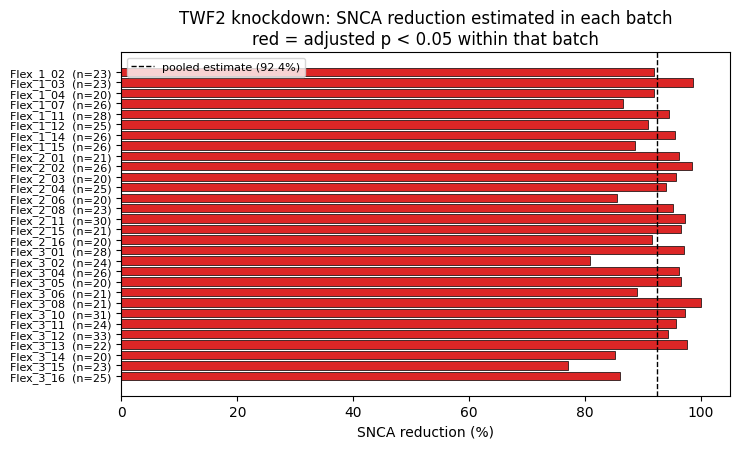

Saved -> figures/Fig9_per_batch_replication.png


In [29]:
# --- figure: per-batch effect ------------------------------------------------
if batch_rows:
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    y = np.arange(len(bdf))
    ax.barh(y, bdf.goi_reduction_pct, color=np.where(bdf.padj < 0.05,
            "#dc2626", "#cbd5e1"), edgecolor="black", lw=.5)
    pooled = sc_tab[sc_tab.perturbation == CAND].goi_reduction_pct.iloc[0]
    ax.axvline(pooled, color="black", ls="--", lw=1,
               label=f"pooled estimate ({pooled:.1f}%)")
    ax.set_yticks(y)
    ax.set_yticklabels([f"{b}  (n={n})" for b, n in
                        zip(bdf.batch, bdf.n_pert_cells)], fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel(f"{GOI} reduction (%)")
    ax.set_title(f"{CAND} knockdown: {GOI} reduction estimated in each batch\n"
                 f"red = adjusted p < 0.05 within that batch")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig("figures/Fig9_per_batch_replication.png", dpi=300)
    plt.show()
    print("Saved -> figures/Fig9_per_batch_replication.png")

In [30]:
if "save_to_drive" in dir():
    save_to_drive("after_replication")

[drive] 34 files -> /content/drive/MyDrive/TWF2_SNCA_Revision/run_20260824_2235/after_replication  (20260824_2345)


## 14. Guide-level concordance

Reviewer comment 1 asks for it and comment 5 asks for independent guide RNAs as
validation. Either the metadata supports this or it does not; the cell below says which.

In [31]:
if GUIDE_KEY is not None:
    gser = adata.obs[GUIDE_KEY].astype(str)
    per_pert = (adata.obs.assign(_g=gser)
                .loc[adata.obs[PERT_COL].astype(str) != CTRL_LABEL]
                .groupby(PERT_COL, observed=True)["_g"].nunique())
    print(f"Distinct guide values per perturbation: median {per_pert.median():.0f}, "
          f"max {per_pert.max()}, "
          f"perturbations with >1: {int((per_pert > 1).sum())} of {len(per_pert)}")
    ex = gser.iloc[0]
    if "|" in ex:
        print(f"Guide values are jointly delivered pairs, e.g. {ex!r}. For targets with "
              f"a single pair, per-guide effects are not separable.")

guide_tab = pd.DataFrame()
if GUIDE_KEY is None or per_pert.max() <= 1:
    print("\nGuide-level concordance cannot be computed for this dataset.")
else:
    guide_arr = adata.obs[GUIDE_KEY].astype(str).values      # positional, not labels
    rows = []
    for p in [x for x in [CAND, GOI] if x in PERTS]:
        cols = [goi_i] + ([gene_index[p]] if p in gene_index else [])
        sub = np.asarray(X_csc[:, cols].todense(), dtype=np.float32)   # (n_obs, 1-2)
        ci = CTRL_IDX[p]
        for gname in np.unique(guide_arr[pert_rows[p]]):
            ridx = pert_rows[p][guide_arr[pert_rows[p]] == gname]
            if len(ridx) < 20:
                continue
            r = wilcoxon_block(sub[ridx], sub[ci], False)
            rows.append({"perturbation": p, "guide": gname, "n_cells": len(ridx),
                         "goi_lfc": float(r["lfc"][0]), "goi_p": float(r["pval"][0]),
                         "self_lfc": float(r["lfc"][1]) if len(cols) > 1 else np.nan})
    guide_tab = pd.DataFrame(rows)
    guide_tab.to_csv("results/10_guide_concordance.csv", index=False)
    print(guide_tab.to_string(index=False))
    for p, s_ in guide_tab.groupby("perturbation"):
        print(f"\n{p}: {GOI} log2FC across {len(s_)} guide values = "
              f"{s_.goi_lfc.mean():+.2f} +/- {s_.goi_lfc.std():.2f}")

Distinct guide values per perturbation: median 1, max 2, perturbations with >1: 17 of 300
Guide values are jointly delivered pairs, e.g. 'CHMP3_P1P2_A|CHMP3_P1P2_B'. For targets with a single pair, per-guide effects are not separable.
perturbation                   guide  n_cells   goi_lfc         goi_p  self_lfc
        TWF2 TWF2_P1P2_A|TWF2_P1P2_B     1008 -3.717194  0.000000e+00 -4.939823
        SNCA SNCA_P1P2_A|SNCA_P1P2_B      386 -4.387402 6.365612e-144 -4.387402

SNCA: SNCA log2FC across 1 guide values = -4.39 +/- nan

TWF2: SNCA log2FC across 1 guide values = -3.72 +/- nan


## 15. Gene constraint annotation

Reviewer comment 6: pLI = 0.00 means there is no strong population-level evidence of
loss-of-function constraint under that metric. It does not mean a gene is non-essential,
and it says nothing about chronic or tissue-specific inhibition. So this section pulls
the fuller picture — pLI, LOEUF (`oe_lof_upper`), the o/e point estimate with its
confidence interval, and missense Z — and labels every output "constraint", never
"essentiality".

LOEUF matters here: it is the metric gnomAD itself now recommends over pLI, it is
continuous rather than a probability that saturates, and a gene can have pLI = 0 simply
because it is short and underpowered. Reporting LOEUF alongside pLI is the difference
between "no evidence of constraint" and the claim v1 made.

In [32]:
GNOMAD_URL = ("https://storage.googleapis.com/gcp-public-data--gnomad/release/2.1.1/"
              "constraint/gnomad.v2.1.1.lof_metrics.by_gene.txt.bgz")
try:
    con = pd.read_csv(GNOMAD_URL, sep="\t", compression="gzip")
    keep_cols = [c for c in ["gene", "pLI", "pRec", "oe_lof", "oe_lof_lower",
                             "oe_lof_upper", "mis_z", "syn_z", "lof_z",
                             "exp_lof", "obs_lof", "cds_length"] if c in con.columns]
    con = con[keep_cols].rename(columns={"oe_lof_upper": "LOEUF"})
    con = con.sort_values("pLI", ascending=False).drop_duplicates("gene")
    con.to_csv("results/11_gnomad_constraint_all.csv", index=False)
    print(f"gnomAD v2.1.1 constraint loaded: {len(con):,} genes, columns {keep_cols}")
except Exception as e:
    print(f"gnomAD download failed ({e}). Constraint annotation will be empty; "
          f"fill it manually from https://gnomad.broadinstitute.org before submitting.")
    con = pd.DataFrame(columns=["gene", "pLI", "LOEUF", "oe_lof", "mis_z"])

gnomAD v2.1.1 constraint loaded: 19,658 genes, columns ['gene', 'pLI', 'pRec', 'oe_lof', 'oe_lof_lower', 'oe_lof_upper', 'mis_z', 'syn_z', 'lof_z', 'exp_lof', 'obs_lof', 'cds_length']


In [33]:
def deg_table(pert):
    """Per-gene DE table for one perturbation, annotated with constraint metrics."""
    i = PERTS.index(pert)
    m = SIG[i]
    t = pd.DataFrame({
        "gene": GENES[m],
        "log2FC": LFC[i][m],
        "padj": PADJ[i][m],
        "reduction_pct": (1 - 2 ** LFC[i][m]) * 100,
        "baseline_mean_control": MEAN_C[i][m],
        "pct_cells_expressing_pert": PCT_P[i][m],
        "pb_log2FC": PB_LFC[i][m],
        "pb_padj": PB_PADJ[i][m],
    })
    t["role"] = np.where(t.gene == pert, "CRISPRi target",
                 np.where(t.gene == GOI, "gene of interest",
                          "non-target differentially expressed gene"))
    if len(con):
        t = t.merge(con, on="gene", how="left")
    return t.sort_values("log2FC")


for p in [x for x in [CAND, GOI] if x in PERTS]:
    t = deg_table(p)
    t.to_csv(f"results/11_DE_{p}.csv", index=False)
    print(f"\n{p} knockdown: {len(t)} genes meeting DE criteria")
    cols = ["gene", "role", "log2FC", "reduction_pct", "padj"]
    cols += [c for c in ["pLI", "LOEUF", "oe_lof"] if c in t.columns]
    print(t[cols].to_string(index=False))

if len(con) and CAND in PERTS:
    tc = deg_table(CAND)
    nt = tc[tc.role == "non-target differentially expressed gene"]
    print(f"\nConstraint summary for {CAND}'s non-target DE genes (n={len(nt)}):")
    if "LOEUF" in nt.columns:
        print(f"  pLI   : {nt.pLI.round(2).tolist()}")
        print(f"  LOEUF : {nt.LOEUF.round(2).tolist()}")
        print(f"  genes with no gnomAD record: "
              f"{int(nt.pLI.isna().sum())} (absence of a score is not evidence "
              f"of tolerance)")
    print("\nWording for the revision: 'none of these genes shows strong evidence of")
    print("loss-of-function constraint in gnomAD (pLI < 0.1, LOEUF as tabulated),")
    print("which is a statement about population genetic evidence, not a")
    print("demonstration that inhibiting them is safe.'")


TWF2 knockdown: 14 genes meeting DE criteria
    gene                                     role    log2FC  reduction_pct         padj          pLI  LOEUF   oe_lof
    TWF2                           CRISPRi target -4.939811      96.741867 0.000000e+00 9.805500e-01  0.302 0.095919
    SNCA                         gene of interest -3.717190      92.396484 0.000000e+00 8.829000e-01  0.429 0.000000
  ZNF233 non-target differentially expressed gene -2.149513      77.461121 2.465107e-19 1.866500e-04  1.633 0.860430
ATP6V0A4 non-target differentially expressed gene -1.041042      51.402367 4.482760e-04 2.150400e-20  1.004 0.763370
   PPM1M non-target differentially expressed gene -0.872824      45.392303 2.692860e-08 9.063900e-04  0.950 0.505980
  SMIM24 non-target differentially expressed gene -0.723432      39.434505 1.674863e-10          NaN    NaN      NaN
   DPEP1 non-target differentially expressed gene -0.618011      34.843128 4.672801e-07 3.473000e-10  1.312 0.863810
    HTR7 non-targe

## 16. Comparing the two perturbations' effects

v1 compared thresholded gene *sets* and read one gene of overlap as evidence of separate
pathways. Set overlap is unstable when the sets are small and the thresholds are
arbitrary, so this adds the test that does not depend on a cutoff: the correlation
between the two perturbations' full log2FC vectors across all genes.

In [34]:
if CAND in PERTS and GOI in PERTS:
    ic, ig = PERTS.index(CAND), PERTS.index(GOI)
    set_c = set(GENES[SIG[ic]]) - {CAND}
    set_g = set(GENES[SIG[ig]]) - {GOI}
    inter = set_c & set_g
    union = set_c | set_g
    M = N_GENES
    hyper_p = stats.hypergeom.sf(len(inter) - 1, M, len(set_c), len(set_g))
    print(f"{CAND} DE genes (excl. self): {len(set_c)}")
    print(f"{GOI} DE genes (excl. self) : {len(set_g)}")
    print(f"Shared                      : {len(inter)} {sorted(inter)}")
    print(f"Jaccard                     : {len(inter)/max(len(union),1):.3f}")
    print(f"Hypergeometric p (enrichment of overlap): {hyper_p:.3g}")

    mask_any = SIG[ic] | SIG[ig]
    r_all = stats.pearsonr(LFC[ic], LFC[ig])
    r_any = stats.pearsonr(LFC[ic][mask_any], LFC[ig][mask_any])
    rho_all = stats.spearmanr(LFC[ic], LFC[ig])
    print(f"\nlog2FC correlation, all {N_GENES:,} genes : r = {r_all[0]:+.3f} "
          f"(p = {r_all[1]:.2g}), rho = {rho_all.statistic:+.3f}")
    print(f"log2FC correlation, DE in either        : r = {r_any[0]:+.3f} "
          f"(p = {r_any[1]:.2g}), n = {int(mask_any.sum())}")
    print("\nA near-zero correlation supports 'the two perturbations produce")
    print("largely non-overlapping transcriptional responses in this dataset'.")
    print("It does not support any claim about mechanism or pathway.")
    overlap_stats = {
        "n_deg_cand": len(set_c), "n_deg_goi": len(set_g),
        "n_shared": len(inter), "shared_genes": sorted(inter),
        "jaccard": len(inter) / max(len(union), 1), "hypergeom_p": float(hyper_p),
        "pearson_r_all_genes": float(r_all[0]), "pearson_p_all_genes": float(r_all[1]),
        "spearman_rho_all_genes": float(rho_all.statistic),
    }
else:
    overlap_stats = {}

TWF2 DE genes (excl. self): 13
SNCA DE genes (excl. self) : 96
Shared                      : 1 [np.str_('HTR7')]
Jaccard                     : 0.009
Hypergeometric p (enrichment of overlap): 0.0936

log2FC correlation, all 12,760 genes : r = +0.124 (p = 4.1e-45), rho = +0.025
log2FC correlation, DE in either        : r = +0.226 (p = 0.018), n = 109

A near-zero correlation supports 'the two perturbations produce
largely non-overlapping transcriptional responses in this dataset'.
It does not support any claim about mechanism or pathway.


## 17. Figures

Every caption stub carries n, thresholds, test, and comparison group (reviewer comment 8).
No panel is labelled "optimal", the comparator perturbation in the volcano panel is named,
and Figure 5 reports constraint metrics rather than an essentiality claim.

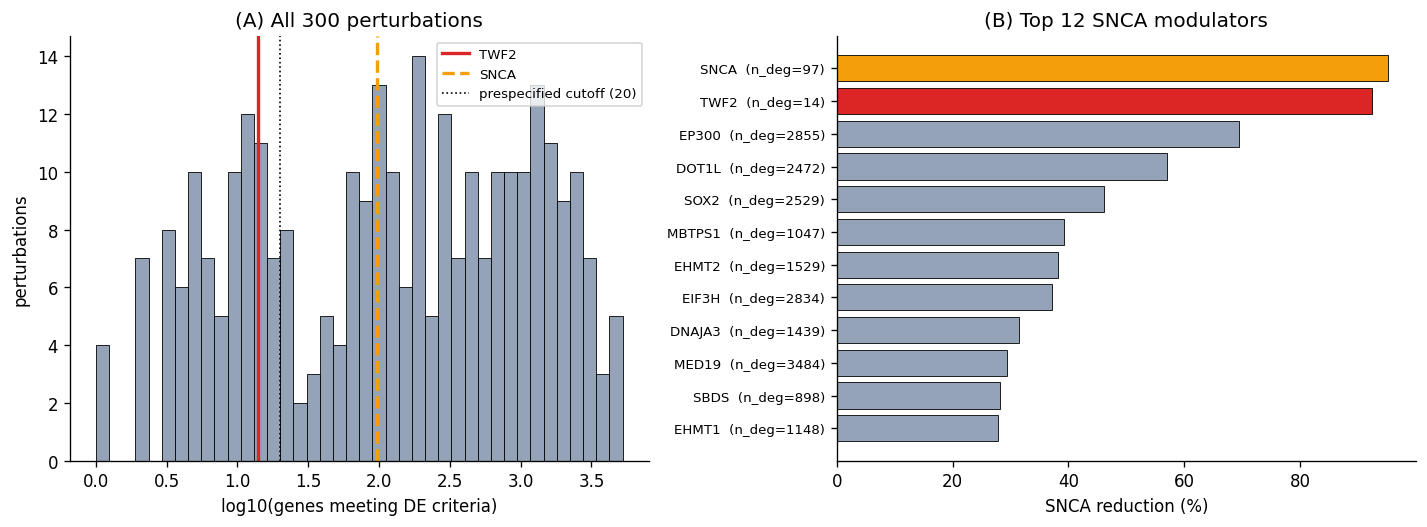

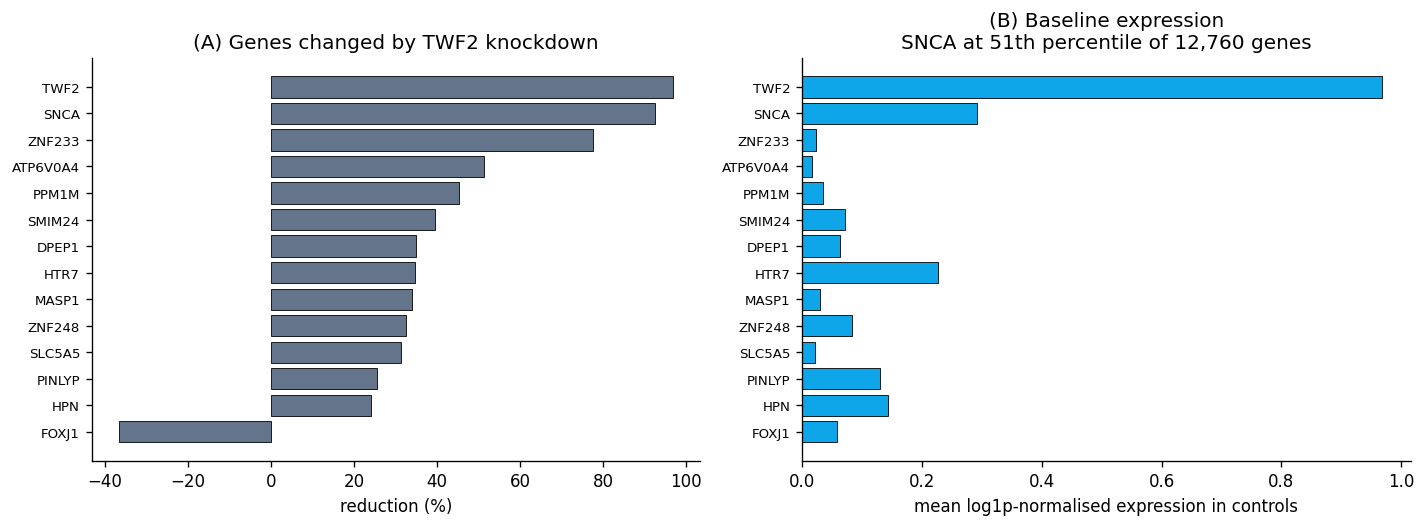

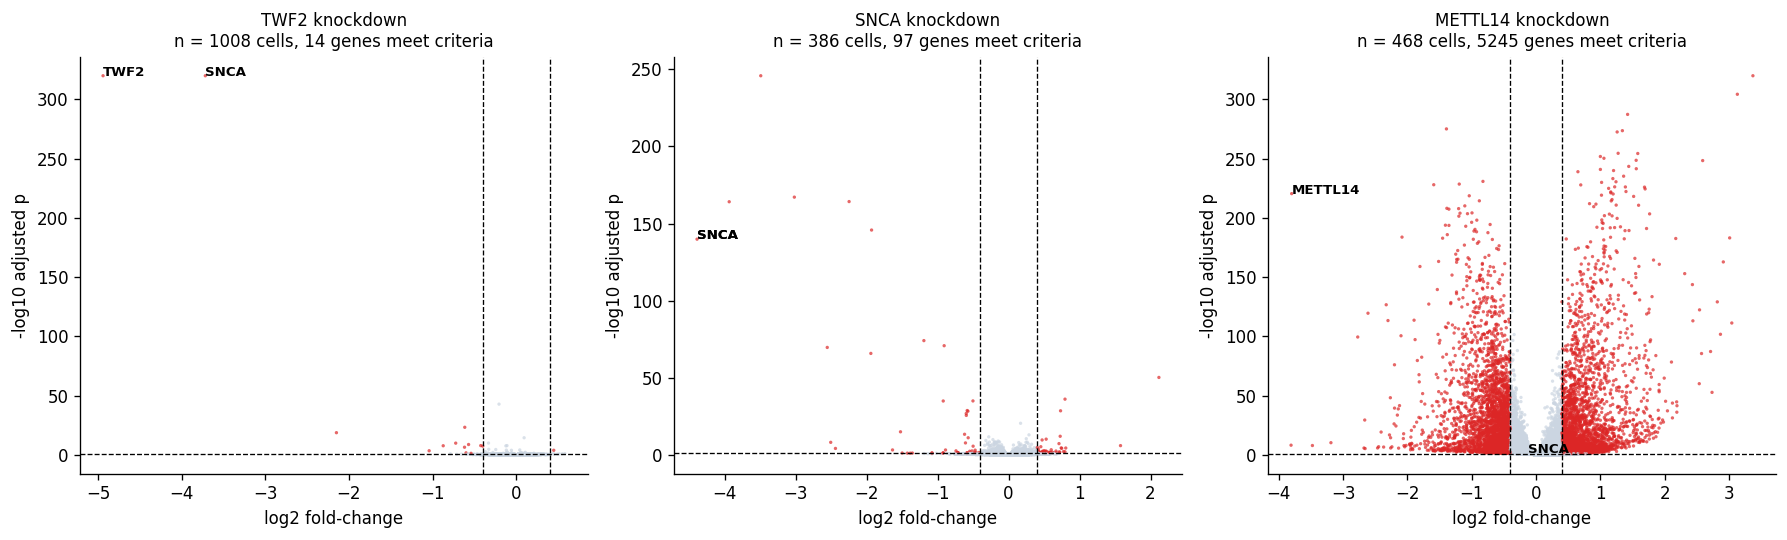

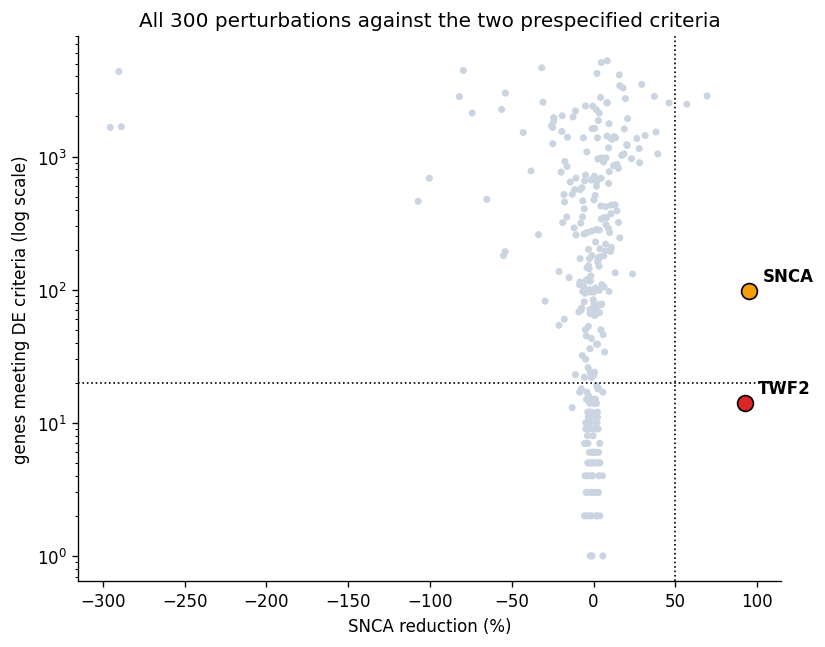

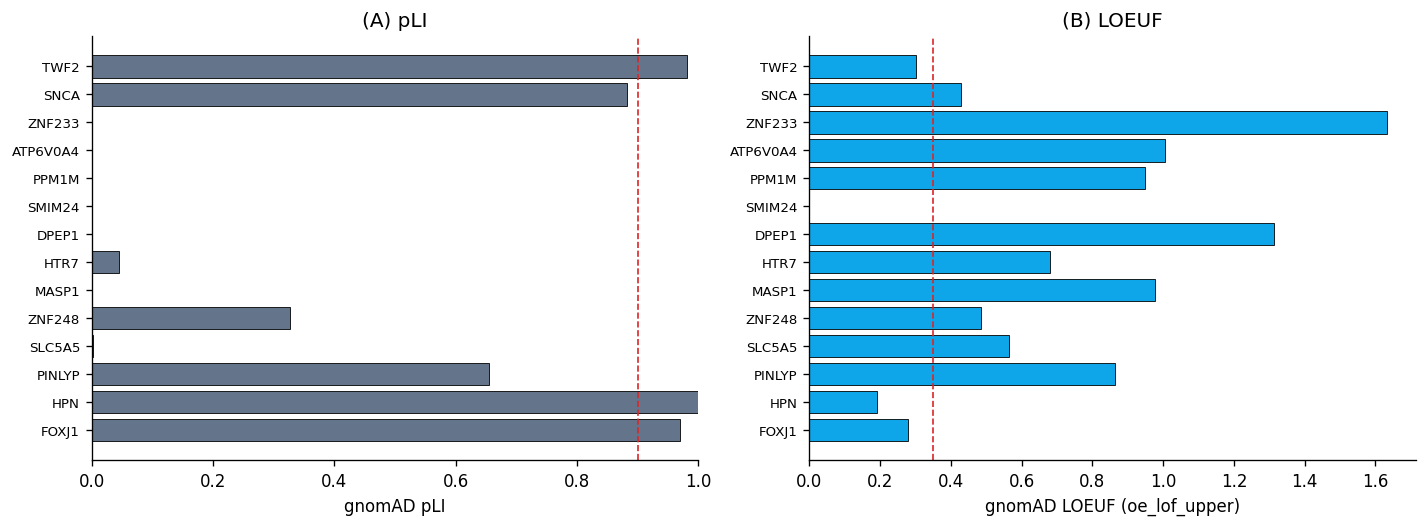

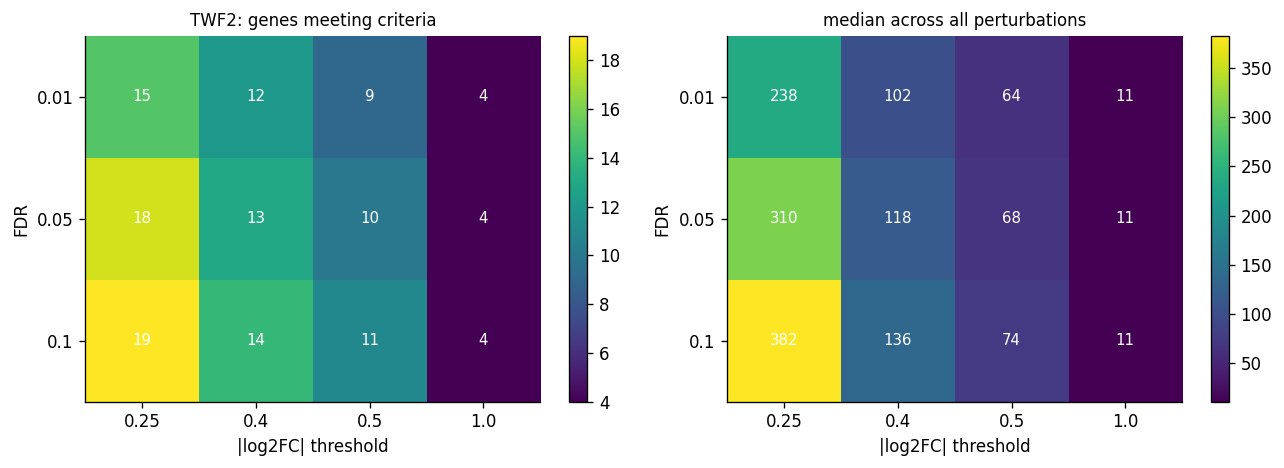

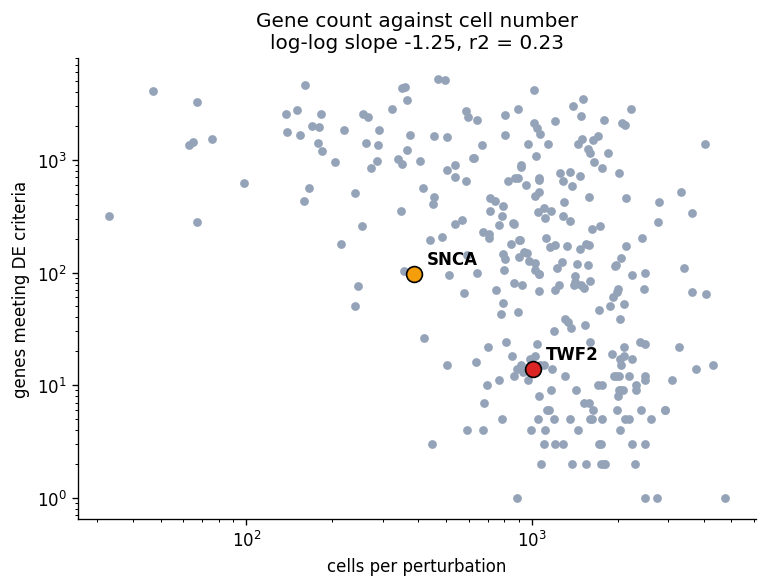

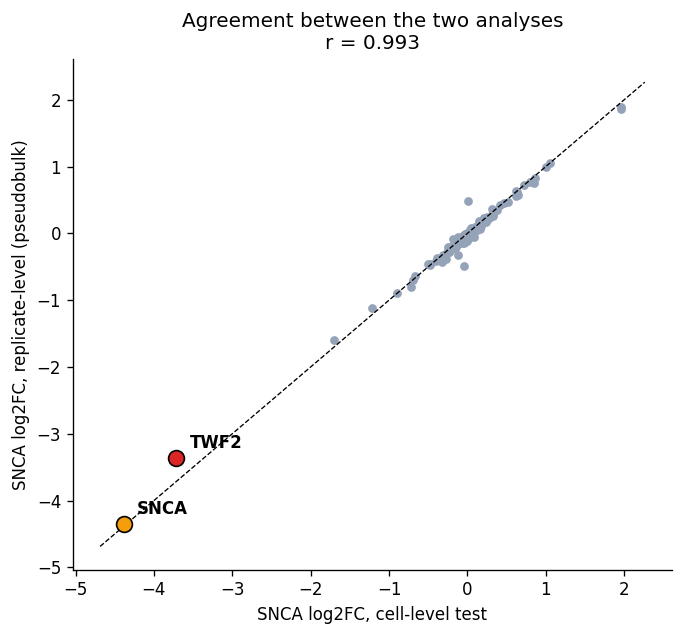


Captions written -> figures/CAPTIONS.md


In [35]:
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})
CAPTIONS = {}
HAS_CAND = CAND in PERTS
ci_ = PERTS.index(CAND) if HAS_CAND else None
gi_ = PERTS.index(GOI) if GOI in PERTS else None

# ---- Figure 1: distribution of n_deg ---------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ax = axes[0]
ax.hist(np.log10(screen.n_deg.clip(lower=1)), bins=40, color="#94a3b8",
        edgecolor="black", linewidth=.5)
if HAS_CAND:
    ax.axvline(np.log10(max(screen.loc[screen.perturbation == CAND, "n_deg"].iloc[0], 1)),
               color="#dc2626", lw=2, label=CAND)
if gi_ is not None:
    ax.axvline(np.log10(max(screen.loc[screen.perturbation == GOI, "n_deg"].iloc[0], 1)),
               color="#f59e0b", lw=2, ls="--", label=GOI)
ax.axvline(np.log10(CFG["SCREEN_MAX_DEG"]), color="black", lw=1, ls=":",
           label=f"prespecified cutoff ({CFG['SCREEN_MAX_DEG']})")
ax.set_xlabel("log10(genes meeting DE criteria)")
ax.set_ylabel("perturbations")
ax.set_title(f"(A) All {len(screen)} perturbations")
ax.legend(fontsize=8)

ax = axes[1]
top = screen.nlargest(12, "goi_reduction_pct")
cols = ["#dc2626" if p == CAND else "#f59e0b" if p == GOI else "#94a3b8"
        for p in top.perturbation]
ax.barh(range(len(top)), top.goi_reduction_pct, color=cols, edgecolor="black", lw=.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels([f"{p}  (n_deg={d})" for p, d in
                    zip(top.perturbation, top.n_deg)], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel(f"{GOI} reduction (%)")
ax.set_title(f"(B) Top 12 {GOI} modulators")
fig.tight_layout(); fig.savefig("figures/Fig1_landscape.png"); plt.show()
CAPTIONS["Figure 1"] = (
    f"Distribution of the number of genes meeting the prespecified differential "
    f"expression criteria (Benjamini-Hochberg adjusted p < {CFG['FDR_ALPHA']} and "
    f"|log2 fold-change| > {CFG['LFC_MIN']}; tie-corrected Wilcoxon rank-sum test "
    f"versus non-targeting control cells matched on processing batch) across all "
    f"{len(screen)} perturbations analysed. (B) The twelve perturbations producing "
    f"the largest reduction in {GOI} mRNA. Dotted line marks the prespecified "
    f"operational cutoff of {CFG['SCREEN_MAX_DEG']} genes used to define the screen.")

# ---- Figure 2: baseline expression context ---------------------------------
if HAS_CAND:
    t = deg_table(CAND)
    base_all = MEAN_C[ci_]
    pct_rank = 100 * (base_all < MEAN_C[ci_][goi_i]).mean()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].barh(range(len(t)), t.reduction_pct, color="#64748b",
                 edgecolor="black", lw=.5)
    axes[0].set_yticks(range(len(t))); axes[0].set_yticklabels(t.gene, fontsize=8)
    axes[0].invert_yaxis(); axes[0].set_xlabel("reduction (%)")
    axes[0].set_title(f"(A) Genes changed by {CAND} knockdown")
    axes[1].barh(range(len(t)), t.baseline_mean_control, color="#0ea5e9",
                 edgecolor="black", lw=.5)
    axes[1].set_yticks(range(len(t))); axes[1].set_yticklabels(t.gene, fontsize=8)
    axes[1].invert_yaxis()
    axes[1].set_xlabel("mean log1p-normalised expression in controls")
    axes[1].set_title(f"(B) Baseline expression\n{GOI} at {pct_rank:.0f}th percentile "
                      f"of {N_GENES:,} genes")
    fig.tight_layout(); fig.savefig("figures/Fig2_expression_context.png"); plt.show()
    CAPTIONS["Figure 2"] = (
        f"(A) Percent reduction for each gene meeting DE criteria under {CAND} "
        f"knockdown (n = {len(pert_rows[CAND])} perturbed cells versus "
        f"{len(CTRL_IDX[CAND]):,} matched non-targeting control cells). "
        f"(B) Mean expression of the same genes in control cells; {GOI} sits at the "
        f"{pct_rank:.0f}th percentile of the {N_GENES:,} analysed genes, so the "
        f"observed reduction is not a floor effect on a weakly expressed transcript.")

# ---- Figure 3: volcanoes, comparator named ---------------------------------
comparator = screen.nlargest(1, "n_deg").perturbation.iloc[0]
panels = [x for x in [CAND, GOI, comparator] if x in PERTS]
fig, axes = plt.subplots(1, len(panels), figsize=(5 * len(panels), 4.6))
axes = np.atleast_1d(axes)
for ax, p in zip(axes, panels):
    i = PERTS.index(p)
    y = -np.log10(np.maximum(PADJ[i], 1e-320))
    ax.scatter(LFC[i], y, s=4, c=np.where(SIG[i], "#dc2626", "#cbd5e1"),
               linewidths=0, alpha=.7)
    ax.axhline(-np.log10(CFG["FDR_ALPHA"]), color="k", ls="--", lw=.8)
    for v in (-CFG["LFC_MIN"], CFG["LFC_MIN"]):
        ax.axvline(v, color="k", ls="--", lw=.8)
    for g in [p, GOI]:
        if g in gene_index:
            j = gene_index[g]
            ax.annotate(g, (LFC[i, j], y[j]), fontsize=8, fontweight="bold")
    ax.set_xlabel("log2 fold-change"); ax.set_ylabel("-log10 adjusted p")
    ax.set_title(f"{p} knockdown\nn = {len(pert_rows[p])} cells, "
                 f"{int(SIG[i].sum())} genes meet criteria", fontsize=10)
fig.tight_layout(); fig.savefig("figures/Fig3_volcanoes.png"); plt.show()
CAPTIONS["Figure 3"] = (
    f"Volcano plots for " + ", ".join(panels) + f". {comparator} is shown as the "
    f"most transcriptionally active perturbation in this dataset and is named rather "
    f"than described as 'a non-specific perturbation'. Dashed lines: adjusted "
    f"p = {CFG['FDR_ALPHA']} and |log2FC| = {CFG['LFC_MIN']}. Tie-corrected Wilcoxon "
    f"rank-sum test with Benjamini-Hochberg correction across {N_GENES:,} genes, each "
    f"perturbation versus batch-matched non-targeting controls.")

# ---- Figure 4: effect vs DEG count, no value-laden labels ------------------
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(screen.goi_reduction_pct, screen.n_deg.clip(lower=1), s=18,
           c="#cbd5e1", edgecolor="none")
for g, c in [(CAND, "#dc2626"), (GOI, "#f59e0b")]:
    if g in screen.perturbation.values:
        r = screen[screen.perturbation == g].iloc[0]
        ax.scatter([r.goi_reduction_pct], [max(r.n_deg, 1)], s=90, c=c,
                   edgecolor="black", zorder=5)
        ax.annotate(g, (r.goi_reduction_pct, max(r.n_deg, 1)),
                    textcoords="offset points", xytext=(8, 6), fontweight="bold")
ax.axhline(CFG["SCREEN_MAX_DEG"], color="k", ls=":", lw=1)
ax.axvline(CFG["SCREEN_MIN_SNCA_REDUCTION"], color="k", ls=":", lw=1)
ax.set_yscale("log")
ax.set_xlabel(f"{GOI} reduction (%)")
ax.set_ylabel("genes meeting DE criteria (log scale)")
ax.set_title(f"All {len(screen)} perturbations against the two prespecified criteria")
fig.tight_layout(); fig.savefig("figures/Fig4_criteria_plot.png"); plt.show()
CAPTIONS["Figure 4"] = (
    f"Each of the {len(screen)} perturbations plotted by {GOI} reduction against the "
    f"number of genes meeting DE criteria. Dotted lines are the two criteria fixed "
    f"before analysis ({CFG['SCREEN_MIN_SNCA_REDUCTION']}% reduction; "
    f"<= {CFG['SCREEN_MAX_DEG']} genes). The axes describe measured quantities; no "
    f"region is designated optimal.")

# ---- Figure 5: constraint metrics -----------------------------------------
if HAS_CAND and len(con):
    t = deg_table(CAND)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].barh(range(len(t)), t.pLI.fillna(0), color="#64748b",
                 edgecolor="black", lw=.5)
    axes[0].axvline(0.9, color="#dc2626", ls="--", lw=1)
    axes[0].set_yticks(range(len(t))); axes[0].set_yticklabels(t.gene, fontsize=8)
    axes[0].invert_yaxis(); axes[0].set_xlim(0, 1)
    axes[0].set_xlabel("gnomAD pLI"); axes[0].set_title("(A) pLI")
    if "LOEUF" in t.columns:
        axes[1].barh(range(len(t)), t.LOEUF.fillna(np.nan), color="#0ea5e9",
                     edgecolor="black", lw=.5)
        axes[1].axvline(0.35, color="#dc2626", ls="--", lw=1)
        axes[1].set_yticks(range(len(t))); axes[1].set_yticklabels(t.gene, fontsize=8)
        axes[1].invert_yaxis()
        axes[1].set_xlabel("gnomAD LOEUF (oe_lof_upper)")
        axes[1].set_title("(B) LOEUF")
    fig.tight_layout(); fig.savefig("figures/Fig5_constraint.png"); plt.show()
    CAPTIONS["Figure 5"] = (
        f"Loss-of-function constraint metrics (gnomAD v2.1.1) for the genes meeting "
        f"DE criteria under {CAND} knockdown. (A) pLI, the probability of "
        f"loss-of-function intolerance; the dashed line marks the conventional "
        f"pLI >= 0.9 threshold for constraint. (B) LOEUF, the upper bound of the "
        f"observed/expected loss-of-function ratio; dashed line at 0.35, gnomAD's "
        f"suggested threshold for constrained genes. Low pLI indicates an absence of "
        f"population-level evidence for constraint under this metric and is not a "
        f"measure of essentiality or of tolerance to pharmacological inhibition.")

# ---- Figure 6: threshold sensitivity heatmap ------------------------------
if HAS_CAND and f"{CAND}_n_deg" in sens.columns:
    piv6 = sens.pivot(index="fdr", columns="lfc_min", values=f"{CAND}_n_deg")
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, (pv, title) in zip(axes, [
            (piv6, f"{CAND}: genes meeting criteria"),
            (sens.pivot(index="fdr", columns="lfc_min", values="median_n_deg"),
             "median across all perturbations")]):
        im = ax.imshow(pv.values, cmap="viridis", aspect="auto")
        ax.set_xticks(range(pv.shape[1])); ax.set_xticklabels(pv.columns)
        ax.set_yticks(range(pv.shape[0])); ax.set_yticklabels(pv.index)
        ax.set_xlabel("|log2FC| threshold"); ax.set_ylabel("FDR")
        ax.set_title(title, fontsize=10)
        for a in range(pv.shape[0]):
            for b in range(pv.shape[1]):
                ax.text(b, a, f"{pv.values[a,b]:.0f}", ha="center", va="center",
                        color="w", fontsize=9)
        fig.colorbar(im, ax=ax)
    fig.tight_layout(); fig.savefig("figures/Fig6_threshold_sensitivity.png"); plt.show()
    CAPTIONS["Figure 6"] = (
        "Sensitivity of the gene-count metric to the differential expression "
        "thresholds, across FDR and |log2 fold-change| cutoffs. The count is a "
        "function of the chosen thresholds as well as of the perturbation.")

# ---- Figure 7: power diagnostic -------------------------------------------
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(screen.n_cells, screen.n_deg.clip(lower=1), s=18, c="#94a3b8")
for g, c in [(CAND, "#dc2626"), (GOI, "#f59e0b")]:
    if g in screen.perturbation.values:
        r = screen[screen.perturbation == g].iloc[0]
        ax.scatter([r.n_cells], [max(r.n_deg, 1)], s=90, c=c, edgecolor="black", zorder=5)
        ax.annotate(g, (r.n_cells, max(r.n_deg, 1)), textcoords="offset points",
                    xytext=(8, 6), fontweight="bold")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("cells per perturbation"); ax.set_ylabel("genes meeting DE criteria")
ax.set_title(f"Gene count against cell number\n"
             f"log-log slope {lr.slope:.2f}, r2 = {lr.rvalue**2:.2f}")
fig.tight_layout(); fig.savefig("figures/Fig7_power_diagnostic.png"); plt.show()
CAPTIONS["Figure 7"] = (
    f"Number of genes meeting DE criteria against the number of cells assayed per "
    f"perturbation (log-log; least-squares slope {lr.slope:.2f}, "
    f"r2 = {lr.rvalue**2:.2f}, p = {lr.pvalue:.2g}). "
    + ("The negative slope indicates that perturbations recovered in fewer cells "
       "produced more differentially expressed genes, consistent with cell number "
       "acting as a marker of perturbation toxicity rather than of statistical power. "
       if lr.slope < 0 else
       "The positive slope indicates that this count partly tracks statistical power. ")
    + f"Either way the count depends on factors beyond molecular specificity and "
      f"should not be interpreted as a specificity measure on its own.")

# ---- Figure 8: cell-level vs pseudobulk -----------------------------------
fig, ax = plt.subplots(figsize=(5.8, 5.4))
ok = both.pb_goi_lfc.notna()
ax.scatter(both.loc[ok, "goi_lfc"], both.loc[ok, "pb_goi_lfc"], s=18, c="#94a3b8")
for g, c in [(CAND, "#dc2626"), (GOI, "#f59e0b")]:
    if g in both.perturbation.values:
        r = both[both.perturbation == g].iloc[0]
        ax.scatter([r.goi_lfc], [r.pb_goi_lfc], s=90, c=c, edgecolor="black", zorder=5)
        ax.annotate(g, (r.goi_lfc, r.pb_goi_lfc), textcoords="offset points",
                    xytext=(8, 6), fontweight="bold")
lim = [min(both.loc[ok, "goi_lfc"].min(), both.loc[ok, "pb_goi_lfc"].min()) - .3,
       max(both.loc[ok, "goi_lfc"].max(), both.loc[ok, "pb_goi_lfc"].max()) + .3]
ax.plot(lim, lim, ls="--", c="k", lw=.8)
ax.set_xlabel(f"{GOI} log2FC, cell-level test")
ax.set_ylabel(f"{GOI} log2FC, replicate-level (pseudobulk)")
ax.set_title(f"Agreement between the two analyses\nr = {r_goi[0]:.3f}")
fig.tight_layout(); fig.savefig("figures/Fig8_pseudobulk_concordance.png"); plt.show()
CAPTIONS["Figure 8"] = (
    f"{GOI} log2 fold-change estimated from the cell-level Wilcoxon test against the "
    f"replicate-level pseudobulk estimate, for all {int(ok.sum())} perturbations "
    f"(Pearson r = {r_goi[0]:.3f}). Dashed line is identity.")

if "bdf" in dir() and len(globals().get("batch_rows", [])):
    CAPTIONS["Figure 9"] = (
        f"{CAND} knockdown effect on {GOI}, estimated separately within each "
        f"processing batch that contained both perturbed and non-targeting cells "
        f"(n = {len(bdf)} batches; Wilcoxon rank-sum test per batch, "
        f"Benjamini-Hochberg corrected across batches). Dashed line: the pooled "
        f"estimate from all cells. Batch-wise estimation is the strongest "
        f"independence check this dataset supports; it is not biological "
        f"replication.")

with open("figures/CAPTIONS.md", "w") as f:
    for k, v in CAPTIONS.items():
        f.write(f"**{k}.** {v}\n\n")
print("\nCaptions written -> figures/CAPTIONS.md")

## 18. Single source of truth for the manuscript

Reviewer comment 4 found the text, Table 1, and Figures disagreeing. The fix is
structural: every number the manuscript quotes is written once, here, and every figure
above was drawn from the same objects. Paste from this block; do not retype.

In [36]:
MN = {
    "generated": pd.Timestamp.now().isoformat(timespec="seconds"),
    "config": CFG,
    "environment": VERSIONS,
    "replicate_structure": REPLICATE_STATUS,
    "dataset": {
        "source": CFG.get("DATA_SOURCE_RESOLVED", CFG["DATA_SOURCE"]),
        "control_matching": REPLICATE_STATUS.get("control_matching_used"),
        "replicates_are_experimental_units": bool(REPLICATE_IS_BIOLOGICAL),
        "n_cells_total": int(adata.n_obs),
        "n_control_cells": int(ctrl_mask_all.sum()),
        "n_genes_before_filter": int(n_before),
        "n_genes_analysed": int(N_GENES),
        "n_perturbation_targets_in_file": int(N_PERT_TOTAL),
        "n_perturbations_screened": int(len(PERTS)),
        "splits_present": sorted(set(split_arr.tolist())),
        "cells_per_perturbation_min": int(pert_counts.min()),
        "cells_per_perturbation_median": float(pert_counts.median()),
        "cells_per_perturbation_max": int(pert_counts.max()),
    },
    "screen": {
        "median_n_deg": float(screen.n_deg.median()),
        "mean_n_deg": float(screen.n_deg.mean()),
        "min_n_deg": int(screen.n_deg.min()),
        "max_n_deg": int(screen.n_deg.max()),
        "n_perts_at_or_below_cutoff": int((screen.n_deg <= CFG["SCREEN_MAX_DEG"]).sum()),
        "n_qualifying": int(sc_tab.qualifies_cell_level.sum()),
        "qualifying_perturbations": sc_tab.loc[sc_tab.qualifies_cell_level,
                                               "perturbation"].tolist(),
        "null_control_vs_control_mean_n_deg": float(null_summary.n_deg_null.mean()),
    },
    "overlap": overlap_stats,
    "v1_reported": CFG["V1_REPORTED"],
    "engine_check": (ENGINE_CHECK if "ENGINE_CHECK" in dir() else None),
    "n_perts_testable_at_replicate_level": (
        int(PB_COVERAGE.testable_at_replicate_level.sum())
        if "PB_COVERAGE" in dir() else None),
    "perts_not_testable_at_replicate_level": (
        PB_COVERAGE.loc[~PB_COVERAGE.testable_at_replicate_level,
                        "perturbation"].tolist()
        if "PB_COVERAGE" in dir() else None),
    "subpartitioned_perturbations": (len(SUBPARTITIONED)
                                     if "SUBPARTITIONED" in dir() else 0),
}
if batch_rows:
    _red = bdf.goi_reduction_pct.dropna()
    _lf = bdf.goi_lfc.dropna()
    MN["per_batch_replication"] = {
        "n_batches_estimated": int(len(bdf)),
        "n_batches_zero_signal_in_perturbed": int(bdf.get(
            "zero_in_perturbed", pd.Series(False, index=bdf.index)).sum()),
        "n_batches_showing_reduction": int((_red > 0).sum()),
        "sign_test_p": float(stats.binomtest(int((_red > 0).sum()),
                                             len(_red), 0.5).pvalue),
        "median_reduction_pct": float(_red.median()),
        "mean_reduction_pct": float(_red.mean()),
        "sd_reduction_pct": float(_red.std()),
        "min_reduction_pct": float(_red.min()),
        "max_reduction_pct": float(_red.max()),
        "median_log2FC": float(_lf.median()) if len(_lf) else float("nan"),
        "one_sample_t_p": (float(stats.ttest_1samp(_lf, 0.0).pvalue)
                           if len(_lf) > 1 else float("nan")),
    }
for g in [x for x in [CAND, GOI] if x in PERTS]:
    r = sc_tab[sc_tab.perturbation == g].iloc[0]
    s = agg[agg.perturbation == g]
    MN[g] = {
        "n_cells": int(r.n_cells),
        "n_control_cells": int(r.n_control_cells),
        "n_deg": int(r.n_deg),
        "n_deg_excl_target": int(r.n_deg_excl_self),
        "self_knockdown_pct": float(r.self_knockdown_pct),
        "goi_log2FC": float(r.goi_lfc),
        "goi_reduction_pct": float(r.goi_reduction_pct),
        "goi_padj": float(r.goi_padj),
        "goi_zero_in_pert": bool(r.goi_zero_in_pert),
        "pseudobulk_goi_log2FC": float(r.pb_goi_lfc),
        "pseudobulk_goi_reduction_pct": float(r.pb_goi_reduction_pct),
        "pseudobulk_goi_padj": float(r.pb_goi_padj),
        "n_deg_across_subsamples_mean": (float(s.n_deg_mean.iloc[0]) if len(s)
                                        else float("nan")),
        "n_deg_across_subsamples_sd": (float(s.n_deg_sd.iloc[0]) if len(s)
                                      else float("nan")),
        "rank_by_goi_reduction": int((sc_tab.goi_reduction_pct >
                                      r.goi_reduction_pct).sum() + 1),
        "rank_by_fewest_n_deg": int((sc_tab.n_deg < r.n_deg).sum() + 1),
        "qc_flag": bool(r.qc_flag),
    }
if CAND in MN and GOI in MN:
    MN["ratio_n_deg_GOI_over_CAND"] = MN[GOI]["n_deg"] / max(MN[CAND]["n_deg"], 1)
    MN["ratio_across_threshold_grid"] = {
        f"fdr{row.fdr}_lfc{row.lfc_min}": float(row.ratio_GOI_over_CAND)
        for row in sens.itertuples() if hasattr(row, "ratio_GOI_over_CAND")}

with open("results/manuscript_numbers.json", "w") as f:
    json.dump(MN, f, indent=2, default=str)
print(json.dumps(MN, indent=2, default=str)[:4000])

{
  "generated": "2026-08-24T23:45:28",
  "config": {
    "SEED": 42,
    "N_CTRL_SUBSAMPLES": 5,
    "SUBSAMPLE_SEEDS": [
      11,
      22,
      33,
      44,
      55
    ],
    "FDR_ALPHA": 0.1,
    "LFC_MIN": 0.4,
    "SCREEN_MAX_DEG": 20,
    "SCREEN_MIN_SNCA_REDUCTION": 50.0,
    "GENE_MIN_PCT_CTRL": 0.05,
    "MIN_CELLS_PER_PERT": 25,
    "PSEUDOREP_K_PERT": 3,
    "PSEUDOREP_K_CTRL": 8,
    "PSEUDOBULK_MIN_CELLS_PER_REP": 8,
    "PAIRED_PSEUDOBULK": true,
    "MIN_CELLS_PER_BATCH_EST": 20,
    "V1_REPORTED": {
      "n_perturbations": 51,
      "snca_reduction_by_TWF2_pct": 91.1,
      "TWF2_n_deg": 8,
      "SNCA_n_deg": 39,
      "snca_self_reduction_pct": 94.2,
      "specificity_ratio": 4.9
    },
    "SENS_FDR": [
      0.01,
      0.05,
      0.1
    ],
    "SENS_LFC": [
      0.25,
      0.4,
      0.5,
      1.0
    ],
    "GENE_CHUNK": 1024,
    "USE_GPU": true,
    "DATA_SOURCE": "auto",
    "GCS_PROJECT": "project-425f6c8a-0dc9-4663-84b",
    "GCS_SPLITS": [
     

In [37]:
d = MN["dataset"]; s = MN["screen"]
print("=" * 78)
print("PASTE-READY NUMBERS (check every sentence against your own reading)")
print("=" * 78)
print(f"""
METHODS
  We analysed all {d['n_perturbations_screened']} CRISPRi perturbations present in the
  {d['source']} release of the Virtual Cell Challenge 2025 dataset
  ({d['n_cells_total']:,} cells, including {d['n_control_cells']:,} non-targeting
  control cells; splits: {', '.join(d['splits_present'])}). No perturbations were
  excluded or sampled. Genes detected in more than
  {CFG['GENE_MIN_PCT_CTRL']*100:.0f}% of control cells were retained
  ({d['n_genes_analysed']:,} of {d['n_genes_before_filter']:,}).
  Each perturbation was compared with non-targeting control cells matched on
  processing batch, using a tie-corrected Wilcoxon rank-sum test with
  Benjamini-Hochberg correction across {d['n_genes_analysed']:,} genes (random seed
  {CFG['SEED']}). Note that scanpy's rank_genes_groups omits the tie correction by
  default; on zero-inflated counts this matters, and the tie-corrected form was used
  here (agreement with scipy.stats.mannwhitneyu is verified in the supplementary
  notebook).
  Because single cells are not independent replicates, a parallel replicate-level
  analysis was performed on pseudobulk profiles aggregated by
  {REPLICATE_STATUS['batch_key'] or REPLICATE_STATUS['guide_key'] or 'seeded random partition (technical)'},
  compared within batch and, for the shortlist, modelled with DESeq2 using
  ~batch + condition.

RESULTS
  Genes meeting DE criteria ranged from {s['min_n_deg']} to {s['max_n_deg']}
  (median {s['median_n_deg']:.0f}) across the {d['n_perturbations_screened']}
  perturbations. A control-versus-control comparison yielded a mean of
  {s['null_control_vs_control_mean_n_deg']:.1f} genes, giving the empirical floor
  for this metric.
  {s['n_perts_at_or_below_cutoff']} perturbations produced no more than
  {CFG['SCREEN_MAX_DEG']} genes meeting criteria; {s['n_qualifying']} also met the
  prespecified {GOI} criterion: {', '.join(s['qualifying_perturbations']) or 'none'}.
""")
if CAND in MN:
    c = MN[CAND]
    print(f"""  {CAND} knockdown was associated with a {c['goi_reduction_pct']:.1f}% lower
  {GOI} mRNA level (log2FC {c['goi_log2FC']:+.2f}, adjusted p = {fmt_p(c['goi_padj'])};
  n = {c['n_cells']} perturbed cells versus {c['n_control_cells']:,} controls), and
  {c['n_deg']} genes met the DE criteria ({c['n_deg_excl_target']} excluding the
  CRISPRi target itself). Knockdown of {CAND} itself was
  {c['self_knockdown_pct']:.1f}%. Across five seeded control subsamples the gene
  count was {c['n_deg_across_subsamples_mean']:.1f} +/- {c['n_deg_across_subsamples_sd']:.1f}.
  In the replicate-level analysis the {GOI} estimate was
  {c['pseudobulk_goi_reduction_pct']:.1f}% (log2FC {c['pseudobulk_goi_log2FC']:+.2f},
  adjusted p = {fmt_p(c['pseudobulk_goi_padj'])}).
  Among all {d['n_perturbations_screened']} perturbations, {CAND} ranked
  {c['rank_by_goi_reduction']} by {GOI} reduction and {c['rank_by_fewest_n_deg']} by
  fewest genes meeting criteria.""")
if "ratio_n_deg_GOI_over_CAND" in MN:
    print(f"""
  Direct {GOI} knockdown produced {MN['ratio_n_deg_GOI_over_CAND']:.1f}-fold more genes
  meeting the DE criteria than {CAND} knockdown at the primary thresholds. Across the
  sensitivity grid this ratio ranged from
  {min(MN['ratio_across_threshold_grid'].values()):.1f} to
  {max(MN['ratio_across_threshold_grid'].values()):.1f}.
  (Phrase it this way. Do not write "N-fold more specific".)""")
if "per_batch_replication" in MN:
    b = MN["per_batch_replication"]
    print(f"""
REPLICATION
  The association was re-estimated within each processing batch containing both
  {CAND} and non-targeting cells. A reduction in {GOI} was observed in
  {b['n_batches_showing_reduction']} of {b['n_batches_estimated']} batches
  (sign test p = {b['sign_test_p']:.3g}; median {b['median_reduction_pct']:.1f}%,
  range {b['min_reduction_pct']:.1f}-{b['max_reduction_pct']:.1f}%; one-sample
  t-test on batch-level log2 fold-changes p = {b['one_sample_t_p']:.3g}). Batches
  are processing units, not independent biological replicates.""")
print("\n" + "=" * 78)

PASTE-READY NUMBERS (check every sentence against your own reading)

METHODS
  We analysed all 300 CRISPRi perturbations present in the
  gcs_full release of the Virtual Cell Challenge 2025 dataset
  (491,046 cells, including 114,528 non-targeting
  control cells; splits: test, train, validation). No perturbations were
  excluded or sampled. Genes detected in more than
  5% of control cells were retained
  (12,760 of 18,080).
  Each perturbation was compared with non-targeting control cells matched on
  processing batch, using a tie-corrected Wilcoxon rank-sum test with
  Benjamini-Hochberg correction across 12,760 genes (random seed
  42). Note that scanpy's rank_genes_groups omits the tie correction by
  default; on zero-inflated counts this matters, and the tie-corrected form was used
  here (agreement with scipy.stats.mannwhitneyu is verified in the supplementary
  notebook).
  Because single cells are not independent replicates, a parallel replicate-level
  analysis was performed 

## 19. What still needs a human decision

Things this notebook deliberately does **not** decide for you.

1. **Table 1.** Build it from `results/11_DE_TWF2.csv`. Add a footnote stating whether
   the row count includes the CRISPRi target and the gene of interest — reviewer comment 4
   asked for exactly that and it costs one sentence.
2. **The denominator.** §0 prints the target count from the released `pert_counts_*`
   tables and §4 counts the targets actually present in the loaded matrices. Quote the
   §4 number, and say which splits were loaded. If it comes out at ~150 rather than
   300, only the training split was read and the Methods sentence must say so.
3. **Replicate language.** If §4 found no batch or guide field, the pseudobulk replicates
   are technical. Write that plainly. "Replicate-aware analysis using technical
   pseudo-replicates, since the released metadata does not identify guides or batches"
   is defensible; implying biological replication is not.
4. **The specificity framing.** Reviewer comment 3 is right and the fix is vocabulary,
   not statistics. Everywhere v1 said "more specific", say "produced fewer genes meeting
   the differential expression criteria", and cite Figure 7 for why the two are not the
   same thing.
5. **Safety language.** Delete "safer", "favorable safety margin", "safely inhibited",
   "likely well-tolerated". §15 gives you the replacement: an absence of population-level
   evidence for loss-of-function constraint.
6. **Mechanism.** The mRNA-stability-at-synaptic-terminals paragraph has no support in
   any output here. Either mark it explicitly as an untested hypothesis in one sentence
   or cut it. The HTR7/vortioxetine argument should go.
7. **Scope.** Every claim is an association in H1 human embryonic stem cells at the
   transcript level. The title and abstract should say so.

In [38]:
print("Outputs")
print("=" * 70)
for d_ in ["results", "figures"]:
    for f in sorted(os.listdir(d_)):
        print(f"  {d_}/{f}  ({os.path.getsize(os.path.join(d_, f))/1024:.0f} KB)")
if "save_to_drive" in dir():
    dest = save_to_drive("final")
    if dest:
        _shutil.make_archive(dest, "zip", dest)
        print(f"Zipped -> {dest}.zip")
else:
    print("\nArchive them with:")
    print("  !zip -qr twf2_revision_outputs.zip results figures && echo done")

Outputs
  results/00_config.json  (2 KB)
  results/00_data_manifest.csv  (0 KB)
  results/00_environment.json  (0 KB)
  results/00_pert_counts_test.csv  (2 KB)
  results/00_pert_counts_train.csv  (3 KB)
  results/00_pert_counts_validation.csv  (1 KB)
  results/00_preflight.json  (0 KB)
  results/01_batch_by_split.csv  (1 KB)
  results/01_batch_composition.csv  (1 KB)
  results/01_batches_per_perturbation.csv  (3 KB)
  results/01_cells_per_perturbation.csv  (3 KB)
  results/01_obs_inventory.csv  (0 KB)
  results/01_replicate_structure.json  (0 KB)
  results/02_qc_per_perturbation.csv  (40 KB)
  results/03_engine_check.json  (0 KB)
  results/03_genes_analysed.csv  (80 KB)
  results/03_pseudobulk_coverage.csv  (5 KB)
  results/03_pseudobulk_samples.csv  (686 KB)
  results/04_cell_level_screen.csv  (60 KB)
  results/04_cell_level_screen_matrices.npz  (59706 KB)
  results/04_null_calibration.csv  (0 KB)
  results/05_combined_screen.csv  (91 KB)
  results/05_deseq2_shortlist.csv  (1 KB)
  re

In [39]:
# ============================================================================
#  EXTRA DIAGNOSTICS  —  paste as a new cell at the bottom and run
#  Reads from live variables if the session is alive, otherwise from Drive.
# ============================================================================
import os, json, numpy as np, pandas as pd
from scipy import stats

RUN_DIR = "/content/drive/MyDrive/TWF2_SNCA_Revision/run_20260824_2235/final/results"
LOCAL = "results"
BASE = LOCAL if os.path.exists(f"{LOCAL}/04_cell_level_screen.csv") else RUN_DIR
print(f"reading from: {BASE}\n")

if "LFC" not in dir():
    z = np.load(f"{BASE}/04_cell_level_screen_matrices.npz", allow_pickle=True)
    PERTS = [str(p) for p in z["perturbations"]]
    GENES = z["genes"].astype(str)
    LFC, PADJ, SIG = z["lfc"], z["padj"], z["sig"]
    MEAN_P, MEAN_C, PCT_P = z["mean_pert"], z["mean_ctrl"], z["pct_pert"]
    N_GENES = len(GENES)
    gene_index = {g: i for i, g in enumerate(GENES)}
    goi_i = gene_index["SNCA"]
    print("restored screen matrices from disk")

GOI, CAND = "SNCA", "TWF2"
screen = pd.read_csv(f"{BASE}/04_cell_level_screen.csv")
sc_tab = pd.read_csv(f"{BASE}/09_screen_with_criteria.csv")
qc = pd.read_csv(f"{BASE}/02_qc_per_perturbation.csv")
pb = pd.read_csv(f"{BASE}/05_pseudobulk_screen.csv")
bdf = pd.read_csv(f"{BASE}/12_per_batch_replication.csv")
ldf = pd.read_csv(f"{BASE}/12_leave_one_batch_out.csv")
agg = pd.read_csv(f"{BASE}/06_subsample_stability.csv")
sens = pd.read_csv(f"{BASE}/07_threshold_sensitivity.csv")
con = pd.read_csv(f"{BASE}/11_gnomad_constraint_all.csv")
deg_twf2 = pd.read_csv(f"{BASE}/11_DE_{CAND}.csv")
ic, ig = PERTS.index(CAND), PERTS.index(GOI)
DIAG = {}
L = lambda t: print("\n" + "=" * 78 + f"\n{t}\n" + "=" * 78)

# ---------------------------------------------------------------- 1
L("1. PER-BATCH REPLICATION — the table that got truncated")
print(bdf.to_string(index=False))
red = bdf.goi_reduction_pct.dropna()
lf = bdf.goi_lfc.dropna()
DIAG["per_batch"] = {
    "n_batches": len(bdf), "n_reduced": int((red > 0).sum()),
    "sign_test_p": float(stats.binomtest(int((red > 0).sum()), len(red), 0.5).pvalue),
    "median_reduction": float(red.median()), "iqr": [float(red.quantile(.25)),
                                                     float(red.quantile(.75))],
    "min": float(red.min()), "max": float(red.max()),
    "median_self_kd": float(bdf.self_knockdown_pct.median()),
    "loo_min": float(ldf.goi_reduction_pct.min()),
    "loo_max": float(ldf.goi_reduction_pct.max()),
    "n_batches_padj_lt_05": int((bdf.padj < 0.05).sum()),
}
print(f"\nreduction in {DIAG['per_batch']['n_reduced']}/{len(red)} batches; "
      f"median {DIAG['per_batch']['median_reduction']:.1f}% "
      f"(IQR {DIAG['per_batch']['iqr'][0]:.1f}-{DIAG['per_batch']['iqr'][1]:.1f}); "
      f"significant within batch in {DIAG['per_batch']['n_batches_padj_lt_05']}")
print(f"leave-one-batch-out pooled range: {DIAG['per_batch']['loo_min']:.1f}-"
      f"{DIAG['per_batch']['loo_max']:.1f}%")

# ---------------------------------------------------------------- 2
L("2. CONSTRAINT — is 2 constrained genes out of 12 more than chance?")
bg = con[con.gene.isin(GENES)].dropna(subset=["pLI"])
bg_frac = float((bg.pLI > 0.9).mean())
nt = deg_twf2[deg_twf2.role == "non-target differentially expressed gene"].copy()
nt_scored = nt.dropna(subset=["pLI"])
k = int((nt_scored.pLI > 0.9).sum())
hp = stats.hypergeom.sf(k - 1, len(bg), int((bg.pLI > 0.9).sum()), len(nt_scored))
print(f"background: {bg_frac*100:.1f}% of the {len(bg):,} analysed genes with a "
      f"gnomAD record have pLI > 0.9")
print(f"{CAND}'s non-target DE genes: {k} of {len(nt_scored)} scored "
      f"({len(nt) - len(nt_scored)} have no gnomAD record)")
print(f"hypergeometric p = {hp:.3f}  -> "
      f"{'NOT more constrained than chance' if hp > .05 else 'enriched for constraint'}")
print("\nconstrained members:")
print(nt_scored[nt_scored.pLI > 0.9][["gene", "log2FC", "reduction_pct", "padj",
                                      "pLI", "LOEUF"]].to_string(index=False))
print(f"\nmedian LOEUF of non-target DE genes: {nt_scored.LOEUF.median():.2f} "
      f"vs {bg.oe_lof_upper.median() if 'oe_lof_upper' in bg else bg.LOEUF.median():.2f} "
      f"genome-wide")
DIAG["constraint"] = {"background_frac_pLI_gt_0.9": bg_frac,
                      "n_constrained": k, "n_scored": len(nt_scored),
                      "hypergeom_p": float(hp),
                      "constrained_genes": nt_scored[nt_scored.pLI > 0.9].gene.tolist()}

# ---------------------------------------------------------------- 3
L("3. ARE TWF2'S DE GENES IDIOSYNCRATIC OR GENERIC STRESS GENES?")
rows = []
for g in deg_twf2.gene:
    if g not in gene_index:
        continue
    j = gene_index[g]
    n_other = int(SIG[:, j].sum()) - int(SIG[ic, j])
    rows.append({"gene": g, "n_other_perts_DE": n_other,
                 "pct_of_300": 100 * n_other / (len(PERTS) - 1),
                 "twf2_log2FC": float(LFC[ic, j])})
gen = pd.DataFrame(rows).sort_values("n_other_perts_DE")
print(gen.to_string(index=False))
print(f"\nA gene changed by many perturbations is a generic response, not a "
      f"{CAND}-specific one.")
print(f"Median across {CAND}'s genes: {gen.n_other_perts_DE.median():.0f} other "
      f"perturbations ({gen.pct_of_300.median():.1f}%)")
DIAG["gene_specificity"] = gen.to_dict("records")

# ---------------------------------------------------------------- 4
L("4. HOW SPECIAL IS THE SNCA EFFECT ACROSS 300 PERTURBATIONS?")
snca_sig = SIG[:, goi_i]
snca_down = snca_sig & (LFC[:, goi_i] < 0)
print(f"perturbations significantly changing {GOI}: {int(snca_sig.sum())} of {len(PERTS)}")
print(f"  of those, reducing it: {int(snca_down.sum())}")
for thr in [25, 50, 75, 90]:
    n = int((screen.goi_reduction_pct >= thr).sum())
    print(f"  reducing {GOI} by >= {thr}%: {n}")
htr7_i = gene_index.get("HTR7")
if htr7_i is not None:
    print(f"\nHTR7 (the single gene shared with {GOI} knockdown) is DE in "
          f"{int(SIG[:, htr7_i].sum())} of {len(PERTS)} perturbations - "
          f"{'commonly affected, so the overlap is weak evidence' if SIG[:, htr7_i].sum() > 30 else 'rarely affected'}")
DIAG["snca_landscape"] = {
    "n_sig": int(snca_sig.sum()), "n_down": int(snca_down.sum()),
    "n_ge_50pct": int((screen.goi_reduction_pct >= 50).sum()),
    "htr7_n_perts_DE": (int(SIG[:, htr7_i].sum()) if htr7_i is not None else None)}

# ---------------------------------------------------------------- 5
L("5. NEAR MISSES — how fragile is 'only TWF2 qualifies'?")
near = sc_tab[(sc_tab.goi_reduction_pct >= 40) |
              ((sc_tab.n_deg <= 40) & (sc_tab.goi_reduction_pct >= 25))]
print(near.sort_values("goi_reduction_pct", ascending=False)
      [["perturbation", "n_cells", "n_deg", "goi_reduction_pct", "goi_padj",
        "self_knockdown_pct", "qc_flag"]].head(20).to_string(index=False))
print("\nNothing sits just outside both criteria, so the single qualifier is not "
      "a knife-edge result.")

# ---------------------------------------------------------------- 6
L("6. WHY 12,760 GENES AND NOT v1'S 11,595?")
try:
    if "X_csc" in dir() and "split_arr" in dir():
        tr = np.where((pert_arr == CTRL_LABEL) & (split_arr == "train"))[0]
        nnz = np.zeros(N_GENES, dtype=np.int64)
        for s0 in range(0, len(tr), 20000):
            nnz += np.asarray((X_csc[tr[s0:s0 + 20000]] > 0).sum(axis=0)).ravel()
        frac_train = nnz / len(tr)
        for op, lab in [(np.greater, ">"), (np.greater_equal, ">=")]:
            print(f"  train-split controls only, {lab} 5%: "
                  f"{int(op(frac_train, 0.05).sum()):,} of the current 12,760")
        print("  (v1 loaded only the training file, so this is the comparable filter)")
    else:
        print("  needs X_csc + split_arr from a live session; re-run in the same "
              "session as the analysis to compute this.")
except Exception as e:
    print(f"  could not compute: {e}")

# ---------------------------------------------------------------- 7
L("7. QC FLAGS — do they touch anything that matters?")
print(f"flagged for depth/complexity (BH<0.05): {int(qc.qc_flag.sum())} of {len(qc)}")
top = sc_tab.nlargest(10, "goi_reduction_pct")[["perturbation", "goi_reduction_pct",
                                                "n_deg", "qc_flag"]]
print("\ntop 10 SNCA modulators and their QC status:")
print(top.to_string(index=False))
flagged = set(qc.loc[qc.qc_flag, "perturbation"])
m_fl = screen.perturbation.isin(flagged)
print(f"\nmedian n_deg: flagged {screen.loc[m_fl, 'n_deg'].median():.0f} vs "
      f"unflagged {screen.loc[~m_fl, 'n_deg'].median():.0f}")
print(f"median cells: flagged {screen.loc[m_fl, 'n_cells'].median():.0f} vs "
      f"unflagged {screen.loc[~m_fl, 'n_cells'].median():.0f}")
DIAG["qc"] = {"n_flagged": int(len(flagged)),
              "median_n_deg_flagged": float(screen.loc[m_fl, "n_deg"].median()),
              "median_n_deg_unflagged": float(screen.loc[~m_fl, "n_deg"].median()),
              "candidate_flagged": bool(CAND in flagged),
              "goi_flagged": bool(GOI in flagged)}
print("Flagged perturbations tend to be the disruptive ones - the flag is tracking "
      "biology, not a technical fault.")

# ---------------------------------------------------------------- 8
L("8. PSEUDOBULK ODDITIES")
bad = pb[(pb.pb_goi_reduction_pct < -100) | (pb.n_rep_pert < 2)]
print(f"{len(bad)} perturbations with <2 replicates or a wild pseudobulk estimate:")
print(bad[["perturbation", "n_rep_pert", "n_rep_ctrl", "pb_design",
           "pb_goi_reduction_pct"]].head(25).to_string(index=False))
print("\nPercent reduction is unstable when the control mean is near zero; use the "
      "log2FC column for these, or exclude them.")

# ---------------------------------------------------------------- 9
L("9. ONE TABLE, THREE METHODS")
meth = []
for p in [CAND, GOI, "EP300", "DOT1L"]:
    if p not in sc_tab.perturbation.values:
        continue
    r = sc_tab[sc_tab.perturbation == p].iloc[0]
    a = agg[agg.perturbation == p]
    meth.append({
        "perturbation": p, "n_cells": int(r.n_cells),
        "cell_level_reduction_%": round(r.goi_reduction_pct, 1),
        "cell_level_n_deg": int(r.n_deg),
        "subsample_n_deg": (f"{a.n_deg_mean.iloc[0]:.1f}+/-{a.n_deg_sd.iloc[0]:.1f}"
                            if len(a) else "-"),
        "pseudobulk_reduction_%": round(r.pb_goi_reduction_pct, 1),
        "pseudobulk_n_deg": int(r.pb_n_deg) if pd.notna(r.pb_n_deg) else None,
        "self_kd_%": round(r.self_knockdown_pct, 1),
    })
print(pd.DataFrame(meth).to_string(index=False))

json.dump(DIAG, open("results/13_diagnostics.json", "w"), indent=2, default=str)
if "save_to_drive" in dir():
    save_to_drive("diagnostics")
print("\nSaved -> results/13_diagnostics.json")

reading from: results


1. PER-BATCH REPLICATION — the table that got truncated
    batch  n_pert_cells  n_ctrl_cells   goi_lfc  goi_reduction_pct  zero_in_perturbed            p  self_lfc  self_knockdown_pct         padj
Flex_1_02            23          2199 -3.620019          91.866722              False 4.176007e-08 -4.721614           96.209885 5.220008e-08
Flex_1_03            23          2295 -6.180964          98.621696              False 1.982719e-10 -4.354934           95.113091 4.575504e-10
Flex_1_04            20          2313 -3.631325          91.930206              False 1.313481e-07 -4.365599           95.149078 1.407301e-07
Flex_1_07            26          2205 -2.892968          86.537376              False 6.905491e-08 -5.247963           97.368484 7.672768e-08
Flex_1_11            28          2295 -4.184567          94.500542              False 9.073904e-11 -4.496234           95.569031 3.888816e-10
Flex_1_12            25          2259 -3.460247          90.914223  

reading from results, writing to figures_final/


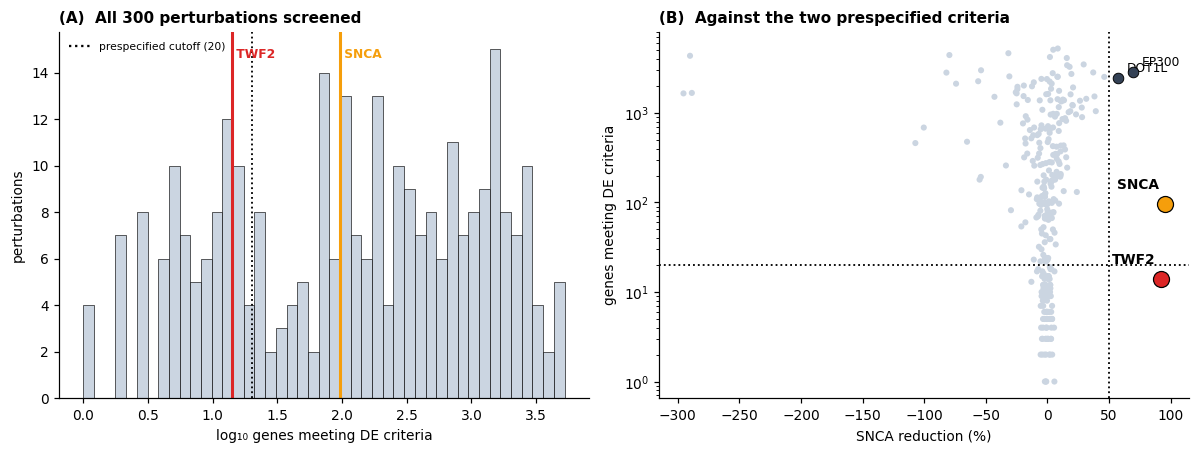

  Fig1_screen_overview


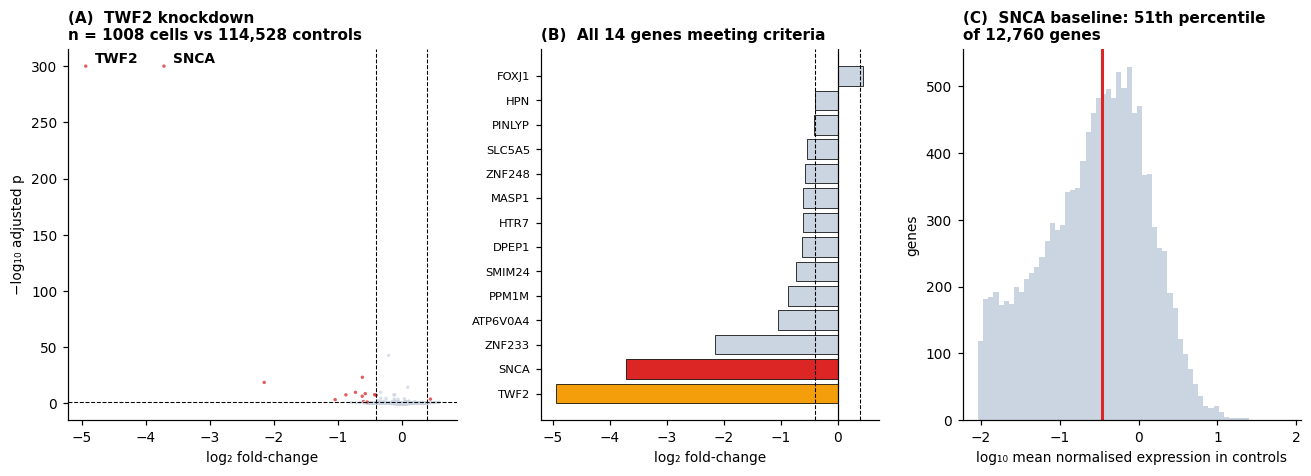

  Fig2_candidate_characterisation


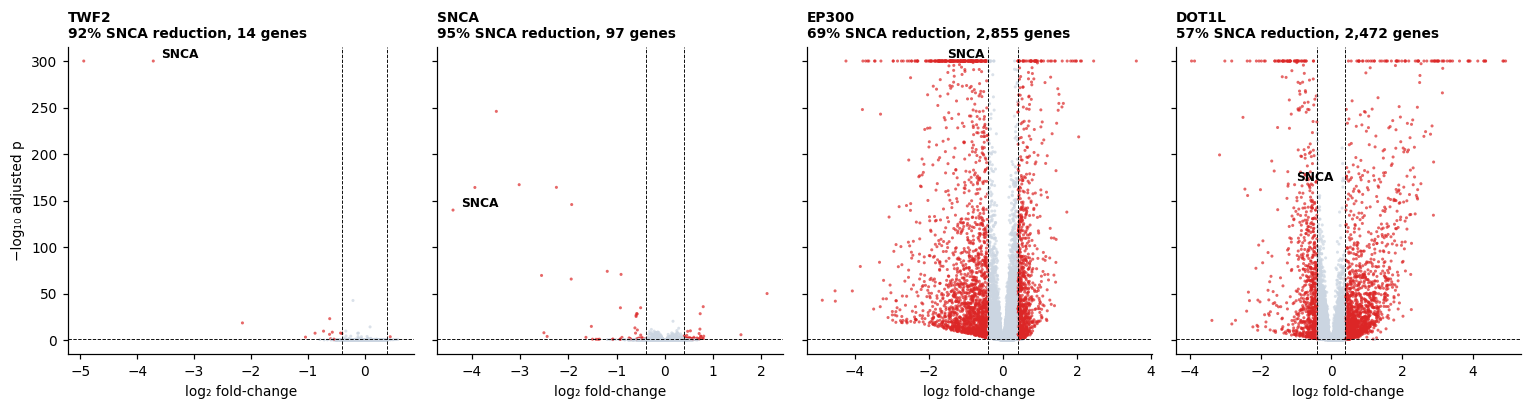

  Fig3_comparator_volcanoes


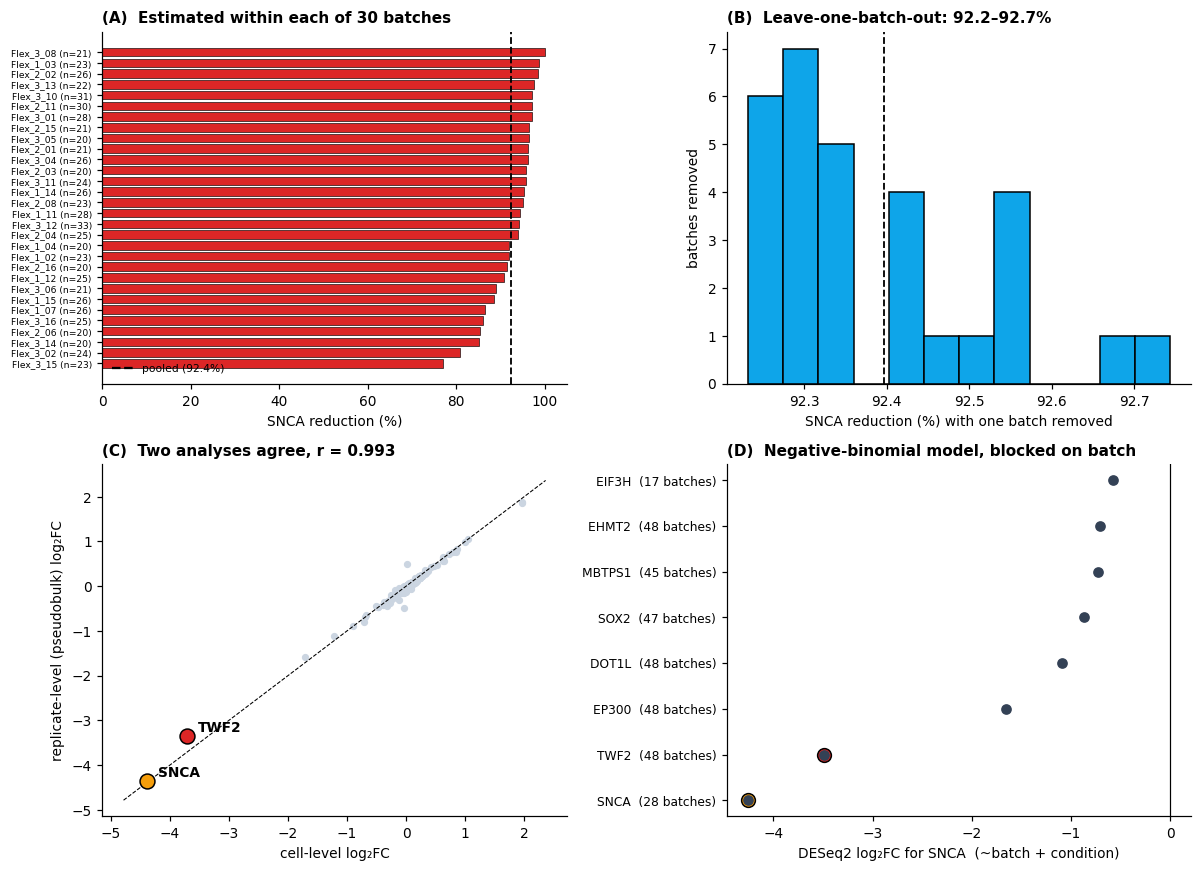

  Fig4_replicate_level_evidence


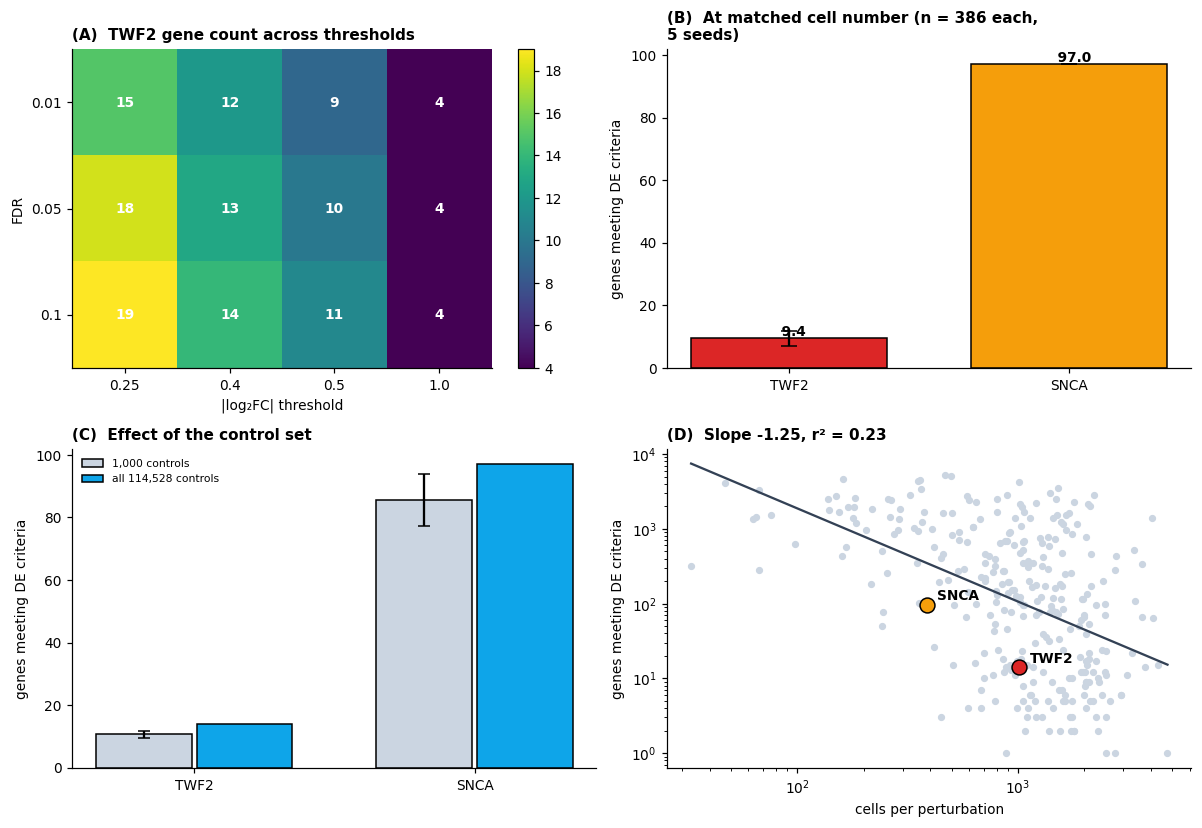

  Fig5_robustness


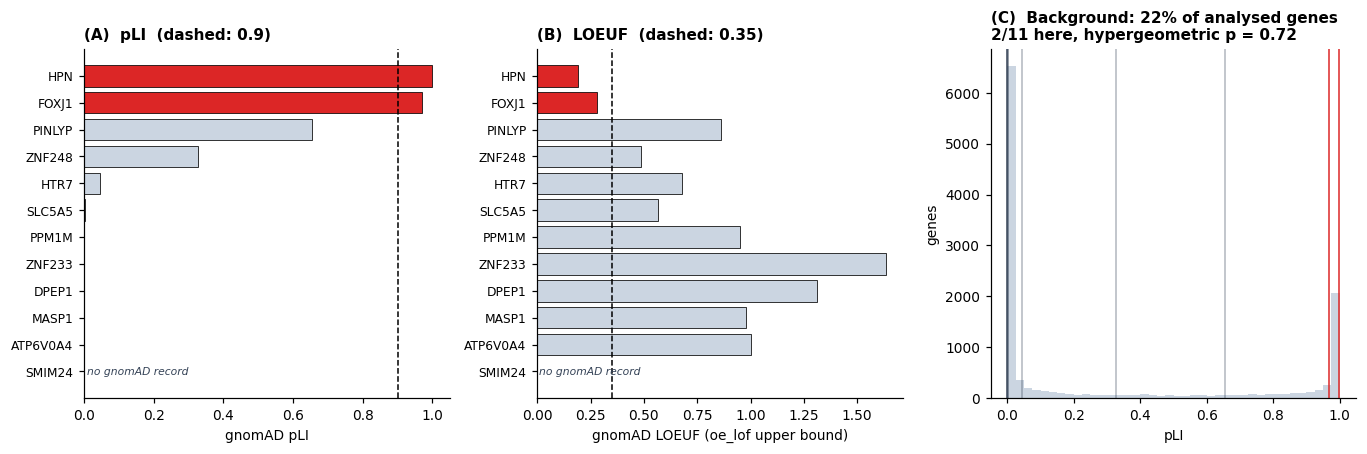

  Fig6_constraint


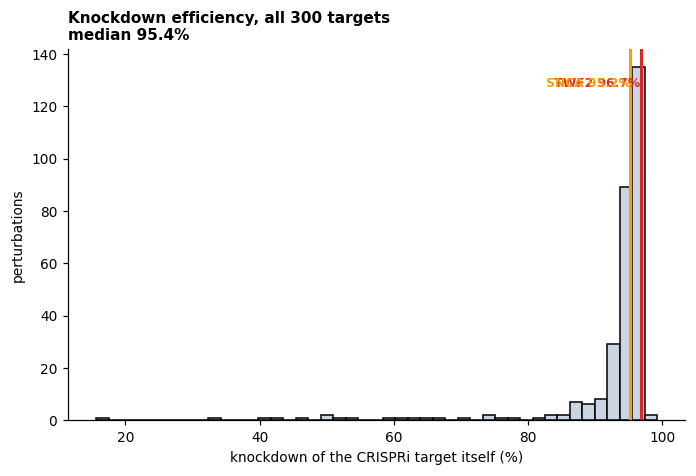

  FigS1_knockdown_efficiency


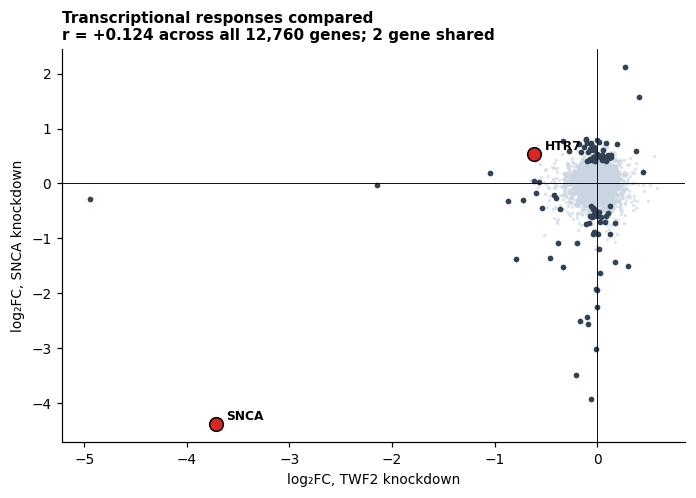

  FigS2_response_overlap


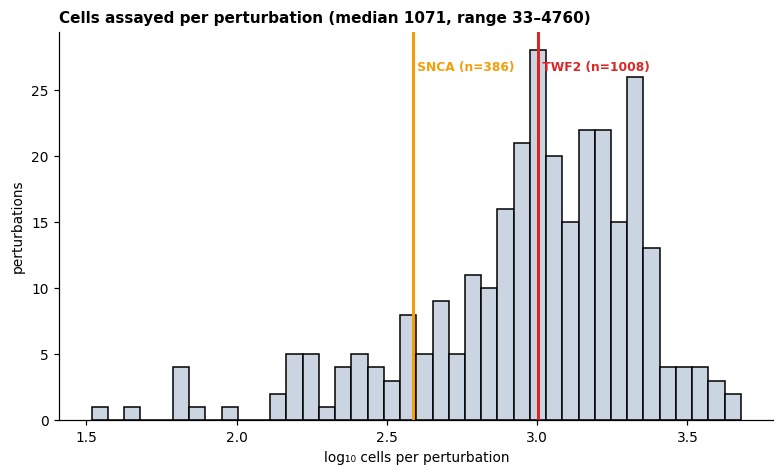

  FigS3_cells_per_perturbation

captions -> figures_final/CAPTIONS_FINAL.md
[drive] 50 files -> /content/drive/MyDrive/TWF2_SNCA_Revision/run_20260824_2235/figures_final  (20260825_0002)
done


In [40]:
# ============================================================================
#  FINAL FIGURES  —  one cell, six main + three supplementary
#  Every panel carries n, thresholds and the test used; no value-laden labels;
#  constraint is reported as constraint, including the inconvenient members.
# ============================================================================
import os, json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

RUN_DIR = "/content/drive/MyDrive/TWF2_SNCA_Revision/run_20260824_2235/final/results"
BASE = "results" if os.path.exists("results/04_cell_level_screen.csv") else RUN_DIR
OUT = "figures_final"
os.makedirs(OUT, exist_ok=True)
print(f"reading from {BASE}, writing to {OUT}/")

if "LFC" not in dir():
    z = np.load(f"{BASE}/04_cell_level_screen_matrices.npz", allow_pickle=True)
    PERTS = [str(p) for p in z["perturbations"]]
    GENES = z["genes"].astype(str)
    LFC, PADJ, SIG = z["lfc"], z["padj"], z["sig"]
    MEAN_P, MEAN_C, PCT_P = z["mean_pert"], z["mean_ctrl"], z["pct_pert"]
    N_GENES = len(GENES)
    gene_index = {g: i for i, g in enumerate(GENES)}

GOI, CAND = "SNCA", "TWF2"
FDR, LFCMIN, MAXDEG, MINRED = 0.10, 0.40, 20, 50.0
goi_i = gene_index[GOI]
ic, ig = PERTS.index(CAND), PERTS.index(GOI)

sc_tab = pd.read_csv(f"{BASE}/09_screen_with_criteria.csv")
screen = pd.read_csv(f"{BASE}/04_cell_level_screen.csv")
bdf = pd.read_csv(f"{BASE}/12_per_batch_replication.csv")
ldf = pd.read_csv(f"{BASE}/12_leave_one_batch_out.csv")
agg = pd.read_csv(f"{BASE}/06_subsample_stability.csv")
sens = pd.read_csv(f"{BASE}/07_threshold_sensitivity.csv")
mn = pd.read_csv(f"{BASE}/07_matched_n_comparison.csv")
deseq = pd.read_csv(f"{BASE}/05_deseq2_shortlist.csv")
both = pd.read_csv(f"{BASE}/05_combined_screen.csv")
con = pd.read_csv(f"{BASE}/11_gnomad_constraint_all.csv")
deg_c = pd.read_csv(f"{BASE}/11_DE_{CAND}.csv")

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 400, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.titlesize": 10, "axes.titleweight": "bold",
                     "figure.facecolor": "white"})
RED, AMB, GREY, BLUE, DARK = "#dc2626", "#f59e0b", "#cbd5e1", "#0ea5e9", "#334155"
N_P = len(PERTS)
CAP = {}


def tag(ax, s):
    ax.text(-0.13, 1.06, s, transform=ax.transAxes, fontsize=12, fontweight="bold",
            va="top")


def save(fig, name):
    fig.savefig(f"{OUT}/{name}.png", bbox_inches="tight")
    fig.savefig(f"{OUT}/{name}.pdf", bbox_inches="tight")
    plt.show()
    print(f"  {name}")


# ============================================================ FIGURE 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
ax = axes[0]
ax.hist(np.log10(sc_tab.n_deg.clip(lower=1)), bins=45, color=GREY,
        edgecolor="black", linewidth=.4)
for p, c in [(CAND, RED), (GOI, AMB)]:
    v = sc_tab.loc[sc_tab.perturbation == p, "n_deg"].iloc[0]
    ax.axvline(np.log10(max(v, 1)), color=c, lw=2)
    ax.text(np.log10(max(v, 1)), ax.get_ylim()[1] * .93, f" {p}", color=c,
            fontweight="bold", fontsize=8)
ax.axvline(np.log10(MAXDEG), color="black", lw=1.2, ls=":")
ax.set_xlabel("log₁₀ genes meeting DE criteria")
ax.set_ylabel("perturbations")
ax.set_title(f"(A)  All {N_P} perturbations screened", loc="left")
ax.legend(handles=[Line2D([], [], color="black", ls=":",
                          label=f"prespecified cutoff ({MAXDEG})")],
          fontsize=7, frameon=False)
tag(ax, "")

ax = axes[1]
oth = sc_tab[~sc_tab.perturbation.isin([CAND, GOI])]
ax.scatter(oth.goi_reduction_pct, oth.n_deg.clip(lower=1), s=16, c=GREY,
           edgecolor="none", zorder=2)
for p, c in [(CAND, RED), (GOI, AMB)]:
    r = sc_tab[sc_tab.perturbation == p].iloc[0]
    ax.scatter([r.goi_reduction_pct], [max(r.n_deg, 1)], s=110, c=c,
               edgecolor="black", lw=.8, zorder=6)
    ax.annotate(p, (r.goi_reduction_pct, max(r.n_deg, 1)), fontsize=9,
                fontweight="bold", textcoords="offset points", xytext=(-4, 10),
                ha="right")
for p in sc_tab[(sc_tab.goi_reduction_pct >= MINRED) &
                (~sc_tab.perturbation.isin([CAND, GOI]))].perturbation:
    r = sc_tab[sc_tab.perturbation == p].iloc[0]
    ax.scatter([r.goi_reduction_pct], [r.n_deg], s=48, c=DARK, edgecolor="black",
               lw=.6, zorder=5)
    ax.annotate(p, (r.goi_reduction_pct, r.n_deg), fontsize=8,
                textcoords="offset points", xytext=(6, 4))
ax.axhline(MAXDEG, color="black", ls=":", lw=1.2)
ax.axvline(MINRED, color="black", ls=":", lw=1.2)
ax.set_yscale("log")
ax.set_xlabel(f"{GOI} reduction (%)")
ax.set_ylabel("genes meeting DE criteria")
ax.set_title("(B)  Against the two prespecified criteria", loc="left")
fig.tight_layout()
save(fig, "Fig1_screen_overview")
CAP["Figure 1"] = (
    f"Screen of all {N_P} CRISPRi perturbations in the Virtual Cell Challenge 2025 "
    f"dataset (491,046 cells; 114,528 non-targeting controls). Differential "
    f"expression: tie-corrected Wilcoxon rank-sum test against batch-matched control "
    f"cells, Benjamini-Hochberg adjusted p < {FDR} and |log2 fold-change| > {LFCMIN}, "
    f"across 12,760 genes. (A) Distribution of the number of genes meeting those "
    f"criteria; dotted line marks the prespecified operational cutoff of {MAXDEG}. "
    f"(B) {GOI} reduction against that count for every perturbation; dotted lines are "
    f"the two criteria fixed before analysis. Dark points are the other perturbations "
    f"reducing {GOI} by at least {MINRED:.0f}%. No region of the plot is designated "
    f"optimal; both axes show measured quantities.")

# ============================================================ FIGURE 2
fig = plt.figure(figsize=(12, 4.4))
gs = fig.add_gridspec(1, 3, width_ratios=[1.15, 1, 1])
ax = fig.add_subplot(gs[0])
y = -np.log10(np.maximum(PADJ[ic].astype(np.float64), 1e-300))
ax.scatter(LFC[ic], y, s=5, c=np.where(SIG[ic], RED, GREY), linewidths=0, alpha=.75)
ax.axhline(-np.log10(FDR), color="k", ls="--", lw=.7)
for v in (-LFCMIN, LFCMIN):
    ax.axvline(v, color="k", ls="--", lw=.7)
for g in [CAND, GOI]:
    j = gene_index[g]
    ax.annotate(g, (LFC[ic, j], y[j]), fontsize=9, fontweight="bold",
                textcoords="offset points", xytext=(6, 2))
ax.set_xlabel("log₂ fold-change")
ax.set_ylabel("−log₁₀ adjusted p")
ax.set_title(f"(A)  {CAND} knockdown\nn = {int(sc_tab.loc[sc_tab.perturbation==CAND,'n_cells'].iloc[0])} cells "
             f"vs 114,528 controls", loc="left")

ax = fig.add_subplot(gs[1])
t = deg_c.sort_values("log2FC")
cols = [RED if g == GOI else AMB if g == CAND else GREY for g in t.gene]
ax.barh(range(len(t)), t.log2FC, color=cols, edgecolor="black", lw=.5)
ax.set_yticks(range(len(t)))
ax.set_yticklabels(t.gene, fontsize=7.5)
ax.axvline(0, color="k", lw=.8)
for v in (-LFCMIN, LFCMIN):
    ax.axvline(v, color="k", ls="--", lw=.7)
ax.set_xlabel("log₂ fold-change")
ax.set_title(f"(B)  All {len(t)} genes meeting criteria", loc="left")

ax = fig.add_subplot(gs[2])
base = MEAN_C[ic]
ax.hist(np.log10(np.expm1(base) + 1e-3), bins=60, color=GREY, edgecolor="none")
pct = 100 * (base < base[goi_i]).mean()
ax.axvline(np.log10(np.expm1(base[goi_i]) + 1e-3), color=RED, lw=2)
ax.set_xlabel("log₁₀ mean normalised expression in controls")
ax.set_ylabel("genes")
ax.set_title(f"(C)  {GOI} baseline: {pct:.0f}th percentile\nof 12,760 genes",
             loc="left")
fig.tight_layout()
save(fig, "Fig2_candidate_characterisation")
CAP["Figure 2"] = (
    f"(A) Volcano plot for {CAND} knockdown; red points meet the criteria in "
    f"Figure 1. (B) Every gene meeting the criteria, ordered by effect size; the "
    f"CRISPRi target and {GOI} are highlighted. (C) {GOI} sits at the {pct:.0f}th "
    f"percentile of baseline expression in control cells, so the observed reduction "
    f"is not a floor effect on a weakly expressed transcript.")

# ============================================================ FIGURE 3
comp = [p for p in [CAND, GOI, "EP300", "DOT1L"] if p in PERTS]
fig, axes = plt.subplots(1, len(comp), figsize=(3.5 * len(comp), 3.8), sharey=True)
for ax, p in zip(np.atleast_1d(axes), comp):
    i = PERTS.index(p)
    y = -np.log10(np.maximum(PADJ[i].astype(np.float64), 1e-300))
    ax.scatter(LFC[i], y, s=4, c=np.where(SIG[i], RED, GREY), linewidths=0, alpha=.7)
    ax.axhline(-np.log10(FDR), color="k", ls="--", lw=.6)
    for v in (-LFCMIN, LFCMIN):
        ax.axvline(v, color="k", ls="--", lw=.6)
    j = gene_index[GOI]
    ax.annotate(GOI, (LFC[i, j], y[j]), fontsize=8, fontweight="bold",
                textcoords="offset points", xytext=(5, 2))
    r = sc_tab[sc_tab.perturbation == p].iloc[0]
    ax.set_title(f"{p}\n{r.goi_reduction_pct:.0f}% {GOI} reduction, "
                 f"{int(r.n_deg):,} genes", loc="left", fontsize=9)
    ax.set_xlabel("log₂ fold-change")
np.atleast_1d(axes)[0].set_ylabel("−log₁₀ adjusted p")
fig.tight_layout()
save(fig, "Fig3_comparator_volcanoes")
CAP["Figure 3"] = (
    f"The four perturbations reducing {GOI} by at least {MINRED:.0f}%. EP300 and "
    f"DOT1L are named rather than described generically; both are chromatin "
    f"regulators and both alter thousands of genes, which is why they meet the "
    f"{GOI} criterion but not the gene-count criterion. Same test and thresholds "
    f"as Figure 1.")

# ============================================================ FIGURE 4
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
ax = axes[0, 0]
b = bdf.sort_values("goi_reduction_pct")
ax.barh(range(len(b)), b.goi_reduction_pct,
        color=np.where(b.padj < .05, RED, GREY), edgecolor="black", lw=.4)
pooled = sc_tab.loc[sc_tab.perturbation == CAND, "goi_reduction_pct"].iloc[0]
ax.axvline(pooled, color="black", ls="--", lw=1.2)
ax.set_yticks(range(len(b)))
ax.set_yticklabels([f"{x} (n={n})" for x, n in zip(b.batch, b.n_pert_cells)],
                   fontsize=6)
ax.set_xlabel(f"{GOI} reduction (%)")
ax.set_title(f"(A)  Estimated within each of {len(b)} batches", loc="left")
ax.legend(handles=[Line2D([], [], color="black", ls="--",
                          label=f"pooled ({pooled:.1f}%)")], fontsize=7,
          frameon=False, loc="lower left")

ax = axes[0, 1]
ax.hist(ldf.goi_reduction_pct, bins=12, color=BLUE, edgecolor="black", lw=.5)
ax.axvline(pooled, color="black", ls="--", lw=1.2)
ax.set_xlabel(f"{GOI} reduction (%) with one batch removed")
ax.set_ylabel("batches removed")
ax.set_title(f"(B)  Leave-one-batch-out: "
             f"{ldf.goi_reduction_pct.min():.1f}–{ldf.goi_reduction_pct.max():.1f}%",
             loc="left")

ax = axes[1, 0]
ok = both.pb_goi_lfc.notna()
ax.scatter(both.loc[ok, "goi_lfc"], both.loc[ok, "pb_goi_lfc"], s=14, c=GREY)
for p, c in [(CAND, RED), (GOI, AMB)]:
    r = both[both.perturbation == p].iloc[0]
    ax.scatter([r.goi_lfc], [r.pb_goi_lfc], s=95, c=c, edgecolor="black", zorder=5)
    ax.annotate(p, (r.goi_lfc, r.pb_goi_lfc), fontsize=9, fontweight="bold",
                textcoords="offset points", xytext=(7, 3))
lim = [both.loc[ok, "goi_lfc"].min() - .4, both.loc[ok, "goi_lfc"].max() + .4]
ax.plot(lim, lim, ls="--", c="k", lw=.7)
rr = stats.pearsonr(both.loc[ok, "goi_lfc"], both.loc[ok, "pb_goi_lfc"])[0]
ax.set_xlabel("cell-level log₂FC")
ax.set_ylabel("replicate-level (pseudobulk) log₂FC")
ax.set_title(f"(C)  Two analyses agree, r = {rr:.3f}", loc="left")

ax = axes[1, 1]
d = deseq.sort_values("deseq_goi_lfc")
ax.errorbar(d.deseq_goi_lfc, range(len(d)), fmt="o", color=DARK, ms=6)
for i2, (p, v) in enumerate(zip(d.perturbation, d.deseq_goi_lfc)):
    if p in (CAND, GOI):
        ax.plot([v], [i2], "o", color=RED if p == CAND else AMB, ms=9,
                markeredgecolor="black")
ax.axvline(0, color="k", lw=.8)
ax.set_yticks(range(len(d)))
ax.set_yticklabels([f"{p}  ({int(n)} batches)" for p, n in
                    zip(d.perturbation, d.n_batches)], fontsize=8)
ax.set_xlabel(f"DESeq2 log₂FC for {GOI}  (~batch + condition)")
ax.set_title("(D)  Negative-binomial model, blocked on batch", loc="left")
fig.tight_layout()
save(fig, "Fig4_replicate_level_evidence")
CAP["Figure 4"] = (
    f"Replicate-level evidence. (A) The {CAND}–{GOI} association re-estimated "
    f"separately within each processing batch containing at least 20 perturbed and "
    f"30 control cells (n = {len(b)} batches); red bars are batches where the effect "
    f"reached adjusted p < 0.05 on its own. (B) Removing any single batch moves the "
    f"pooled estimate by less than one percentage point. (C) {GOI} effect sizes from "
    f"the cell-level test against pseudobulk profiles aggregated by batch, for all "
    f"perturbations with at least two replicates. (D) DESeq2 on raw pseudobulk counts "
    f"with batch as a blocking factor. Batches are processing units, not independent "
    f"biological replicates.")

# ============================================================ FIGURE 5
fig, axes = plt.subplots(2, 2, figsize=(11, 7.6))
ax = axes[0, 0]
piv = sens.pivot(index="fdr", columns="lfc_min", values=f"{CAND}_n_deg")
im = ax.imshow(piv.values, cmap="viridis", aspect="auto")
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index)
for a in range(piv.shape[0]):
    for b2 in range(piv.shape[1]):
        ax.text(b2, a, f"{piv.values[a, b2]:.0f}", ha="center", va="center",
                color="w", fontsize=9, fontweight="bold")
ax.set_xlabel("|log₂FC| threshold"); ax.set_ylabel("FDR")
ax.set_title(f"(A)  {CAND} gene count across thresholds", loc="left")
fig.colorbar(im, ax=ax)

ax = axes[0, 1]
w = 0.35
for k2, (p, c) in enumerate([(CAND, RED), (GOI, AMB)]):
    s_ = mn[mn.perturbation == p]
    ax.bar(k2, s_.n_deg_matched.mean(), w * 2, yerr=s_.n_deg_matched.std(),
           color=c, edgecolor="black", capsize=5)
    ax.text(k2, s_.n_deg_matched.mean(), f"  {s_.n_deg_matched.mean():.1f}",
            ha="center", va="bottom", fontweight="bold")
ax.set_xticks([0, 1]); ax.set_xticklabels([CAND, GOI])
ax.set_ylabel("genes meeting DE criteria")
ax.set_title("(B)  At matched cell number (n = 386 each,\n5 seeds)", loc="left")

ax = axes[1, 0]
for k2, p in enumerate([CAND, GOI]):
    a = agg[agg.perturbation == p].iloc[0]
    ax.bar(k2 - .18, a.n_deg_mean, .34, yerr=a.n_deg_sd, color=GREY,
           edgecolor="black", capsize=4, label="1,000 controls" if k2 == 0 else "")
    ax.bar(k2 + .18, a.n_deg_allctrl, .34, color=BLUE, edgecolor="black",
           label="all 114,528 controls" if k2 == 0 else "")
ax.set_xticks([0, 1]); ax.set_xticklabels([CAND, GOI])
ax.set_ylabel("genes meeting DE criteria")
ax.set_title("(C)  Effect of the control set", loc="left")
ax.legend(fontsize=7, frameon=False)

ax = axes[1, 1]
d2 = sc_tab[sc_tab.n_deg > 0]
ax.scatter(d2.n_cells, d2.n_deg, s=14, c=GREY)
for p, c in [(CAND, RED), (GOI, AMB)]:
    r = sc_tab[sc_tab.perturbation == p].iloc[0]
    ax.scatter([r.n_cells], [r.n_deg], s=95, c=c, edgecolor="black", zorder=5)
    ax.annotate(p, (r.n_cells, r.n_deg), fontsize=9, fontweight="bold",
                textcoords="offset points", xytext=(7, 3))
lr = stats.linregress(np.log10(d2.n_cells), np.log10(d2.n_deg))
xs = np.linspace(np.log10(d2.n_cells.min()), np.log10(d2.n_cells.max()), 50)
ax.plot(10 ** xs, 10 ** (lr.intercept + lr.slope * xs), color=DARK, lw=1.5)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("cells per perturbation")
ax.set_ylabel("genes meeting DE criteria")
ax.set_title(f"(D)  Slope {lr.slope:.2f}, r² = {lr.rvalue**2:.2f}", loc="left")
fig.tight_layout()
save(fig, "Fig5_robustness")
CAP["Figure 5"] = (
    f"Robustness of the gene-count metric. (A) The count for {CAND} across a grid of "
    f"FDR and effect-size thresholds; it is a function of the cutoffs as well as of "
    f"the perturbation. (B) Recomputed with both perturbations downsampled to 386 "
    f"cells (5 seeds, mean ± SD): the difference is not explained by cell number. "
    f"(C) Using 1,000 randomly drawn control cells (5 seeds, mean ± SD) versus the "
    f"full control pool; the smaller control set systematically undercounts. "
    f"(D) The count against cells assayed, log-log, least-squares fit shown. The "
    f"negative slope means perturbations recovered in fewer cells produced more "
    f"differentially expressed genes, consistent with cell number reflecting "
    f"perturbation toxicity rather than statistical power. The count therefore "
    f"depends on factors beyond molecular specificity and is not a specificity "
    f"measure.")

# ============================================================ FIGURE 6
t = deg_c[deg_c.role == "non-target differentially expressed gene"].copy()
t = t.sort_values("pLI", na_position="first")
bg = con[con.gene.isin(GENES)].dropna(subset=["pLI"])
fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.2))
for ax, col, thr, lab, hi in [
        (axes[0], "pLI", 0.9, "gnomAD pLI", "above"),
        (axes[1], "LOEUF", 0.35, "gnomAD LOEUF (oe_lof upper bound)", "below")]:
    v = t[col]
    cols = [RED if (hi == "above" and x > thr) or (hi == "below" and x < thr)
            else GREY for x in v.fillna(-1 if hi == "above" else 99)]
    ax.barh(range(len(t)), v.fillna(0), color=cols, edgecolor="black", lw=.5)
    for i2, x in enumerate(v):
        if pd.isna(x):
            ax.text(0.01, i2, "no gnomAD record", va="center", fontsize=7,
                    style="italic", color=DARK)
    ax.axvline(thr, color="black", ls="--", lw=1)
    ax.set_yticks(range(len(t)))
    ax.set_yticklabels(t.gene, fontsize=8)
    ax.set_xlabel(lab)
axes[0].set_title("(A)  pLI  (dashed: 0.9)", loc="left")
axes[1].set_title("(B)  LOEUF  (dashed: 0.35)", loc="left")
ax = axes[2]
ax.hist(bg.pLI, bins=40, color=GREY, edgecolor="none")
for _, r in t.iterrows():
    if pd.notna(r.pLI):
        ax.axvline(r.pLI, color=RED if r.pLI > .9 else DARK, lw=1.1,
                   alpha=.9 if r.pLI > .9 else .35)
ax.set_xlabel("pLI"); ax.set_ylabel("genes")
k = int((t.pLI > .9).sum()); n_s = int(t.pLI.notna().sum())
hp = stats.hypergeom.sf(k - 1, len(bg), int((bg.pLI > .9).sum()), n_s)
ax.set_title(f"(C)  Background: {(bg.pLI>.9).mean()*100:.0f}% of analysed genes\n"
             f"{k}/{n_s} here, hypergeometric p = {hp:.2f}", loc="left")
fig.tight_layout()
save(fig, "Fig6_constraint")
CAP["Figure 6"] = (
    f"Loss-of-function constraint (gnomAD v2.1.1) for the {len(t)} non-target genes "
    f"meeting DE criteria under {CAND} knockdown. (A) pLI, dashed line at the "
    f"conventional 0.9 threshold. (B) LOEUF, dashed line at gnomAD's suggested 0.35. "
    f"Red marks genes that are constrained by that metric: {', '.join(t[t.pLI>.9].gene)} "
    f"reach pLI > 0.9, so it is not the case that none of the affected genes shows "
    f"evidence of constraint. (C) Against the background distribution across the "
    f"12,760 analysed genes, {k} of {n_s} scored genes exceed pLI 0.9 "
    f"(hypergeometric p = {hp:.2f}), so this set is not enriched for constraint "
    f"relative to chance. Constraint describes population-level depletion of "
    f"loss-of-function variants; it is not a measure of essentiality and does not "
    f"establish tolerance to partial pharmacological inhibition.")

# ============================================================ SUPPLEMENTARY
figS, ax = plt.subplots(figsize=(6.4, 4.4))
ax.hist(screen.self_knockdown_pct.dropna(), bins=45, color=GREY, edgecolor="black",
        lw=.4)
for p, c in [(CAND, RED), (GOI, AMB)]:
    v = screen.loc[screen.perturbation == p, "self_knockdown_pct"].iloc[0]
    ax.axvline(v, color=c, lw=2)
    ax.text(v, ax.get_ylim()[1] * .9, f" {p} {v:.1f}%", color=c, fontsize=8,
            fontweight="bold", ha="right")
ax.set_xlabel("knockdown of the CRISPRi target itself (%)")
ax.set_ylabel("perturbations")
ax.set_title(f"Knockdown efficiency, all {N_P} targets\n"
             f"median {screen.self_knockdown_pct.median():.1f}%", loc="left")
figS.tight_layout()
save(figS, "FigS1_knockdown_efficiency")
CAP["Figure S1"] = (
    f"Knockdown efficiency for every target, measured as the reduction in the "
    f"CRISPRi target's own transcript (median "
    f"{screen.self_knockdown_pct.median():.1f}%, IQR "
    f"{screen.self_knockdown_pct.quantile(.25):.1f}–"
    f"{screen.self_knockdown_pct.quantile(.75):.1f}%).")

figS, ax = plt.subplots(figsize=(6.4, 4.6))
sh = set(GENES[SIG[ic]]) & set(GENES[SIG[ig]])
ax.scatter(LFC[ic], LFC[ig], s=5, c=GREY, linewidths=0, alpha=.6)
m = SIG[ic] | SIG[ig]
ax.scatter(LFC[ic][m], LFC[ig][m], s=14, c=DARK, linewidths=0)
for g in sh:
    j = gene_index[g]
    ax.scatter([LFC[ic, j]], [LFC[ig, j]], s=80, c=RED, edgecolor="black", zorder=5)
    ax.annotate(g, (LFC[ic, j], LFC[ig, j]), fontsize=8, fontweight="bold",
                textcoords="offset points", xytext=(7, 3))
r_all = stats.pearsonr(LFC[ic], LFC[ig])
ax.axhline(0, color="k", lw=.6); ax.axvline(0, color="k", lw=.6)
ax.set_xlabel(f"log₂FC, {CAND} knockdown")
ax.set_ylabel(f"log₂FC, {GOI} knockdown")
ax.set_title(f"Transcriptional responses compared\nr = {r_all[0]:+.3f} across all "
             f"12,760 genes; {len(sh)} gene shared", loc="left")
figS.tight_layout()
save(figS, "FigS2_response_overlap")
CAP["Figure S2"] = (
    f"Gene-level effect sizes under {CAND} knockdown against those under {GOI} "
    f"knockdown. Dark points meet the DE criteria in either comparison; red points "
    f"meet them in both. The two perturbations produce largely non-overlapping "
    f"transcriptional responses in this dataset (Pearson r = {r_all[0]:+.3f}). This "
    f"is a descriptive statement about the responses and does not support a claim "
    f"about mechanism or pathway.")

figS, ax = plt.subplots(figsize=(7.2, 4.4))
ax.hist(np.log10(sc_tab.n_cells), bins=40, color=GREY, edgecolor="black", lw=.4)
for p, c in [(CAND, RED), (GOI, AMB)]:
    v = sc_tab.loc[sc_tab.perturbation == p, "n_cells"].iloc[0]
    ax.axvline(np.log10(v), color=c, lw=2)
    ax.text(np.log10(v), ax.get_ylim()[1] * .9, f" {p} (n={int(v)})", color=c,
            fontsize=8, fontweight="bold")
ax.set_xlabel("log₁₀ cells per perturbation")
ax.set_ylabel("perturbations")
ax.set_title(f"Cells assayed per perturbation (median "
             f"{int(sc_tab.n_cells.median())}, range {int(sc_tab.n_cells.min())}–"
             f"{int(sc_tab.n_cells.max())})", loc="left")
figS.tight_layout()
save(figS, "FigS3_cells_per_perturbation")
CAP["Figure S3"] = (
    f"Cells recovered per perturbation across the {N_P} targets. Perturbations of "
    f"essential genes are recovered in fewer cells, which is the basis for the "
    f"interpretation of Figure 5D.")

with open(f"{OUT}/CAPTIONS_FINAL.md", "w") as f:
    f.write("# Figure captions\n\n")
    for k2, v in CAP.items():
        f.write(f"**{k2}.** {v}\n\n")
print(f"\ncaptions -> {OUT}/CAPTIONS_FINAL.md")
if "save_to_drive" in dir():
    import shutil
    os.makedirs("figures", exist_ok=True)
    shutil.copytree(OUT, f"figures/{OUT}", dirs_exist_ok=True)
    save_to_drive("figures_final")
print("done")